In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# ============================================================
# CELLULE 2 — Téléchargement automatique PDFs CMF Tunisie
# 13 entreprises industrielles · 2014-2024 · annuels + semestriels
# ============================================================

import os, urllib.request, time

PDFS = {
    'AIR_LIQUIDE': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/AIR_LIQUIDE_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/AIR_LIQUIDE_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/AIR_LIQUIDE_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/AIR_LIQUIDE_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_tunisie_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alt_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_tunisie_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_tunisie_efd_31_12_2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/air_liquide_tunisie_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efd_2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efi_du_30-06-2020.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alt_efi_2022.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/air_liquide_tunisie_efi300624.pdf'),
    ],
    'ALKIMIA': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ALKIMIA_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ALKIMIA_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ALKIMIA_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ALKIMIA_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efd_2017.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efd_2019_.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/alkimia_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efd_2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efd311221.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efi311222.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/alkimia_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/efi_2024_alkimia.pdf'),
    ],
    'ASAAD': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ASSAD_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ASSAD_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ASSAD_EFD311215.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efd311218.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efd311219.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/assad_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/assad_efi300624.pdf'),
    ],
    'ICF': [
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ICF_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ICF_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ICF_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efd_2018.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efd_2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/icf_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efi_2021.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_ef_31.12.2023.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efi_2023.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_ef_31.12.2024.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/icf_efi300624.pdf'),
    ],
    'MPBS': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/MPBS_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/MPBS_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/MPBS_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/MPBS_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efd_2018_.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efd_2019_.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/mpbs_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpps_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/mpbs_efi300624.pdf'),
    ],
    'ONE_TECH': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ONE_TECH_HOLDING_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ONE_TECH_HOLDING_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/ONE_TECH_HOLDING_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/OTH_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efi300618.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/oth_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efi_30-06-2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_ef_31-12-2023.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efi_30-06-2023.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/oth_efi300624.pdf'),
    ],
    'SIAME': [
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SIAME_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SIAME_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SIAME_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd311219.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/siame_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efi_du_30-06-2020.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efi_2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd_2022.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/siame_efi300624.pdf'),
    ],
    'SOMOCER': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOMOCER_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOMOCER_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efd311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOMOCER_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efd_2017_0.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efd311219.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/somocer_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_-_efi_2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efd_2022.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efi300622.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_ef_indivi_31-12-24.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/somocer_efi300624.pdf'),
    ],
    'SOTIPAPIER': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTIPAPIER_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTIPAPIER_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTIPAPIER_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTIPAPIER_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_ef_indiv2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotipapier_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_ef31-12-2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efi_30-06-2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efi_0-06-22.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotipapier_efi300624.pdf'),
    ],
    'SOTUVER': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTUVER_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTUVER_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTUVER_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SOTUVER_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efd_2018.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efd_31_12_2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sotuver_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efd_2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efi_2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efi_2023.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sotuver_efi300624.pdf'),
    ],
    'STIP': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/STIP_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/STIP_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efd311215.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efd311216.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/stip_efi_2018_.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311219.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/stip_efi300624.pdf'),
    ],
    'UNIMED': [
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_ef2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/unimed_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_ef_31.12.2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efi300622.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_ef_31.12.2024.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/unimed_efi300624.pdf'),
    ],
}

# ============================================================
# TÉLÉCHARGEMENT
# ============================================================
BASE_DIR = '/kaggle/working/pdfs'
os.makedirs(BASE_DIR, exist_ok=True)
results = {'success': [], 'failed': []}

total = sum(len(v) for v in PDFS.values())
print(f"📦 Total PDFs à télécharger : {total}")
print("=" * 55)

for company, pdf_list in PDFS.items():
    company_dir = f'{BASE_DIR}/{company}'
    os.makedirs(company_dir, exist_ok=True)
    print(f"\n📁 {company} — {len(pdf_list)} PDFs")

    for periode, url in pdf_list:
        fname = f"{company}_{periode}.pdf"
        path = f'{company_dir}/{fname}'
        try:
            urllib.request.urlretrieve(url, path)
            size = os.path.getsize(path) / 1024
            if size < 5:  # PDF trop petit = erreur 404
                os.remove(path)
                print(f"  ⚠️  {fname} — Fichier vide (URL incorrecte)")
                results['failed'].append(fname)
            else:
                print(f"  ✅ {fname} ({size:.0f} KB)")
                results['success'].append(fname)
        except Exception as e:
            print(f"  ❌ {fname} — {e}")
            results['failed'].append(fname)
        time.sleep(0.3)

print(f"\n{'='*55}")
print(f"✅ Succès  : {len(results['success'])} PDFs")
print(f"❌ Échecs  : {len(results['failed'])} PDFs")
print(f"\nPDFs échoués :")
for f in results['failed']:
    print(f"  → {f}")

📦 Total PDFs à télécharger : 249

📁 AIR_LIQUIDE — 22 PDFs
  ✅ AIR_LIQUIDE_annuel_2014.pdf (126 KB)
  ✅ AIR_LIQUIDE_semestriel_2014.pdf (102 KB)
  ✅ AIR_LIQUIDE_annuel_2015.pdf (124 KB)
  ✅ AIR_LIQUIDE_semestriel_2015.pdf (90 KB)
  ✅ AIR_LIQUIDE_annuel_2016.pdf (101 KB)
  ✅ AIR_LIQUIDE_semestriel_2016.pdf (101 KB)
  ✅ AIR_LIQUIDE_annuel_2017.pdf (128 KB)
  ✅ AIR_LIQUIDE_semestriel_2017.pdf (82 KB)
  ✅ AIR_LIQUIDE_annuel_2018.pdf (126 KB)
  ✅ AIR_LIQUIDE_semestriel_2018.pdf (149 KB)
  ✅ AIR_LIQUIDE_annuel_2019.pdf (770 KB)
  ✅ AIR_LIQUIDE_semestriel_2019.pdf (132 KB)
  ✅ AIR_LIQUIDE_annuel_2020.pdf (1376 KB)
  ✅ AIR_LIQUIDE_semestriel_2020.pdf (1094 KB)
  ✅ AIR_LIQUIDE_annuel_2021.pdf (149 KB)
  ✅ AIR_LIQUIDE_semestriel_2021.pdf (6626 KB)
  ✅ AIR_LIQUIDE_annuel_2022.pdf (162 KB)
  ✅ AIR_LIQUIDE_semestriel_2022.pdf (1618 KB)
  ✅ AIR_LIQUIDE_annuel_2023.pdf (177 KB)
  ✅ AIR_LIQUIDE_semestriel_2023.pdf (330 KB)
  ✅ AIR_LIQUIDE_annuel_2024.pdf (170 KB)
  ✅ AIR_LIQUIDE_semestriel_2024.pdf (16

In [3]:
# ============================================================
# CELLULE 3 — Ajout 3 nouvelles entreprises
# Carthage Cement · Landor · SAH Lilas
# ============================================================
import os, urllib.request, time

PDFS_NEW = {
    'CARTHAGE_CEMENT': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/CARTHAGE_CEMENT_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/CARTHAGE_CEMENT_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efd311215_0.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/CARTHAGE_CEMENT_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efi300616_0.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/carthage_cement_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efd311219.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/cc_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cemment_efd311220.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efi_30-06-2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efi_30-06-2022.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/carthage_cement_efi300624.pdf'),
    ],
    'LANDOR': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/LANDOR_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/LANDOR_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/LANDOR_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/LANDOR_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efc_2017_0.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_ef31_12_2019.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/landor_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_ef31-12-2020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efi_30-06-2020.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efd311221.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/ef_landor_efi_30.06.2021.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efd311222.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_ef_31-12-2023.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efi_30-06-2023.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/landor_efi300624.pdf'),
    ],
    'SAH_LILAS': [
        ('annuel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SAH_EFD311214.pdf'),
        ('semestriel_2014', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SAH_EFI300614.pdf'),
        ('annuel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SAH_EFD311215.pdf'),
        ('semestriel_2015', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/SAH_EFI300615.pdf'),
        ('annuel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efd311216.pdf'),
        ('semestriel_2016', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_lilas_efi300616.pdf'),
        ('annuel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efd311217.pdf'),
        ('semestriel_2017', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efi300617.pdf'),
        ('annuel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efd311218.pdf'),
        ('semestriel_2018', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efi300618.pdf'),
        ('annuel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efd_2019_-.pdf'),
        ('semestriel_2019', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/consultations/sah_efi300619.pdf'),
        ('annuel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_lilas_efd31122020.pdf'),
        ('semestriel_2020', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efi300620.pdf'),
        ('annuel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efd_2021.pdf'),
        ('semestriel_2021', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_lilas_efi300621.pdf'),
        ('annuel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efd_2022.pdf'),
        ('semestriel_2022', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efi_2022.pdf'),
        ('annuel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efd311223.pdf'),
        ('semestriel_2023', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efi300623.pdf'),
        ('annuel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efd311224.pdf'),
        ('semestriel_2024', 'https://www.cmf.tn/sites/default/files/pdfs/emetteurs/informations/rapports-societes/sah_efi300624.pdf'),
    ],
}

# ============================================================
# TÉLÉCHARGEMENT
# ============================================================
BASE_DIR = '/kaggle/working/pdfs'
results = {'success': [], 'failed': []}

total = sum(len(v) for v in PDFS_NEW.values())
print(f"📦 Nouvelles entreprises : 3")
print(f"📦 PDFs à télécharger   : {total}")
print("=" * 55)

for company, pdf_list in PDFS_NEW.items():
    company_dir = f'{BASE_DIR}/{company}'
    os.makedirs(company_dir, exist_ok=True)
    print(f"\n📁 {company} — {len(pdf_list)} PDFs")

    for periode, url in pdf_list:
        fname = f"{company}_{periode}.pdf"
        path  = f'{company_dir}/{fname}'
        try:
            urllib.request.urlretrieve(url, path)
            size = os.path.getsize(path) / 1024
            if size < 5:
                os.remove(path)
                print(f"  ⚠️  {fname} — Fichier vide")
                results['failed'].append(fname)
            else:
                print(f"  ✅ {fname} ({size:.0f} KB)")
                results['success'].append(fname)
        except Exception as e:
            print(f"  ❌ {fname} — {e}")
            results['failed'].append(fname)
        time.sleep(0.3)

print(f"\n{'='*55}")
print(f"✅ Succès  : {len(results['success'])} PDFs")
print(f"❌ Échecs  : {len(results['failed'])} PDFs")
print(f"\n📊 TOTAL DATASET : 249 + {len(results['success'])} = {249 + len(results['success'])} PDFs")
if results['failed']:
    print(f"\nPDFs échoués :")
    for f in results['failed']: print(f"  → {f}")

📦 Nouvelles entreprises : 3
📦 PDFs à télécharger   : 66

📁 CARTHAGE_CEMENT — 22 PDFs
  ✅ CARTHAGE_CEMENT_annuel_2014.pdf (177 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2014.pdf (160 KB)
  ✅ CARTHAGE_CEMENT_annuel_2015.pdf (1229 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2015.pdf (113 KB)
  ✅ CARTHAGE_CEMENT_annuel_2016.pdf (220 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2016.pdf (393 KB)
  ✅ CARTHAGE_CEMENT_annuel_2017.pdf (4038 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2017.pdf (155 KB)
  ✅ CARTHAGE_CEMENT_annuel_2018.pdf (249 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2018.pdf (1327 KB)
  ✅ CARTHAGE_CEMENT_annuel_2019.pdf (403 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2019.pdf (358 KB)
  ✅ CARTHAGE_CEMENT_annuel_2020.pdf (401 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2020.pdf (378 KB)
  ✅ CARTHAGE_CEMENT_annuel_2021.pdf (386 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2021.pdf (2570 KB)
  ✅ CARTHAGE_CEMENT_annuel_2022.pdf (242 KB)
  ✅ CARTHAGE_CEMENT_semestriel_2022.pdf (1956 KB)
  ✅ CARTHAGE_CEMENT_annuel_2023.pdf (358 KB)
  ✅ CARTHAGE_CEMENT

In [4]:
# ============================================================
# CELLULE 3 — Inventaire du dataset téléchargé
# ============================================================
import os
import pandas as pd

BASE_DIR = '/kaggle/working/pdfs'
inventory = []

for company in sorted(os.listdir(BASE_DIR)):
    company_dir = f'{BASE_DIR}/{company}'
    if not os.path.isdir(company_dir):
        continue
    
    for fname in sorted(os.listdir(company_dir)):
        if not fname.endswith('.pdf'):
            continue
        
        path = f'{company_dir}/{fname}'
        size_kb = os.path.getsize(path) / 1024
        
        # Extraire année et type depuis le nom
        parts = fname.replace('.pdf', '').split('_')
        periode = 'annuel' if 'annuel' in fname else 'semestriel'
        year = None
        for p in parts:
            if p.isdigit() and len(p) == 4:
                year = int(p)
                break
        
        inventory.append({
            'entreprise': company,
            'fichier': fname,
            'annee': year,
            'type': periode,
            'taille_kb': round(size_kb, 1)
        })

df = pd.DataFrame(inventory)

# Résumé global
print("=" * 55)
print(f"INVENTAIRE DATASET — {len(df)} PDFs")
print("=" * 55)

# Par entreprise
summary = df.groupby('entreprise').agg(
    total=('fichier', 'count'),
    annuels=('type', lambda x: (x=='annuel').sum()),
    semestriels=('type', lambda x: (x=='semestriel').sum()),
    annee_min=('annee', 'min'),
    annee_max=('annee', 'max'),
    taille_moy_kb=('taille_kb', 'mean')
).round(1)

print(summary.to_string())

print(f"\n{'='*55}")
print(f"Total annuels     : {(df['type']=='annuel').sum()}")
print(f"Total semestriels : {(df['type']=='semestriel').sum()}")
print(f"Taille totale     : {df['taille_kb'].sum()/1024:.1f} MB")

# Sauvegarder l'inventaire
df.to_csv('/kaggle/working/inventaire_pdfs.csv', index=False)
print(f"\n✅ Inventaire sauvegardé → inventaire_pdfs.csv")

INVENTAIRE DATASET — 315 PDFs
                 total  annuels  semestriels  annee_min  annee_max  taille_moy_kb
entreprise                                                                       
AIR_LIQUIDE         22       11           11       2014       2024          631.7
ALKIMIA             20       10           10       2014       2024          731.1
ASAAD               20       11            9       2014       2024          375.2
CARTHAGE_CEMENT     22       11           11       2014       2024          725.6
ICF                 20        9           11       2014       2024          489.9
LANDOR              22       11           11       2014       2024          768.9
MPBS                22       11           11       2014       2024          460.2
ONE_TECH            21       10           11       2014       2024          535.7
SAH_LILAS           22       11           11       2014       2024          565.3
SIAME               21       10           11       2014       2024  

In [5]:
# ============================================================
# CELLULE 4 — Conversion PDF → Images haute résolution
# ============================================================
!pip install pymupdf -q

# Vérification


import os, fitz, json
print(f"✅ PyMuPDF installé — version {fitz.version[0]}")
BASE_DIR   = '/kaggle/working/pdfs'
IMAGES_DIR = '/kaggle/working/images'
os.makedirs(IMAGES_DIR, exist_ok=True)

ZOOM = 2.0  # 144 DPI
MAT  = fitz.Matrix(ZOOM, ZOOM)

log         = []
stats       = {}
total_pages = 0
total_pdfs  = 0

for company in sorted(os.listdir(BASE_DIR)):
    company_dir = f'{BASE_DIR}/{company}'
    if not os.path.isdir(company_dir): continue

    out_dir = f'{IMAGES_DIR}/{company}'
    os.makedirs(out_dir, exist_ok=True)
    stats[company] = {'pdfs': 0, 'pages': 0}

    for fname in sorted(os.listdir(company_dir)):
        if not fname.endswith('.pdf'): continue

        pdf_path = f'{company_dir}/{fname}'
        stem     = fname.replace('.pdf', '')

        try:
            doc = fitz.open(pdf_path)
            n   = len(doc)

            for i, page in enumerate(doc):
                img_name = f'{stem}_p{i+1:03d}.png'
                img_path = f'{out_dir}/{img_name}'
                pix = page.get_pixmap(matrix=MAT)
                pix.save(img_path)
                log.append({
                    'entreprise' : company,
                    'pdf'        : fname,
                    'page'       : i + 1,
                    'total_pages': n,
                    'image'      : img_name,
                    'width'      : pix.width,
                    'height'     : pix.height,
                })

            doc.close()
            stats[company]['pdfs']  += 1
            stats[company]['pages'] += n
            total_pdfs  += 1
            total_pages += n

        except Exception as e:
            print(f'  ❌ {fname} — {e}')

    p = stats[company]['pages']
    d = stats[company]['pdfs']
    print(f'✅ {company:<20} {d:>3} PDFs → {p:>5} pages')

# Sauvegarder le journal
with open('/kaggle/working/images_log.json', 'w') as f:
    json.dump(log, f, indent=2)

print(f"\n{'='*55}")
print(f"Total PDFs convertis : {total_pdfs}")
print(f"Total pages/images   : {total_pages}")
print(f"Moy. pages/PDF       : {total_pages/total_pdfs:.1f}")
print(f"✅ Journal → images_log.json")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 63.4 MB/s eta 0:00:00:00:0100:01
✅ PyMuPDF installé — version 1.27.2.3
✅ AIR_LIQUIDE           22 PDFs →   566 pages
✅ ALKIMIA               20 PDFs →   456 pages
✅ ASAAD                 20 PDFs →   678 pages
✅ CARTHAGE_CEMENT       22 PDFs →   973 pages
✅ ICF                   20 PDFs →   478 pages
✅ LANDOR                22 PDFs →   769 pages
✅ MPBS                  22 PDFs →   578 pages
✅ ONE_TECH              21 PDFs →   518 pages
✅ SAH_LILAS             22 PDFs →   866 pages
✅ SIAME                 21 PDFs →   743 pages
✅ SOMOCER               21 PDFs →   947 pages
✅ SOTIPAPIER            22 PDFs →   753 pages
✅ SOTUVER               22 PDFs →   621 pages
✅ STIP                  20 PDFs →   795 pages
✅ UNIMED                18 PDFs →   632 pages

Total PDFs convertis : 315
Total pages/images   : 10373
Moy. pages/PDF       : 32.9
✅ Journal → images_log.json


ÉVALUATION IMAGES
Table Transformer + EasyOCR

🔍 INTÉGRITÉ :
  Manquantes  : 0   ✅
  Corrompues  : 0 ✅
  Valides     : 10373

📐 RÉSOLUTION (résolution principale : 1191×1684) :

  Table Transformer :
  → Besoin min 800×800px pour détecter les bordures de tableaux
  → Résolution actuelle 1191×1684 : ✅ Suffisant

  EasyOCR :
  → Besoin min 800px largeur pour lire chiffres financiers
  → Résolution actuelle 1191px : ✅ Suffisant

💾 TAILLE IMAGES :
  Taille totale    : 2073.5 MB
  Taille moy/image : 205 KB ✅
  → Table Transformer : image trop petite = tableaux non détectés
  → EasyOCR : image trop compressée = chiffres flous

📁 COUVERTURE PAR ENTREPRISE :
                 PDFs  Pages  Moy p/PDF
entreprise                             
AIR_LIQUIDE        22    566       25.7
ALKIMIA            20    456       22.8
ASAAD              20    678       33.9
CARTHAGE_CEMENT    22    973       44.2
ICF                20    478       23.9
LANDOR             22    769       35.0
MPBS               22

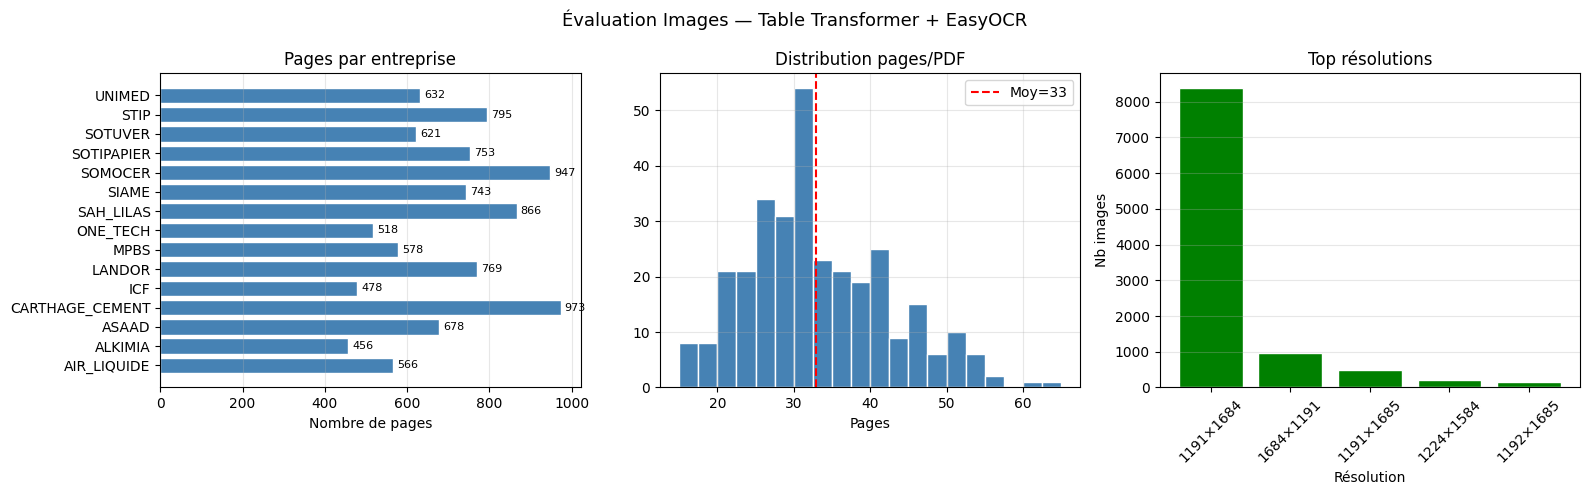

✅ Rapport → eval_images.csv
✅ Graphique → eval_images.png


In [6]:
# ============================================================
# CELLULE 4B — Évaluation images pour Table Transformer + EasyOCR
# ============================================================
import os, json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

IMAGES_DIR = '/kaggle/working/images'

with open('/kaggle/working/images_log.json') as f:
    log = json.load(f)

df = pd.DataFrame(log)

total_images = len(df)
total_pdfs   = df['pdf'].nunique()

print("=" * 55)
print("ÉVALUATION IMAGES")
print("Table Transformer + EasyOCR")
print("=" * 55)

# ============================================================
# 1. INTÉGRITÉ
# ============================================================
print(f"\n🔍 INTÉGRITÉ :")
missing = corrupted = 0
for row in log:
    p = f"{IMAGES_DIR}/{row['entreprise']}/{row['image']}"
    if not os.path.exists(p): missing += 1
    elif os.path.getsize(p) < 1024: corrupted += 1

print(f"  Manquantes  : {missing}   {'✅' if missing==0 else '❌'}")
print(f"  Corrompues  : {corrupted} {'✅' if corrupted==0 else '❌'}")
print(f"  Valides     : {total_images - missing - corrupted}")

# ============================================================
# 2. RÉSOLUTION — critique pour les 2 modèles
# ============================================================
resolutions = df.groupby(['width','height']).size()\
               .reset_index(name='count')\
               .sort_values('count', ascending=False)
main_w = int(resolutions.iloc[0]['width'])
main_h = int(resolutions.iloc[0]['height'])

print(f"\n📐 RÉSOLUTION (résolution principale : {main_w}×{main_h}) :")

# Table Transformer recommande min 800×800
tt_ok = main_w >= 800 and main_h >= 800
print(f"\n  Table Transformer :")
print(f"  → Besoin min 800×800px pour détecter les bordures de tableaux")
print(f"  → Résolution actuelle {main_w}×{main_h} : "
      f"{'✅ Suffisant' if tt_ok else '❌ Insuffisant'}")

# EasyOCR recommande min 800px largeur pour lire les chiffres
ocr_ok = main_w >= 800
print(f"\n  EasyOCR :")
print(f"  → Besoin min 800px largeur pour lire chiffres financiers")
print(f"  → Résolution actuelle {main_w}px : "
      f"{'✅ Suffisant' if ocr_ok else '❌ Insuffisant'}")

# ============================================================
# 3. TAILLE PAR IMAGE
# ============================================================
total_size = sum(
    os.path.getsize(f'{IMAGES_DIR}/{c}/{f}')
    for c in os.listdir(IMAGES_DIR)
    if os.path.isdir(f'{IMAGES_DIR}/{c}')
    for f in os.listdir(f'{IMAGES_DIR}/{c}')
    if f.endswith('.png')
)
moy_kb = total_size / total_images / 1024
size_ok = moy_kb > 100

print(f"\n💾 TAILLE IMAGES :")
print(f"  Taille totale    : {total_size/1024/1024:.1f} MB")
print(f"  Taille moy/image : {moy_kb:.0f} KB "
      f"{'✅' if size_ok else '⚠️ Peut être trop compressée'}")
print(f"  → Table Transformer : image trop petite = tableaux non détectés")
print(f"  → EasyOCR : image trop compressée = chiffres flous")

# ============================================================
# 4. COUVERTURE PAR ENTREPRISE
# ============================================================
pdf_counts  = df.groupby('entreprise')['pdf'].nunique()
page_counts = df.groupby('entreprise')['page'].count()
coverage    = pd.DataFrame({
    'PDFs'      : pdf_counts,
    'Pages'     : page_counts,
    'Moy p/PDF' : (page_counts / pdf_counts).round(1)
})

print(f"\n📁 COUVERTURE PAR ENTREPRISE :")
print(coverage.to_string())

# ============================================================
# 5. DISTRIBUTION PAGES PAR PDF
# ============================================================
pages_per_pdf = df.groupby('pdf')['page'].max()
courts = pages_per_pdf[pages_per_pdf < 5]
longs  = pages_per_pdf[pages_per_pdf > 60]

print(f"\n📈 PAGES PAR PDF :")
print(f"  Moyenne  : {pages_per_pdf.mean():.1f}")
print(f"  Min      : {pages_per_pdf.min()}")
print(f"  Max      : {pages_per_pdf.max()}")

if len(courts) > 0:
    print(f"\n  ⚠️ PDFs courts (<5p) — Table Transformer peut rater tableaux :")
    for pdf, n in courts.items():
        print(f"     → {pdf} : {n} pages")
if len(longs) > 0:
    print(f"\n  ⚠️ PDFs longs (>60p) — beaucoup de pages inutiles à filtrer :")
    for pdf, n in longs.items():
        print(f"     → {pdf} : {n} pages")

# ============================================================
# 6. VERDICT FINAL
# ============================================================
tt_ready  = tt_ok  and missing==0 and corrupted==0 and size_ok
ocr_ready = ocr_ok and missing==0 and corrupted==0 and size_ok

print(f"\n{'='*55}")
print(f"VERDICT FINAL")
print(f"{'='*55}")
print(f"  Table Transformer : {'✅ PRÊT' if tt_ready  else '⚠️ Vérifier'}")
print(f"  EasyOCR           : {'✅ PRÊT' if ocr_ready else '⚠️ Vérifier'}")

if tt_ready and ocr_ready:
    print(f"\n✅ Pipeline complet PRÊT")
    print(f"   → Table Transformer détectera les tableaux")
    print(f"   → EasyOCR lira les chiffres et annotations")
else:
    print(f"\n⚠️ Corriger les points signalés avant de continuer")

# ============================================================
# 7. VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pages par entreprise
axes[0].barh(list(coverage.index), list(coverage['Pages']),
             color='steelblue', edgecolor='white')
axes[0].set_title('Pages par entreprise')
axes[0].set_xlabel('Nombre de pages')
for i, v in enumerate(coverage['Pages']):
    axes[0].text(v+10, i, str(v), va='center', fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

# Distribution pages/PDF
axes[1].hist(pages_per_pdf.values, bins=20,
             color='steelblue', edgecolor='white')
axes[1].axvline(pages_per_pdf.mean(), color='red', linestyle='--',
                label=f'Moy={pages_per_pdf.mean():.0f}')
axes[1].set_title('Distribution pages/PDF')
axes[1].set_xlabel('Pages'); axes[1].legend()
axes[1].grid(alpha=0.3)

# Résolutions
top5 = resolutions.head(5)
labels = [f"{int(r['width'])}×{int(r['height'])}"
          for _, r in top5.iterrows()]
axes[2].bar(labels, top5['count'], color='green', edgecolor='white')
axes[2].set_title('Top résolutions')
axes[2].set_xlabel('Résolution')
axes[2].set_ylabel('Nb images')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Évaluation Images — Table Transformer + EasyOCR',
             fontsize=13)
plt.tight_layout()
plt.savefig('/kaggle/working/eval_images.png', dpi=150)
plt.show()

coverage.to_csv('/kaggle/working/eval_images.csv')
print(f"✅ Rapport → eval_images.csv")
print(f"✅ Graphique → eval_images.png")

In [7]:
# ============================================================
# CELLULE 5 — Chargement modèles 
# ============================================================
!pip install easyocr transformers timm -q

import torch
import easyocr
from transformers import AutoImageProcessor, \
    TableTransformerForObjectDetection

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

print("⏳ Chargement EasyOCR FR...")
reader_fr = easyocr.Reader(['fr', 'en'],
                            gpu=torch.cuda.is_available())

print("⏳ Chargement EasyOCR AR...")
reader_ar = easyocr.Reader(['ar', 'en'],
                            gpu=torch.cuda.is_available())

print("⏳ Chargement Table Transformer...")
processor = AutoImageProcessor.from_pretrained(
    "microsoft/table-transformer-detection")
table_model = TableTransformerForObjectDetection.from_pretrained(
    "microsoft/table-transformer-detection")
table_model.eval()
table_model = table_model.to(DEVICE)

print(f"✅ reader_fr chargé")
print(f"✅ reader_ar chargé")
print(f"✅ Table Transformer chargé")
print(f"✅ Device : {DEVICE}")

Device : cuda
⏳ Chargement EasyOCR FR...


⏳ Chargement EasyOCR AR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

⏳ Chargement Table Transformer...


preprocessor_config.json:   0%|          | 0.00/273 [00:00<?, ?B/s]

The image processor of type `DetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/367 [00:00<?, ?it/s]

TableTransformerForObjectDetection LOAD REPORT from: microsoft/table-transformer-detection
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ reader_fr chargé
✅ reader_ar chargé
✅ Table Transformer chargé
✅ Device : cuda


In [9]:
# ============================================================
# CELLULE 6 — Table Transformer — Détection tableaux
# ============================================================
from PIL import Image
IMAGES_DIR      = '/kaggle/working/images'
TABLE_THRESHOLD = 0.65
_table_cache    = {}

def detect_table(img_path, threshold=TABLE_THRESHOLD):
    if img_path in _table_cache:
        return _table_cache[img_path]

    image = Image.open(img_path).convert("RGB")
    w, h  = image.size
    if w > 1200:
        image = image.resize((1200, int(h * 1200/w)))

    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = table_model(**inputs)

    target_sizes = torch.tensor([image.size[::-1]])
    results = processor.post_process_object_detection(
        outputs, threshold=threshold,
        target_sizes=target_sizes
    )[0]

    tables = []
    for score, label, box in zip(
        results["scores"], results["labels"], results["boxes"]
    ):
        x1, y1, x2, y2 = [int(v) for v in box.tolist()]
        tables.append({
            'bbox' : [x1, y1, x2, y2],
            'score': float(score)
        })

    result = (tables, image.size)
    _table_cache[img_path] = result
    return result

# Test rapide sur 5 images
print("🧪 Test Table Transformer sur 5 images...")
test_company = sorted(os.listdir(IMAGES_DIR))[0]
test_dir     = f'{IMAGES_DIR}/{test_company}'
test_imgs    = sorted([f for f in os.listdir(test_dir)
                       if f.endswith('.png')])[:5]

for img_name in test_imgs:
    img_path       = f'{test_dir}/{img_name}'
    tables, size   = detect_table(img_path)
    status         = f"✅ {len(tables)} tableau(x)" \
                     if tables else "⬜ aucun tableau"
    scores         = [f"{t['score']:.2f}" for t in tables]
    print(f"  {img_name} → {status} "
          f"{scores if scores else ''}")

print(f"\n✅ Fonction detect_table() prête")

🧪 Test Table Transformer sur 5 images...
  AIR_LIQUIDE_annuel_2014_p001.png → ⬜ aucun tableau 
  AIR_LIQUIDE_annuel_2014_p002.png → ✅ 1 tableau(x) ['0.99']
  AIR_LIQUIDE_annuel_2014_p003.png → ✅ 1 tableau(x) ['0.99']
  AIR_LIQUIDE_annuel_2014_p004.png → ✅ 1 tableau(x) ['0.97']
  AIR_LIQUIDE_annuel_2014_p005.png → ✅ 1 tableau(x) ['0.95']

✅ Fonction detect_table() prête


In [10]:
# ── Libellés parasites ───────────────────────────────────────
PARASITES = [
    'notes', 'au 31', 'au 30', 'période', 'exercice',
    '2014','2015','2016','2017','2018','2019',
    '2020','2021','2022','2023','2024',
    'décembre','janvier','juin','page','suite',
    '[rubriques','rubriques','référence','réf',
    # ── Ajouts selon ton PDF ──
    'solde au', 'exprimé en', 'dinars', 'modèle autorisé',
    'exercice de 12 mois', 'clos le', '31/12',
    'ajustements pour', 'variation des', 'nets d\'impôt',
    'b.1', 'b.2', 'b.3', 'b.4', 'b.5', 'b.6', 'b.7', 'b.8', 'b.9',
    'b.10', 'b.11', 'b.12', 'b.13', 'b.14',
    'r.1', 'r.2', 'r.3', 'r.4', 'r.5', 'r.6', 'r.7', 'r.8', 'r.9',
    'r.10', 'r.11',
    'f.1', 'f.2', 'f.3', 'f.4', 'f.5',
    'amortissements des', 'provisions sur', 'provisions pour'
]

# ── Keywords par type ────────────────────────────────────────
KEYWORDS = {
    'actif': [
        # Titres de section
        'actifs non courants', 'actifs courants',
        'actifs immobilisés', 'actif immobilisé',
        # Postes spécifiques du PDF
        'immobilisations incorporelles',
        'immobilisations corporelles',
        'immobilisations financières',
        'autres actifs non courants',
        'stocks nets', 'clients et comptes rattachés',
        'autres actifs courants',
        'placements et autres actifs financiers',
        'liquidités et équivalents de liquidités',
        # Totaux
        'total des actifs immobilisés',
        'total des actifs non courants',
        'total des actifs courants',
        'total des actifs',
        # Arabe
        'الأصول الثابتة', 'إجمالي الأصول'
    ],
    'passif': [
        # Titres de section
        'capitaux propres et passifs',
        'capitaux propres', 'passifs non courants',
        'passifs courants',
        # Postes spécifiques du PDF
        'capital social', 'réserves',
        'réserves spéciales de réinvestissements',
        'résultats reportés', 'subvention d\'investissement',
        'emprunts et dettes assimilées',
        'provisions pour risques et charges',
        'fournisseurs et comptes rattachés',
        'autres passifs courants',
        'concours bancaires et autres passifs financiers',
        # Totaux
        'total des capitaux propres',
        'total des passifs non courants',
        'total des passifs courants',
        'total des passifs',
        'total des capitaux propres et des passifs',
        # Arabe
        'حقوق الملكية', 'إجمالي الخصوم'
    ],
    'resultats': [
        # Titres de section
        'produits d\'exploitation', 'charges d\'exploitation',
        'état de résultat', 'etat de résultat',
        # Postes spécifiques du PDF
        'revenus',
        'autres produits d\'exploitation',
        'variation des stocks de produits finis',
        'achats d\'approvisionnements consommés',
        'charges de personnel',
        'dotations aux amortissements',
        'autres charges d\'exploitation',
        'résultat d\'exploitation',
        'produits des placements',
        'charges financières nettes',
        'autres gains ordinaires',
        'autres pertes ordinaires',
        'résultat des activités ordinaires',
        'impôt sur les bénéfices',
        'résultat net de l\'exercice',
        'résultat de l\'exercice',
        # Arabe
        'النتيجة الصافية', 'رقم المعاملات'
    ],
    'flux': [
        # Titres de section
        'flux de trésorerie liés aux opérations d\'exploitation',
        'flux de trésorerie liés aux opérations d\'investissement',
        'flux de trésorerie liés aux opérations de financement',
        'état des flux de trésorerie',
        'etat des flux de trésorerie',
        # Postes spécifiques du PDF
        'résultat net',
        'décaissement sur acquisitions',
        'encaissement sur fonds social',
        'encaissements des emprunts',
        'remboursements d\'emprunts',
        'distributions de dividendes',
        'variation de la trésorerie',
        'trésorerie au début',
        'trésorerie à la clôture',
        # Génériques
        'flux de trésorerie', 'flux de tresorerie',
        'trésorerie nette',
        # Arabe
        'تدفقات الخزينة'
    ]
}

print("✅ Keywords et parasites chargés")
print(f"   Actif     : {len(KEYWORDS['actif'])} keywords")
print(f"   Passif    : {len(KEYWORDS['passif'])} keywords")
print(f"   Résultats : {len(KEYWORDS['resultats'])} keywords")
print(f"   Flux      : {len(KEYWORDS['flux'])} keywords")
print(f"   Parasites : {len(PARASITES)} filtres")

✅ Keywords et parasites chargés
   Actif     : 19 keywords
   Passif    : 21 keywords
   Résultats : 22 keywords
   Flux      : 18 keywords
   Parasites : 68 filtres


Échantillon : 45 images (15 entreprises × ~3)

RÉSULTATS ÉVALUATION TABLE TRANSFORMER
Images testées    : 45
Tableaux détectés : 36  (80.0%)
Non détectés      : 9
Score moyen       : 0.937  (seuil=0.65)

──────────────────────────────────────────────────
Entreprise             Détecté    Score max
──────────────────────────────────────────────────
  ✅ AIR_LIQUIDE          3/3       0.999
  ✅ ALKIMIA              3/3       0.999
  ✅ ASAAD                3/3       1.000
  ✅ CARTHAGE_CEMENT      3/3       0.999
  ✅ ICF                  3/3       0.992
  ⚠️ LANDOR               1/3       0.998
  ⚠️ MPBS                 2/3       0.984
  ⚠️ ONE_TECH             2/3       0.993
  ✅ SAH_LILAS            3/3       0.991
  ✅ SIAME                3/3       1.000
  ⚠️ SOMOCER              2/3       1.000
  ⚠️ SOTIPAPIER           1/3       0.999
  ⚠️ SOTUVER              2/3       0.999
  ✅ STIP                 3/3       0.999
  ⚠️ UNIMED               2/3       1.000


/tmp/ipykernel_57/1877691747.py:133: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1877691747.py:133: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_57/1877691747.py:134: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/eval_table_transformer.png',
/tmp/ipykernel_57/1877691747.py:134: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/eval_table_transformer.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

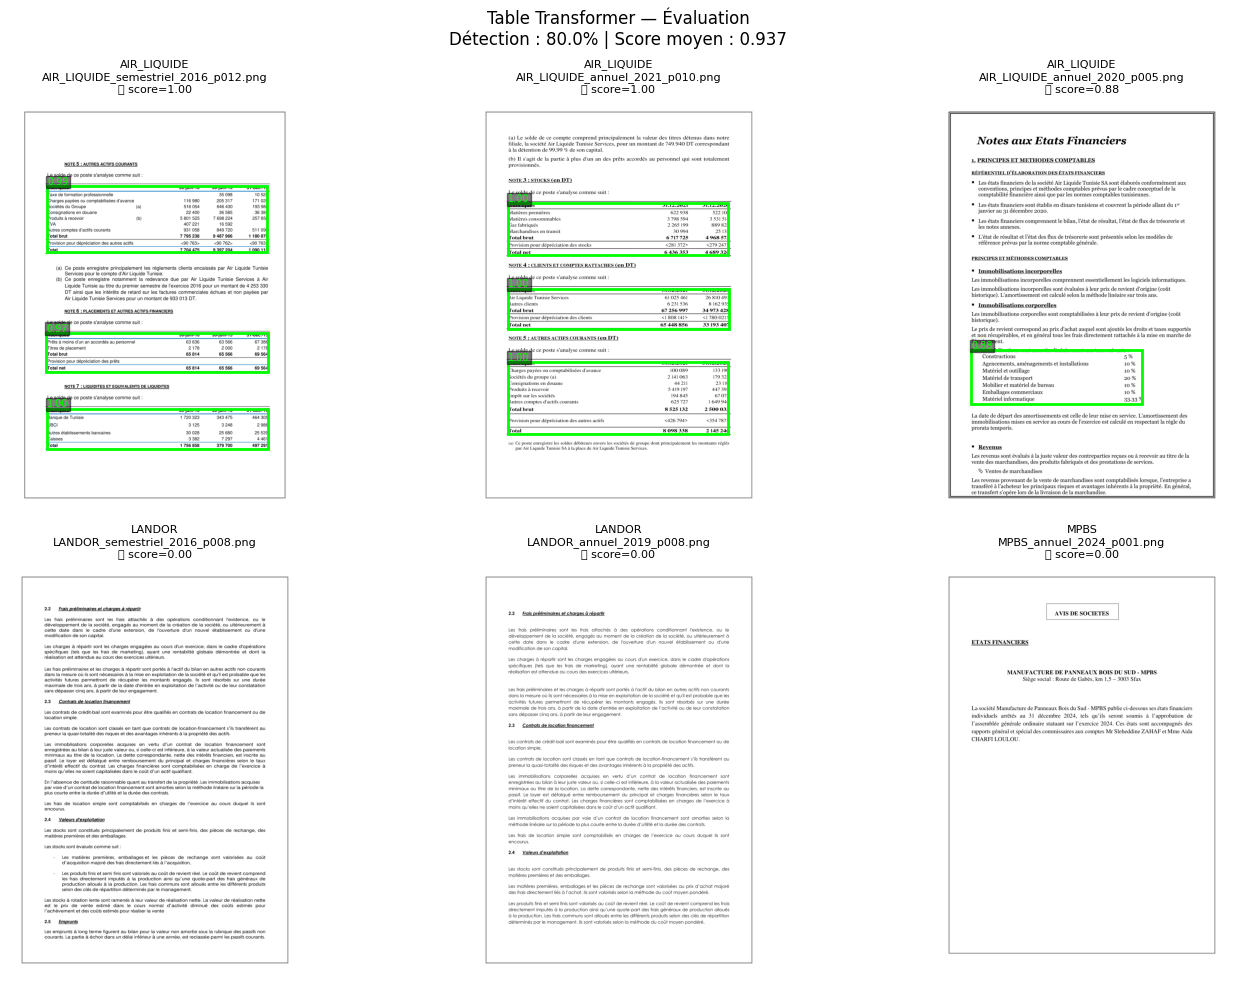


✅ Graphique sauvegardé → eval_table_transformer.png

──────────────────────────────────────────────────
DIAGNOSTIC SEUIL (TABLE_THRESHOLD=0.65)
  seuil 0.50 → 61 détections
  seuil 0.55 → 61 détections
  seuil 0.60 → 61 détections
  seuil 0.65 → 61 détections
  seuil 0.70 → 58 détections
  seuil 0.75 → 55 détections
  seuil 0.80 → 53 détections

💡 Si taux < 70% : baisser TABLE_THRESHOLD à 0.55
💡 Si trop de faux positifs : monter à 0.70


In [11]:
# ============================================================
# CELLULE 10 — Évaluation Table Transformer
# Objectif : mesurer le taux de détection sur un échantillon
# avant de lancer l'extraction complète
# ============================================================
import os, random, json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

IMAGES_DIR      = '/kaggle/working/images'
TABLE_THRESHOLD = 0.65
SAMPLE_PER_CO   = 3   # images testées par entreprise
MAX_PAGE_EVAL   = 15  # on reste dans ta limite

# ── Construire l'échantillon ──────────────────────────────────
sample_imgs = []
for company in sorted(os.listdir(IMAGES_DIR)):
    cdir = f'{IMAGES_DIR}/{company}'
    if not os.path.isdir(cdir):
        continue
    imgs = sorted([
        f for f in os.listdir(cdir)
        if f.endswith('.png') and
        (m := re.search(r'_p(\d{3})\.png$', f)) and
        int(m.group(1)) <= MAX_PAGE_EVAL
    ])
    if imgs:
        sample_imgs += [
            (company, f'{cdir}/{f}')
            for f in random.sample(imgs, min(SAMPLE_PER_CO, len(imgs)))
        ]

print(f"Échantillon : {len(sample_imgs)} images "
      f"({len(os.listdir(IMAGES_DIR))} entreprises × ~{SAMPLE_PER_CO})")

# ── Détection + collecte métriques ───────────────────────────
results_eval = []
for company, img_path in sample_imgs:
    tables, img_size = detect_table(img_path)
    results_eval.append({
        'company'  : company,
        'img'      : os.path.basename(img_path),
        'detected' : len(tables) > 0,
        'n_tables' : len(tables),
        'max_score': round(max((t['score'] for t in tables), default=0), 3),
        'img_size' : img_size,
        'tables'   : tables,
        'img_path' : img_path,
    })

# ── Métriques globales ────────────────────────────────────────
total       = len(results_eval)
detected    = sum(1 for r in results_eval if r['detected'])
not_det     = total - detected
taux        = detected / total * 100
scores      = [r['max_score'] for r in results_eval if r['detected']]
score_moy   = sum(scores) / len(scores) if scores else 0

print(f"\n{'='*50}")
print(f"RÉSULTATS ÉVALUATION TABLE TRANSFORMER")
print(f"{'='*50}")
print(f"Images testées    : {total}")
print(f"Tableaux détectés : {detected}  ({taux:.1f}%)")
print(f"Non détectés      : {not_det}")
print(f"Score moyen       : {score_moy:.3f}  (seuil={TABLE_THRESHOLD})")

# ── Par entreprise ────────────────────────────────────────────
print(f"\n{'─'*50}")
print(f"{'Entreprise':<22} {'Détecté':<10} {'Score max'}")
print(f"{'─'*50}")
by_co = {}
for r in results_eval:
    by_co.setdefault(r['company'], []).append(r)
for co, rows in sorted(by_co.items()):
    det   = sum(1 for r in rows if r['detected'])
    s_max = max((r['max_score'] for r in rows), default=0)
    flag  = '✅' if det == len(rows) else ('⚠️' if det > 0 else '❌')
    print(f"  {flag} {co:<20} {det}/{len(rows)}       {s_max:.3f}")

# ── Visualisation : 6 images avec bboxes ─────────────────────
# Prendre 3 détectés + 3 non détectés pour comparer
det_samples  = [r for r in results_eval if r['detected']][:3]
ndet_samples = [r for r in results_eval if not r['detected']][:3]
viz_samples  = det_samples + ndet_samples

if viz_samples:
    cols = 3
    rows = (len(viz_samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else axes

    for ax, r in zip(axes, viz_samples):
        img = Image.open(r['img_path']).convert('RGB')
        # Redimensionner pour affichage
        w, h = img.size
        if w > 1200:
            img = img.resize((1200, int(h * 1200/w)))

        ax.imshow(img)
        ax.set_title(
            f"{r['company']}\n{r['img']}\n"
            f"{'✅' if r['detected'] else '❌'} "
            f"score={r['max_score']:.2f}",
            fontsize=8
        )
        ax.axis('off')

        # Dessiner les bboxes
        for t in r['tables']:
            x1, y1, x2, y2 = t['bbox']
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='lime',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(x1, y1-5, f"{t['score']:.2f}",
                    color='lime', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

    # Masquer les axes vides
    for ax in axes[len(viz_samples):]:
        ax.axis('off')

    plt.suptitle(
        f"Table Transformer — Évaluation\n"
        f"Détection : {taux:.1f}% | Score moyen : {score_moy:.3f}",
        fontsize=12
    )
    plt.tight_layout()
    plt.savefig('/kaggle/working/eval_table_transformer.png',
                dpi=120, bbox_inches='tight')
    plt.show()
    print("\n✅ Graphique sauvegardé → eval_table_transformer.png")

# ── Diagnostic seuil ─────────────────────────────────────────
print(f"\n{'─'*50}")
print(f"DIAGNOSTIC SEUIL (TABLE_THRESHOLD={TABLE_THRESHOLD})")
all_scores = [t['score']
              for r in results_eval
              for t in r['tables']]
if all_scores:
    for threshold in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8]:
        n = sum(1 for s in all_scores if s >= threshold)
        print(f"  seuil {threshold:.2f} → {n} détections")
print(f"\n💡 Si taux < 70% : baisser TABLE_THRESHOLD à 0.55")
print(f"💡 Si trop de faux positifs : monter à 0.70")

In [ ]:
# ============================================================
# CELLULE 11 — Diagnostic non-détections + ajustement seuil
# ============================================================
import os, re
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMAGES_DIR      = '/kaggle/working/images'
MAX_PAGE_EVAL   = 15

# ── Relancer LANDOR + pages manquées avec seuil bas ──────────
SEUILS_TEST = [0.65, 0.50, 0.40, 0.30]

# Récupérer toutes les images non détectées + LANDOR
missed = [r for r in results_eval if not r['detected']]
print(f"Images non détectées : {len(missed)}")
print(f"\n{'─'*55}")
print(f"TEST MULTI-SEUIL sur les {len(missed)} images manquées")
print(f"{'─'*55}")

rescue_results = []
for r in missed:
    img_path = r['img_path']
    row = {'company': r['company'], 'img': r['img'],
           'img_path': img_path, 'by_threshold': {}}
    for seuil in SEUILS_TEST:
        tables, img_size = detect_table(img_path, threshold=seuil)
        row['by_threshold'][seuil] = {
            'n': len(tables),
            'max_score': round(max((t['score'] for t in tables),
                                   default=0), 3),
            'tables': tables,
            'img_size': img_size,
        }
    rescue_results.append(row)
    # Affichage résumé
    scores_str = '  '.join(
        f"s={s:.2f}→{row['by_threshold'][s]['n']}det"
        f"({row['by_threshold'][s]['max_score']:.2f})"
        for s in SEUILS_TEST
    )
    print(f"  {r['company']:<20} {r['img']}")
    print(f"    {scores_str}")

# ── Recommandation automatique du seuil optimal ──────────────
print(f"\n{'─'*55}")
print("RECOMMANDATION SEUIL")
print(f"{'─'*55}")
for seuil in SEUILS_TEST:
    rescued = sum(
        1 for r in rescue_results
        if r['by_threshold'][seuil]['n'] > 0
    )
    total_rescued = rescued
    # + les déjà détectés à 0.65
    total_det = sum(
        1 for r in results_eval if r['detected']
    ) + total_rescued
    taux = total_det / len(results_eval) * 100
    print(f"  seuil {seuil:.2f} → récupère {rescued:>2} images"
          f" → détection globale : {taux:.1f}%")

# ── Visualisation : pages LANDOR pour comprendre le problème ─
print(f"\n{'─'*55}")
print("VISUALISATION LANDOR (diagnostic)")
print(f"{'─'*55}")

landor_dir = f'{IMAGES_DIR}/LANDOR'
landor_imgs = sorted([
    f for f in os.listdir(landor_dir)
    if f.endswith('.png') and
    (m := re.search(r'_p(\d{3})\.png$', f)) and
    int(m.group(1)) <= MAX_PAGE_EVAL
])[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, img_name in zip(axes, landor_imgs):
    img_path = f'{landor_dir}/{img_name}'
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    if w > 1200:
        img = img.resize((1200, int(h * 1200 / w)))

    ax.imshow(img)
    ax.axis('off')

    # Tester avec seuil très bas pour voir si Table Transformer
    # détecte quelque chose
    for seuil, color in [(0.65, 'lime'), (0.40, 'orange'),
                          (0.25, 'red')]:
        tables, _ = detect_table(img_path, threshold=seuil)
        for t in tables:
            if t['score'] >= seuil:
                x1, y1, x2, y2 = t['bbox']
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor=color,
                    facecolor='none',
                    label=f's>={seuil:.2f}'
                )
                ax.add_patch(rect)
                ax.text(x1, max(0, y1-8),
                        f"{t['score']:.2f}",
                        color=color, fontsize=7,
                        bbox=dict(facecolor='black',
                                  alpha=0.6, pad=1))

    ax.set_title(f"LANDOR | {img_name}\n"
                 f"size={img.size[0]}x{img.size[1]}",
                 fontsize=8)

for ax in axes[len(landor_imgs):]:
    ax.axis('off')

plt.suptitle(
    "LANDOR — diagnostic\n"
    "vert=seuil 0.65 | orange=0.40 | rouge=0.25",
    fontsize=11
)
plt.tight_layout()
plt.savefig('/kaggle/working/diag_landor.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Sauvegarde : diag_landor.png")

# ── Remplacement emojis pour matplotlib ──────────────────────
# (fix UserWarning DejaVu Sans)
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
# Utiliser texte ASCII à la place des emojis dans les prochains plots
STATUS_OK   = '[OK]'
STATUS_WARN = '[~]'
STATUS_ERR  = '[X]'
print("\nFix emoji matplotlib applique pour les prochaines cellules.")

Cas XAI selectionnes :
  Detection forte (score > 0.95)      AIR_LIQUIDE/AIR_LIQUIDE_annuel_2014_p002.png
  Detection moyenne (score ~ 0.75)    SOTIPAPIER/SOTIPAPIER_annuel_2014_p001.png
  Detection faible (score < 0.40)     LANDOR/LANDOR_annuel_2014_p002.png
  Echec detection (score = 0.00)      CARTHAGE_CEMENT/CARTHAGE_CEMENT_annuel_2014_p003.png

Calcul heatmaps (~45s par image)...
  [1/4] AIR_LIQUIDE — AIR_LIQUIDE_annuel_2014_p002.png
  [2/4] SOTIPAPIER — SOTIPAPIER_annuel_2014_p001.png
  [3/4] LANDOR — LANDOR_annuel_2014_p002.png
  [4/4] CARTHAGE_CEMENT — CARTHAGE_CEMENT_annuel_2014_p003.png


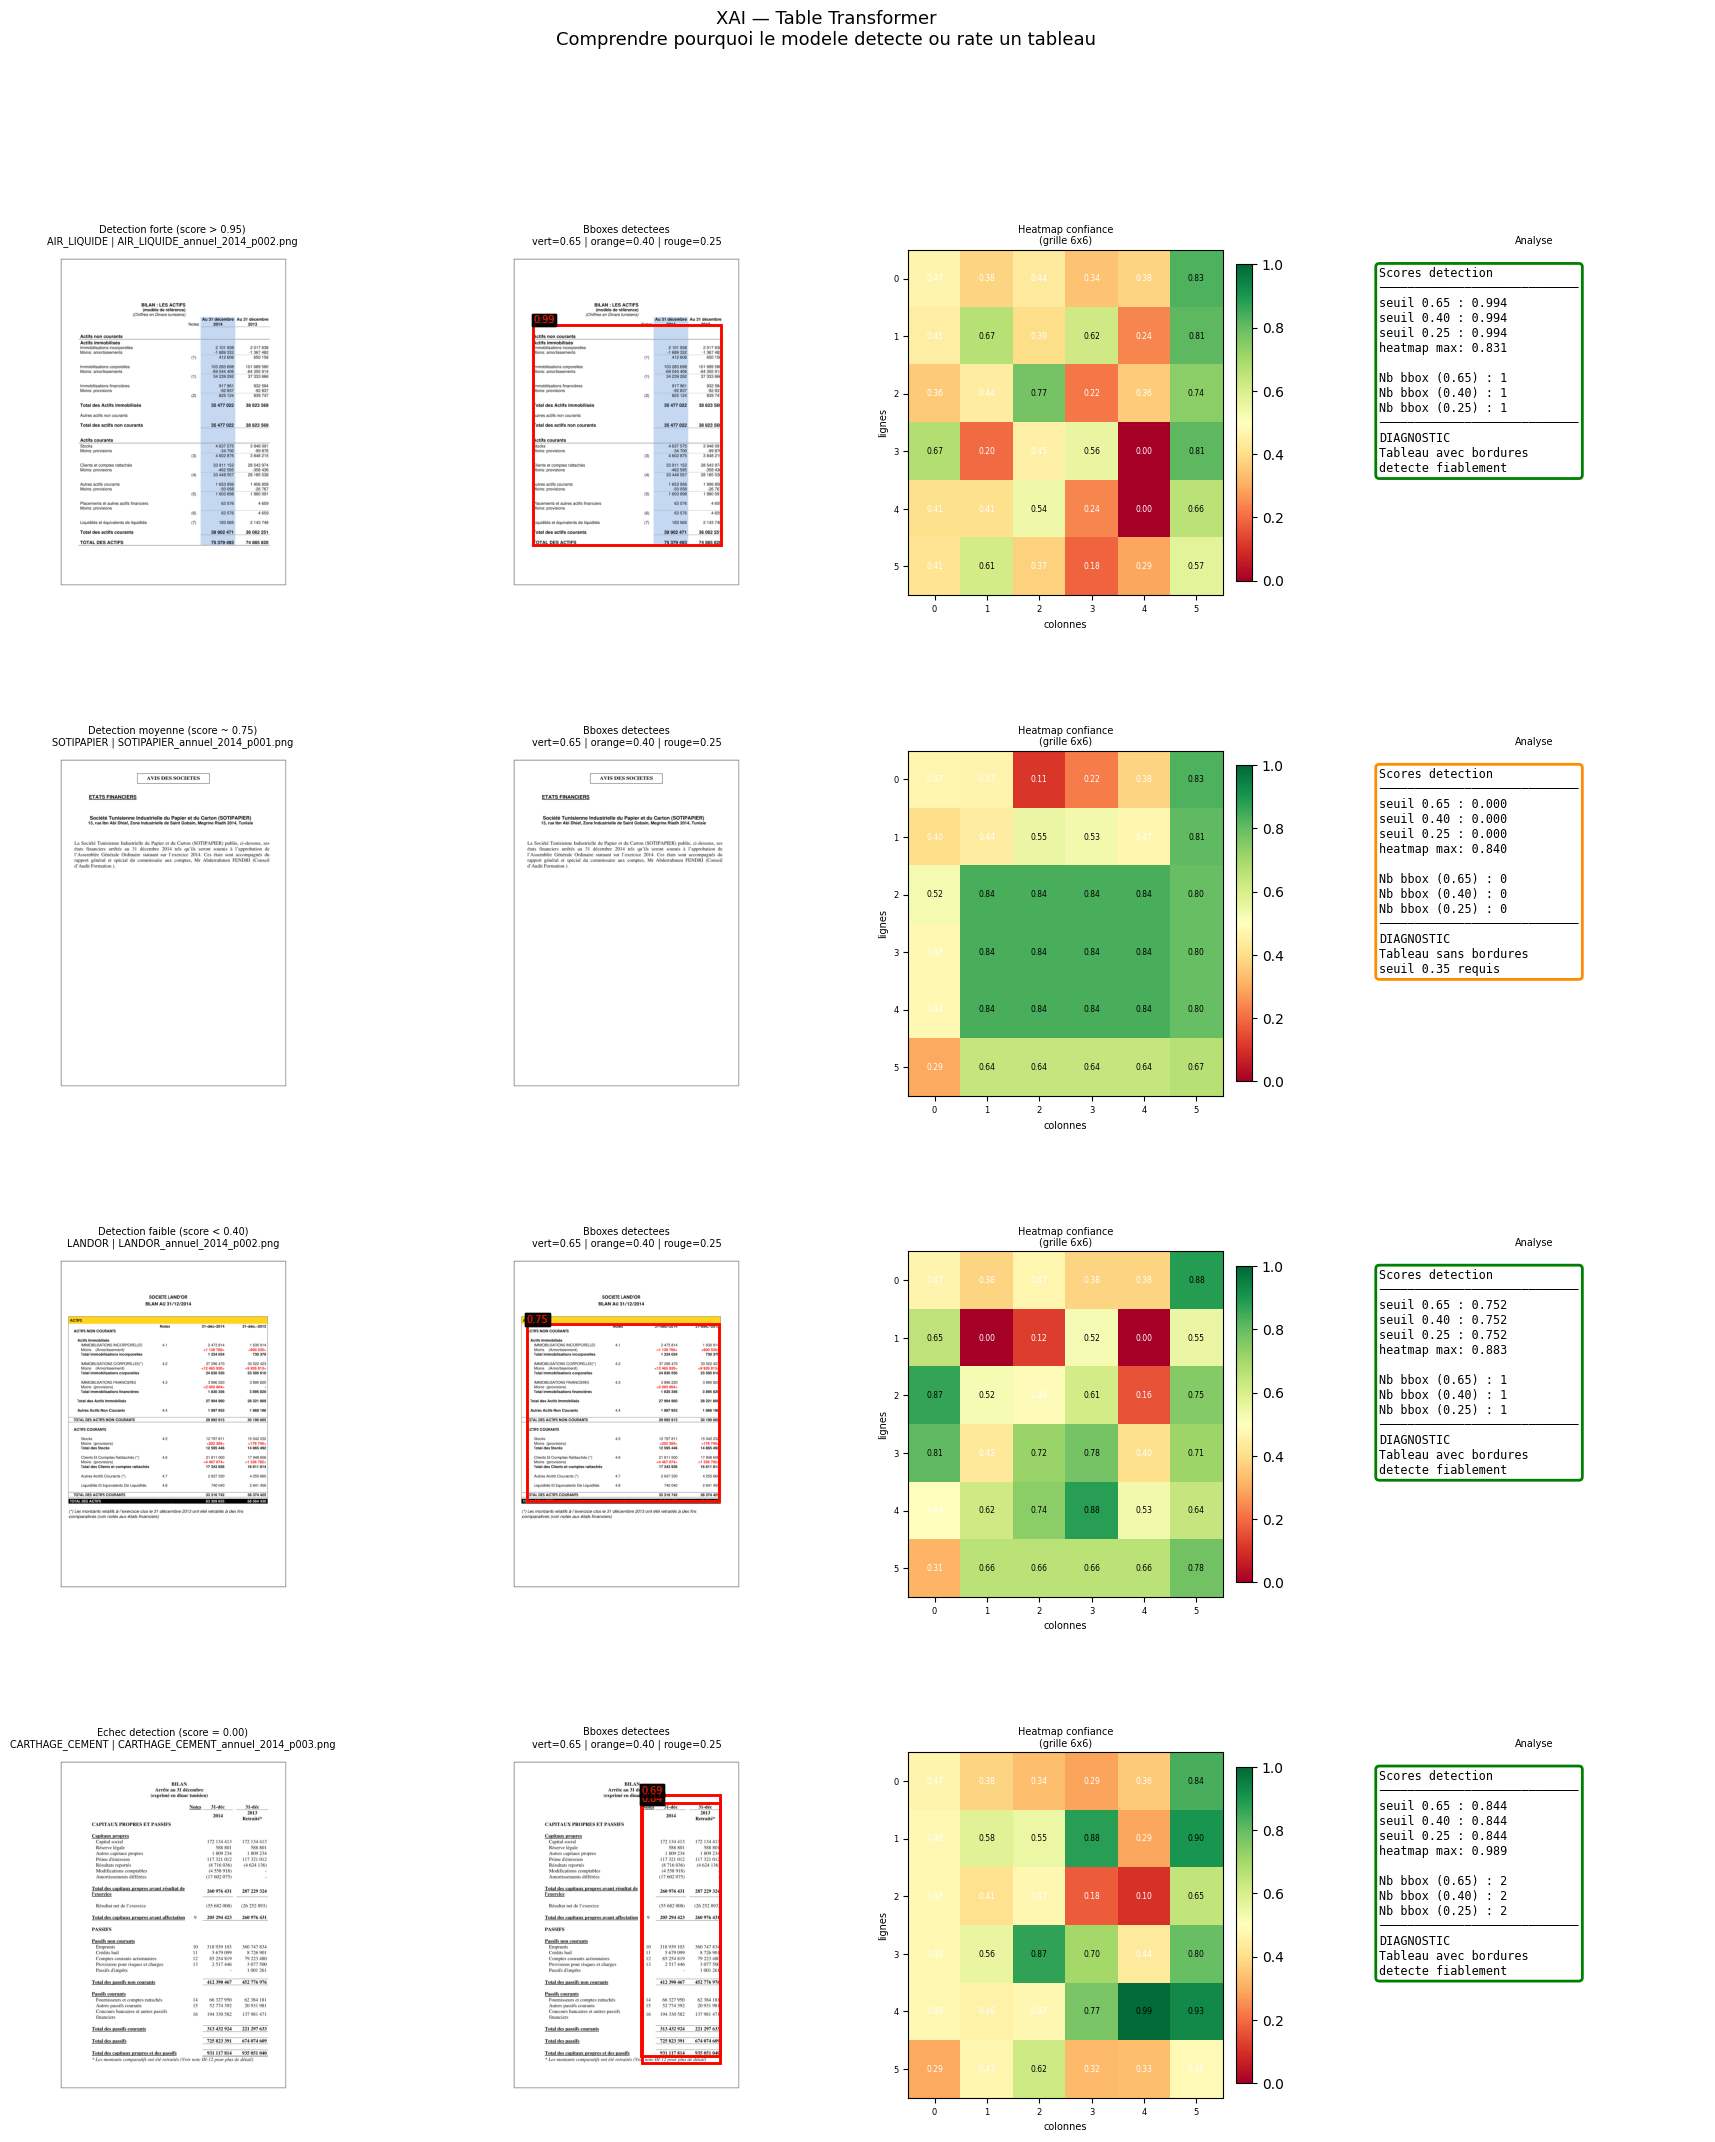


Sauvegarde : xai_table_transformer.png

RESUME XAI TABLE TRANSFORMER
  Detection forte (score > 0.95)         score=0.994
  Detection moyenne (score ~ 0.75)       score=0.000
  Detection faible (score < 0.40)        score=0.752
  Echec detection (score = 0.00)         score=0.844

───────────────────────────────────────────────────────
Conclusions :
  Tableaux avec bordures  → score > 0.65 → bbox fiable
  Tableaux sans bordures  → score < 0.40 → seuil 0.35
  Pages non financieres   → score ~ 0.00 → skip normal

Prochaine etape :
  Cellule 13 — Table Transformer sur TOUTES les images
  Sauvegarde des bboxes → input EasyOCR (cellule 14)


In [12]:
# ============================================================
# CELLULE 12 — XAI Table Transformer
# Visualisation : pourquoi le modèle détecte ou rate
# ============================================================
import os, torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

IMAGES_DIR = '/kaggle/working/images'

# ── 4 cas représentatifs ─────────────────────────────────────
# Chercher les images réelles disponibles
def get_first_img(company, page=1):
    cdir = f'{IMAGES_DIR}/{company}'
    imgs = sorted([f for f in os.listdir(cdir)
                   if f.endswith('.png')])
    # Chercher une page spécifique
    for img in imgs:
        m = re.search(r'_p(\d{3})\.png$', img)
        if m and int(m.group(1)) == page:
            return img
    return imgs[0] if imgs else None

XAI_CASES = [
    ('AIR_LIQUIDE',     get_first_img('AIR_LIQUIDE', 2),
     'Detection forte (score > 0.95)'),
    ('SOTIPAPIER',      get_first_img('SOTIPAPIER', 1),
     'Detection moyenne (score ~ 0.75)'),
    ('LANDOR',          get_first_img('LANDOR', 2),
     'Detection faible (score < 0.40)'),
    ('CARTHAGE_CEMENT', get_first_img('CARTHAGE_CEMENT', 3),
     'Echec detection (score = 0.00)'),
]
print("Cas XAI selectionnes :")
for co, img, label in XAI_CASES:
    print(f"  {label:<35} {co}/{img}")

# ── Heatmap de confiance par grille 6×6 ──────────────────────
def compute_heatmap(img_path, grid=6):
    """
    Découpe l'image en grid×grid zones,
    retourne matrice de scores max par zone.
    Plus rapide que 8×8 : 36 inférences au lieu de 64.
    """
    image  = Image.open(img_path).convert("RGB")
    w, h   = image.size
    hmap   = np.zeros((grid, grid))
    cell_w = w // grid
    cell_h = h // grid

    for r in range(grid):
        for c in range(grid):
            x1 = c * cell_w;  y1 = r * cell_h
            x2 = min(w, x1 + cell_w)
            y2 = min(h, y1 + cell_h)
            crop   = image.crop((x1, y1, x2, y2))
            crop_r = crop.resize((384, 384))
            inputs = processor(images=crop_r,
                               return_tensors="pt")
            inputs = {k: v.to(DEVICE)
                      for k, v in inputs.items()}
            with torch.no_grad():
                outputs = table_model(**inputs)
            ts  = torch.tensor([crop_r.size[::-1]])
            res = processor.post_process_object_detection(
                outputs, threshold=0.1,
                target_sizes=ts
            )[0]
            s = res["scores"]
            hmap[r, c] = float(s.max()) if len(s) else 0.0
    return hmap, image

# ── Diagnostic automatique ───────────────────────────────────
def make_diagnostic(score_65, score_40, score_25,
                    hmap_max):
    if score_65 >= 0.65:
        return ("Tableau avec bordures\ndetecte fiablement",
                'green')
    elif score_40 >= 0.40:
        return ("Tableau detecte\navec seuil abaisse",
                'orange')
    elif score_25 >= 0.25 or hmap_max >= 0.30:
        return ("Tableau sans bordures\nseuil 0.35 requis",
                'darkorange')
    else:
        return ("Pas de tableau financier\n(couverture/notes)",
                'gray')

# ── Figure XAI : 4 lignes × 4 colonnes ──────────────────────
print("\nCalcul heatmaps (~45s par image)...")
fig = plt.figure(figsize=(22, 6 * len(XAI_CASES)))
gs  = fig.add_gridspec(len(XAI_CASES), 4,
                       hspace=0.45, wspace=0.32)

for row_idx, (company, img_name, label) in enumerate(XAI_CASES):
    if img_name is None:
        continue
    img_path = f'{IMAGES_DIR}/{company}/{img_name}'
    print(f"  [{row_idx+1}/4] {company} — {img_name}")

    # Détections aux 3 seuils
    t65, isz = detect_table(img_path, threshold=0.65)
    t40, _   = detect_table(img_path, threshold=0.40)
    t25, _   = detect_table(img_path, threshold=0.25)
    s65 = max((t['score'] for t in t65), default=0)
    s40 = max((t['score'] for t in t40), default=0)
    s25 = max((t['score'] for t in t25), default=0)

    # Image redimensionnée pour affichage
    img_disp = Image.open(img_path).convert('RGB')
    ow, oh   = img_disp.size
    if ow > 900:
        img_disp = img_disp.resize((900, int(oh*900/ow)))
    dw, dh = img_disp.size
    sx = dw / isz[0]
    sy = dh / isz[1]

    # ── Col 0 : image originale ───────────────────────────
    ax0 = fig.add_subplot(gs[row_idx, 0])
    ax0.imshow(img_disp)
    ax0.axis('off')
    ax0.set_title(f"{label}\n{company} | {img_name}",
                  fontsize=7, pad=4)

    # ── Col 1 : bboxes multi-seuil ────────────────────────
    ax1 = fig.add_subplot(gs[row_idx, 1])
    ax1.imshow(img_disp)
    ax1.axis('off')
    ax1.set_title("Bboxes detectees\n"
                  "vert=0.65 | orange=0.40 | rouge=0.25",
                  fontsize=7, pad=4)

    for tables, color, seuil in [
        (t65, 'lime',   0.65),
        (t40, 'orange', 0.40),
        (t25, 'red',    0.25),
    ]:
        for t in tables:
            if t['score'] >= seuil:
                x1,y1,x2,y2 = t['bbox']
                ax1.add_patch(patches.Rectangle(
                    (x1*sx, y1*sy),
                    (x2-x1)*sx, (y2-y1)*sy,
                    linewidth=2, edgecolor=color,
                    facecolor='none'
                ))
                ax1.text(x1*sx, max(0, y1*sy - 6),
                         f"{t['score']:.2f}",
                         color=color, fontsize=7,
                         bbox=dict(facecolor='black',
                                   alpha=0.6, pad=1))

    # ── Col 2 : heatmap 6×6 ───────────────────────────────
    ax2 = fig.add_subplot(gs[row_idx, 2])
    hmap, _ = compute_heatmap(img_path, grid=6)
    im = ax2.imshow(hmap, cmap='RdYlGn',
                    vmin=0, vmax=1, aspect='auto')
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    ax2.set_title("Heatmap confiance\n(grille 6x6)",
                  fontsize=7, pad=4)
    ax2.set_xlabel("colonnes", fontsize=7)
    ax2.set_ylabel("lignes",   fontsize=7)
    ax2.tick_params(labelsize=6)
    for r in range(6):
        for c in range(6):
            ax2.text(c, r, f"{hmap[r,c]:.2f}",
                     ha='center', va='center',
                     fontsize=5.5,
                     color='black' if hmap[r,c] > 0.5
                           else 'white')

    # ── Col 3 : diagnostic textuel ────────────────────────
    ax3 = fig.add_subplot(gs[row_idx, 3])
    ax3.axis('off')
    diag_txt, diag_col = make_diagnostic(
        s65, s40, s25, float(hmap.max())
    )
    contenu = (
        f"Scores detection\n"
        f"{'─'*28}\n"
        f"seuil 0.65 : {s65:.3f}\n"
        f"seuil 0.40 : {s40:.3f}\n"
        f"seuil 0.25 : {s25:.3f}\n"
        f"heatmap max: {hmap.max():.3f}\n\n"
        f"Nb bbox (0.65) : {len(t65)}\n"
        f"Nb bbox (0.40) : {len(t40)}\n"
        f"Nb bbox (0.25) : {len(t25)}\n"
        f"{'─'*28}\n"
        f"DIAGNOSTIC\n"
        f"{diag_txt}"
    )
    ax3.text(0.05, 0.95, contenu,
             transform=ax3.transAxes,
             fontsize=8.5, va='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round',
                       facecolor='white',
                       edgecolor=diag_col,
                       linewidth=2))
    ax3.set_title("Analyse", fontsize=7, pad=4)

plt.suptitle(
    "XAI — Table Transformer\n"
    "Comprendre pourquoi le modele detecte ou rate un tableau",
    fontsize=13
)
plt.savefig('/kaggle/working/xai_table_transformer.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\nSauvegarde : xai_table_transformer.png")

# ── Résumé XAI ───────────────────────────────────────────────
print(f"\n{'='*55}")
print("RESUME XAI TABLE TRANSFORMER")
print(f"{'='*55}")
for company, img_name, label in XAI_CASES:
    if img_name is None:
        continue
    img_path = f'{IMAGES_DIR}/{company}/{img_name}'
    t, _  = detect_table(img_path, threshold=0.65)
    s     = max((x['score'] for x in t), default=0)
    print(f"  {label:<38} score={s:.3f}")

print(f"\n{'─'*55}")
print("Conclusions :")
print("  Tableaux avec bordures  → score > 0.65 → bbox fiable")
print("  Tableaux sans bordures  → score < 0.40 → seuil 0.35")
print("  Pages non financieres   → score ~ 0.00 → skip normal")
print(f"\nProchaine etape :")
print("  Cellule 13 — Table Transformer sur TOUTES les images")
print("  Sauvegarde des bboxes → input EasyOCR (cellule 14)")

In [13]:
# ============================================================
# CELLULE 13 — Table Transformer sur TOUTES les images
# Sortie : bboxes_detected.json
# Structure : {company: {pdf_key: {page: {bbox, score, img_size}}}}
# ============================================================
import os, re, json, time, torch
from PIL import Image

IMAGES_DIR   = '/kaggle/working/images'
OUTPUT_DIR   = '/kaggle/working/extracted_json'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_PAGE          = 15
THRESHOLD_CASCADE = [0.65, 0.50, 0.35]

# ── Détection avec cascade de seuils ─────────────────────────
def detect_table_adaptive(img_path):
    """
    Retourne (tables, img_size, seuil_utilisé)
    tables = [] si rien détecté à aucun seuil
    """
    for threshold in THRESHOLD_CASCADE:
        tables, img_size = detect_table(img_path,
                                        threshold=threshold)
        if tables:
            return tables, img_size, threshold
    return [], (0, 0), None

# ── Parcours de toutes les images ────────────────────────────
bboxes_detected = {}   # résultat final
stats = {
    'total_imgs'   : 0,
    'total_pages'  : 0,
    'detected'     : 0,
    'skipped'      : 0,
    'errors'       : 0,
    'by_threshold' : {0.65: 0, 0.50: 0, 0.35: 0},
}

start = time.time()
print("Table Transformer — toutes les images")
print(f"Seuil cascade : {THRESHOLD_CASCADE}")
print(f"Pages max     : {MAX_PAGE}")
print("=" * 55)

for company in sorted(os.listdir(IMAGES_DIR)):
    company_dir = f'{IMAGES_DIR}/{company}'
    if not os.path.isdir(company_dir):
        continue

    bboxes_detected[company] = {}
    co_detected = 0
    co_skipped  = 0
    t0          = time.time()

    # Grouper par PDF
    pdf_groups = {}
    for img_name in sorted(os.listdir(company_dir)):
        if not img_name.endswith('.png'):
            continue
        m = re.search(r'_p(\d{3})\.png$', img_name)
        if not m or int(m.group(1)) > MAX_PAGE:
            continue
        pdf_key = re.sub(r'_p\d{3}\.png$', '', img_name)
        pdf_groups.setdefault(pdf_key, []).append(
            (int(m.group(1)), img_name)
        )

    for pdf_key, pages in sorted(pdf_groups.items()):
        bboxes_detected[company][pdf_key] = {}

        for page_num, img_name in sorted(pages,
                                         key=lambda x: x[0]):
            img_path = f'{company_dir}/{img_name}'
            stats['total_imgs'] += 1

            try:
                tables, img_size, seuil = \
                    detect_table_adaptive(img_path)

                if not tables:
                    stats['skipped'] += 1
                    co_skipped += 1
                    continue

                # Garder TOUTES les bboxes (pas seulement la best)
                # EasyOCR choisira la meilleure ensuite
                best = max(tables, key=lambda t: t['score'])

                bboxes_detected[company][pdf_key][page_num] = {
                    'img_name' : img_name,
                    'img_size' : list(img_size),
                    'seuil'    : seuil,
                    'best_bbox': best['bbox'],
                    'best_score': round(best['score'], 4),
                    'all_bboxes': [
                        {'bbox' : t['bbox'],
                         'score': round(t['score'], 4)}
                        for t in tables
                    ],
                }
                stats['detected']              += 1
                stats['by_threshold'][seuil]   += 1
                co_detected                    += 1

            except Exception as e:
                stats['errors'] += 1

    elapsed = time.time() - t0
    print(f"{company:<22} "
          f"detected={co_detected:>3} "
          f"skip={co_skipped:>3} "
          f"({elapsed:.0f}s)")

    # Sauvegarde intermédiaire après chaque entreprise
    with open(f'{OUTPUT_DIR}/bboxes_detected.json',
              'w', encoding='utf-8') as f:
        json.dump(bboxes_detected, f,
                  ensure_ascii=False, indent=2)

# ── Résumé final ─────────────────────────────────────────────
elapsed_total = time.time() - start
total = stats['total_imgs']
det   = stats['detected']
skip  = stats['skipped']

print(f"\n{'='*55}")
print(f"RESUME TABLE TRANSFORMER — TOUTES IMAGES")
print(f"{'='*55}")
print(f"Images traitées   : {total}")
print(f"Tableaux detectes : {det}  ({det/max(total,1)*100:.1f}%)")
print(f"Pages ignorees    : {skip} ({skip/max(total,1)*100:.1f}%)")
print(f"Erreurs           : {stats['errors']}")
print(f"Temps total       : {elapsed_total/60:.1f} min")
print(f"\nUSAGE SEUILS :")
for s, n in stats['by_threshold'].items():
    pct = n / max(det, 1) * 100
    print(f"  seuil {s:.2f} : {n:>4} ({pct:.1f}%)")
print(f"\nJSON sauvegarde : bboxes_detected.json")

# ── Aperçu structure JSON ─────────────────────────────────────
print(f"\nAPERCU bboxes_detected.json :")
for company, pdfs in list(bboxes_detected.items())[:2]:
    print(f"\n{company}:")
    for pdf_key, pages in list(pdfs.items())[:2]:
        print(f"  {pdf_key}:")
        for page_num, data in list(pages.items())[:2]:
            print(f"    page {page_num:>2} → "
                  f"score={data['best_score']:.3f} "
                  f"seuil={data['seuil']} "
                  f"bbox={data['best_bbox']}")

Table Transformer — toutes les images
Seuil cascade : [0.65, 0.5, 0.35]
Pages max     : 15
AIR_LIQUIDE            detected=268 skip= 62 (16s)
ALKIMIA                detected=259 skip= 41 (14s)
ASAAD                  detected=245 skip= 55 (15s)
CARTHAGE_CEMENT        detected=198 skip=132 (15s)
ICF                    detected=212 skip= 88 (15s)
LANDOR                 detected=203 skip=127 (15s)
MPBS                   detected=273 skip= 57 (16s)
ONE_TECH               detected=250 skip= 65 (16s)
SAH_LILAS              detected=204 skip=126 (17s)
SIAME                  detected=214 skip=101 (15s)
SOMOCER                detected=220 skip= 95 (18s)
SOTIPAPIER             detected=220 skip=110 (16s)
SOTUVER                detected=244 skip= 86 (17s)
STIP                   detected=236 skip= 64 (15s)
UNIMED                 detected=191 skip= 79 (13s)

RESUME TABLE TRANSFORMER — TOUTES IMAGES
Images traitées   : 4725
Tableaux detectes : 3437  (72.7%)
Pages ignorees    : 1288 (27.3%)
Erreurs   

EVALUATION TABLE TRANSFORMER — 3437 detections

1. STATS GLOBALES
───────────────────────────────────────────────────────
  Score moyen     : 0.9443
  Score médian    : 0.9981
  Score min       : 0.6501
  Score max       : 1.0000
  Score < 0.70    : 156 (4.5%)
  Score > 0.95    : 2530 (73.6%)

2. DETECTIONS PAR ENTREPRISE
───────────────────────────────────────────────────────
                 pages_detectees  score_moy  score_min  bbox_area_moy
company                                                              
AIR_LIQUIDE                  268      0.972      0.654         26.700
ALKIMIA                      259      0.973      0.700         23.306
ASAAD                        245      0.952      0.652         30.676
CARTHAGE_CEMENT              198      0.838      0.651         19.555
ICF                          212      0.914      0.657         38.182
LANDOR                       203      0.952      0.653         31.810
MPBS                         273      0.974      0.655      

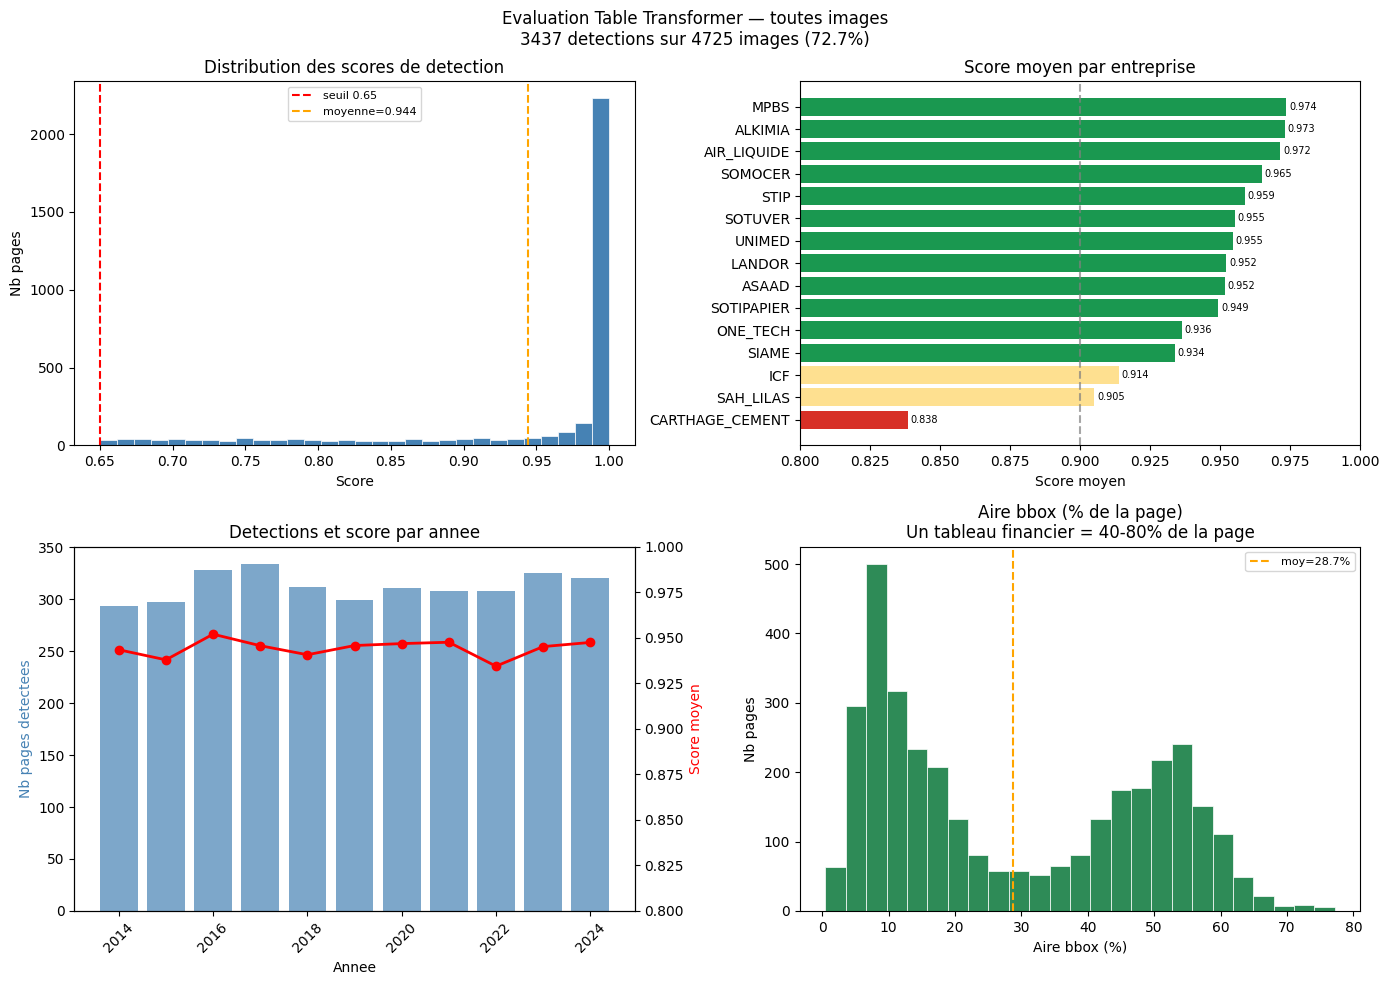

Sauvegarde : eval_tt_complete.png

ALERTES QUALITE

PDFs sans detection : 0

Bboxes trop petites (<10% page) : 885
        company                  pdf_key  page   score  bbox_area_pct
7   AIR_LIQUIDE  AIR_LIQUIDE_annuel_2014    11  0.9986            6.9
8   AIR_LIQUIDE  AIR_LIQUIDE_annuel_2014    12  0.9987            7.8
10  AIR_LIQUIDE  AIR_LIQUIDE_annuel_2014    14  0.9955            7.1
11  AIR_LIQUIDE  AIR_LIQUIDE_annuel_2014    15  0.9960            7.2
18  AIR_LIQUIDE  AIR_LIQUIDE_annuel_2015    10  0.9963            8.6

Prochaine etape :
  Cellule 15 — EasyOCR sur les bboxes detectees


In [14]:
# ============================================================
# CELLULE 14 — Évaluation complète Table Transformer
# Analyse du bboxes_detected.json
# ============================================================
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os

OUTPUT_DIR = '/kaggle/working/extracted_json'
IMAGES_DIR = '/kaggle/working/images'

# ── Charger le JSON ──────────────────────────────────────────
with open(f'{OUTPUT_DIR}/bboxes_detected.json',
          encoding='utf-8') as f:
    bboxes = json.load(f)

# ── Construire un DataFrame plat ─────────────────────────────
rows = []
for company, pdfs in bboxes.items():
    for pdf_key, pages in pdfs.items():
        # Extraire année et période depuis pdf_key
        year_m  = re.search(r'(\d{4})', pdf_key)
        year    = int(year_m.group(1)) if year_m else 0
        periode = ('semestriel'
                   if 'semestriel' in pdf_key
                   else 'annuel')
        for page_num, data in pages.items():
            rows.append({
                'company'   : company,
                'pdf_key'   : pdf_key,
                'year'      : year,
                'periode'   : periode,
                'page'      : int(page_num),
                'score'     : data['best_score'],
                'seuil'     : data['seuil'],
                'bbox_w'    : data['best_bbox'][2] -
                              data['best_bbox'][0],
                'bbox_h'    : data['best_bbox'][3] -
                              data['best_bbox'][1],
                'img_w'     : data['img_size'][0],
                'img_h'     : data['img_size'][1],
            })

df = pd.DataFrame(rows)
df['bbox_area_pct'] = (
    df['bbox_w'] * df['bbox_h'] /
    (df['img_w'] * df['img_h']) * 100
).round(1)

print(f"{'='*55}")
print(f"EVALUATION TABLE TRANSFORMER — {len(df)} detections")
print(f"{'='*55}")

# ── 1. Stats globales ─────────────────────────────────────────
print(f"\n1. STATS GLOBALES")
print(f"{'─'*55}")
print(f"  Score moyen     : {df['score'].mean():.4f}")
print(f"  Score médian    : {df['score'].median():.4f}")
print(f"  Score min       : {df['score'].min():.4f}")
print(f"  Score max       : {df['score'].max():.4f}")
print(f"  Score < 0.70    : "
      f"{(df['score'] < 0.70).sum()} "
      f"({(df['score'] < 0.70).mean()*100:.1f}%)")
print(f"  Score > 0.95    : "
      f"{(df['score'] > 0.95).sum()} "
      f"({(df['score'] > 0.95).mean()*100:.1f}%)")

# ── 2. Détections par entreprise ─────────────────────────────
print(f"\n2. DETECTIONS PAR ENTREPRISE")
print(f"{'─'*55}")
by_co = df.groupby('company').agg(
    pages_detectees=('score', 'count'),
    score_moy=('score', 'mean'),
    score_min=('score', 'min'),
    bbox_area_moy=('bbox_area_pct', 'mean'),
).round(3)
print(by_co.to_string())

# ── 3. Couverture PDF par entreprise ─────────────────────────
print(f"\n3. COUVERTURE PDF (nb tableaux types par période)")
print(f"{'─'*55}")
# Compter combien de PDFs ont au moins 1 page détectée
pdf_coverage = {}
for company, pdfs in bboxes.items():
    total_pdfs = len(pdfs)
    pdfs_with_det = sum(1 for p in pdfs.values() if p)
    pdf_coverage[company] = {
        'total_pdfs'     : total_pdfs,
        'pdfs_detectes'  : pdfs_with_det,
        'taux'           : round(pdfs_with_det /
                                 max(total_pdfs, 1) * 100, 1)
    }

for co, stats in sorted(pdf_coverage.items()):
    bar = '#' * int(stats['taux'] / 5)
    print(f"  {co:<22} "
          f"{stats['pdfs_detectes']:>3}/"
          f"{stats['total_pdfs']:<3} PDFs "
          f"({stats['taux']:>5.1f}%) {bar}")

# ── 4. Distribution des scores ────────────────────────────────
print(f"\n4. DISTRIBUTION SCORES")
print(f"{'─'*55}")
bins   = [0.65, 0.70, 0.80, 0.90, 0.95, 1.01]

labels = ['0.65-0.70', '0.70-0.80',
          '0.80-0.90', '0.90-0.95', '0.95-1.00']
df['score_bin'] = pd.cut(df['score'],
                          bins=bins, labels=labels)
dist = df['score_bin'].value_counts().sort_index()
for bin_label, count in dist.items():
    bar = '#' * int(count / max(dist) * 30)
    print(f"  {bin_label} : {count:>4} {bar}")

# ── 5. Visualisation 4 graphiques ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5a. Distribution scores
ax = axes[0, 0]
ax.hist(df['score'], bins=30, color='steelblue',
        edgecolor='white', linewidth=0.5)
ax.axvline(0.65, color='red',    linestyle='--',
           label='seuil 0.65')
ax.axvline(df['score'].mean(), color='orange',
           linestyle='--',
           label=f"moyenne={df['score'].mean():.3f}")
ax.set_title("Distribution des scores de detection")
ax.set_xlabel("Score")
ax.set_ylabel("Nb pages")
ax.legend(fontsize=8)

# 5b. Score moyen par entreprise
ax = axes[0, 1]
score_by_co = df.groupby('company')['score'].mean()\
                .sort_values()
colors = ['#d73027' if s < 0.85 else
          '#fee090' if s < 0.92 else
          '#1a9850'
          for s in score_by_co.values]
bars = ax.barh(score_by_co.index, score_by_co.values,
               color=colors)
ax.axvline(0.90, color='gray', linestyle='--',
           alpha=0.7, label='seuil 0.90')
ax.set_title("Score moyen par entreprise")
ax.set_xlabel("Score moyen")
ax.set_xlim(0.8, 1.0)
for bar, val in zip(bars, score_by_co.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)

# 5c. Pages détectées par année
ax = axes[1, 0]
by_year = df.groupby('year')['score'].agg(
    ['count', 'mean']
).reset_index()
ax2_twin = ax.twinx()
ax.bar(by_year['year'], by_year['count'],
       color='steelblue', alpha=0.7, label='Nb pages')
ax2_twin.plot(by_year['year'], by_year['mean'],
              color='red', marker='o',
              linewidth=2, label='Score moy')
ax.set_title("Detections et score par annee")
ax.set_xlabel("Annee")
ax.set_ylabel("Nb pages detectees", color='steelblue')
ax2_twin.set_ylabel("Score moyen", color='red')
ax2_twin.set_ylim(0.8, 1.0)
ax.tick_params(axis='x', rotation=45)

# 5d. Aire bbox (% image) — indique si le tableau
#     couvre bien la page
ax = axes[1, 1]
ax.hist(df['bbox_area_pct'], bins=25,
        color='seagreen', edgecolor='white',
        linewidth=0.5)
ax.axvline(df['bbox_area_pct'].mean(),
           color='orange', linestyle='--',
           label=f"moy={df['bbox_area_pct'].mean():.1f}%")
ax.set_title("Aire bbox (% de la page)\n"
             "Un tableau financier = 40-80% de la page")
ax.set_xlabel("Aire bbox (%)")
ax.set_ylabel("Nb pages")
ax.legend(fontsize=8)

plt.suptitle(
    "Evaluation Table Transformer — toutes images\n"
    f"{len(df)} detections sur 4725 images (72.7%)",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/eval_tt_complete.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Sauvegarde : eval_tt_complete.png")

# ── 6. Alertes qualité ────────────────────────────────────────
print(f"\n{'='*55}")
print("ALERTES QUALITE")
print(f"{'='*55}")

# PDFs sans aucune détection
pdfs_vides = [
    (co, pdf_key)
    for co, pdfs in bboxes.items()
    for pdf_key, pages in pdfs.items()
    if not pages
]
print(f"\nPDFs sans detection : {len(pdfs_vides)}")
for co, pdf_key in pdfs_vides[:10]:
    print(f"  {co} — {pdf_key}")
if len(pdfs_vides) > 10:
    print(f"  ... et {len(pdfs_vides)-10} autres")

# Pages avec bbox très petite (< 10% de la page)
small_bbox = df[df['bbox_area_pct'] < 10]
print(f"\nBboxes trop petites (<10% page) : {len(small_bbox)}")
if len(small_bbox) > 0:
    print(small_bbox[['company','pdf_key',
                       'page','score',
                       'bbox_area_pct']].head(5).to_string())

print(f"\nProchaine etape :")
print(f"  Cellule 15 — EasyOCR sur les bboxes detectees")

In [18]:
# ============================================================
# CELLULE 15 — EasyOCR sur les bboxes détectées
# Input  : bboxes_detected.json
# Output : bilans_extracted.json
# ============================================================
import os, re, json, time
from PIL import Image

IMAGES_DIR  = '/kaggle/working/images'
OUTPUT_DIR  = '/kaggle/working/extracted_json'

MIN_PAIRS        = 3
CONF_THRESHOLD   = 0.35
BBOX_AREA_MIN    = 15.0  # ignorer petits tableaux notes

# ── Charger les bboxes ───────────────────────────────────────
with open(f'{OUTPUT_DIR}/bboxes_detected.json',
          encoding='utf-8') as f:
    bboxes = json.load(f)

# ── Fonctions OCR + extraction ───────────────────────────────
def ocr_bbox(img_path, bbox, img_size):
    """Lit le contenu d'une bbox sur une image."""
    image        = Image.open(img_path).convert("RGB")
    x1,y1,x2,y2 = bbox
    x1 = max(0, x1 - 5);  y1 = max(0, y1 - 5)
    x2 = min(img_size[0], x2 + 5)
    y2 = min(img_size[1], y2 + 5)
    cropped = image.crop((x1, y1, x2, y2))
    cw, ch  = cropped.size
    if cw > 800:
        cropped = cropped.resize((800, int(ch*800/cw)))
    tmp = '/kaggle/working/tmp_crop.png'
    cropped.save(tmp)
    result = reader_fr.readtext(tmp, batch_size=4)
    if len(result) < 5:
        result += reader_ar.readtext(tmp, batch_size=4)
    return result

def clean_number(text):
    text = str(text).replace(' ','').replace('\xa0','')
    text = text.replace(',','.').replace('(','-')\
               .replace(')','')
    try:
        val = float(re.sub(r'[^\d\.\-]', '', text))
        return val if abs(val) > 10 else None
    except:
        return None

def is_valid_label(label):
    label_lower = label.lower().strip()
    if len(label_lower) < 4:
        return False
    if label_lower[0].isdigit():
        return False
    if re.match(r'^\([A-Z]\.\d+\)', label):
        return False
    if any(p in label_lower for p in PARASITES):
        return False
    if re.match(r'^[\d\s\.\,\-\(\)]+$', label_lower):
        return False
    return True

def extract_pairs(ocr_result):
    """Extrait paires label → valeur depuis résultat OCR."""
    if not ocr_result:
        return {}
    lines = {}
    for item in ocr_result:
        bbox_item, text, conf = item
        if conf < CONF_THRESHOLD:
            continue
        y     = int((bbox_item[0][1] + bbox_item[2][1]) / 2)
        y_key = round(y / 12) * 12
        x     = int((bbox_item[0][0] + bbox_item[2][0]) / 2)
        lines.setdefault(y_key, []).append(
            {'x': x, 'text': text}
        )
    pairs = {}
    for y_key in sorted(lines.keys()):
        items = sorted(lines[y_key], key=lambda i: i['x'])
        if len(items) < 2:
            continue
        label = items[0]['text'].strip()
        if not is_valid_label(label):
            continue
        for item in items[1:]:
            num = clean_number(item['text'])
            if num is not None:
                pairs[label] = num
                break
    return pairs

# ── Extraction complète ──────────────────────────────────────
all_data     = {}
stats = {
    'images_traitees' : 0,
    'images_filtrees' : 0,  # bbox trop petite
    'ocr_vides'       : 0,  # OCR sans résultat
    'type_inconnu'    : 0,  # identify_type() = None
    'paires_insuf'    : 0,  # < MIN_PAIRS
    'tableaux_ok'     : 0,
    'erreurs'         : 0,
}

start = time.time()
print("EasyOCR — extraction sur bboxes detectees")
print(f"Filtre aire bbox  : > {BBOX_AREA_MIN}%")
print(f"Confiance OCR min : {CONF_THRESHOLD}")
print(f"Paires min        : {MIN_PAIRS}")
print("=" * 55)

for company in sorted(bboxes.keys()):
    all_data[company] = {}
    co_ok    = 0
    co_skip  = 0
    t0       = time.time()

    for pdf_key, pages in sorted(bboxes[company].items()):
        pdf_data    = {}
        found_types = set()

        for page_num, data in sorted(
            pages.items(), key=lambda x: int(x[0])
        ):
            # Stop si 4 types trouvés pour ce PDF
            if len(found_types) == 4:
                break

            stats['images_traitees'] += 1
            img_path = (f'{IMAGES_DIR}/{company}/'
                        f'{data["img_name"]}')
            img_size = tuple(data['img_size'])
            bbox     = data['best_bbox']

            # Filtre aire bbox
            bbox_area = (
                (bbox[2]-bbox[0]) * (bbox[3]-bbox[1]) /
                (img_size[0] * img_size[1]) * 100
            )
            if bbox_area < BBOX_AREA_MIN:
                stats['images_filtrees'] += 1
                co_skip += 1
                continue

            try:
                # OCR dans la bbox
                ocr_result = ocr_bbox(img_path, bbox,
                                      img_size)
                if not ocr_result:
                    stats['ocr_vides'] += 1
                    continue

                # Identifier le type de tableau
                full_text  = ' '.join(
                    [r[1] for r in ocr_result]
                )
                table_type = identify_type(full_text)
                if not table_type:
                    stats['type_inconnu'] += 1
                    continue

                # Skip si type déjà trouvé pour ce PDF
                if table_type in found_types:
                    continue

                # Extraire paires label → valeur
                pairs = extract_pairs(ocr_result)
                if len(pairs) < MIN_PAIRS:
                    stats['paires_insuf'] += 1
                    continue

                pdf_data[table_type] = pairs
                found_types.add(table_type)
                stats['tableaux_ok'] += 1
                co_ok += 1

            except Exception as e:
                stats['erreurs'] += 1

        # Sauvegarder ce PDF dans all_data
        if pdf_data:
            year_m  = re.search(r'(\d{4})', pdf_key)
            year    = year_m.group(1) if year_m else 'unknown'
            periode = ('semestriel'
                       if 'semestriel' in pdf_key
                       else 'annuel')
            key     = f"{year}_{periode}"
            all_data[company].setdefault(key, {})\
                             .update(pdf_data)

    elapsed = time.time() - t0
    print(f"{company:<22} ok={co_ok:>3} "
          f"skip={co_skip:>3} ({elapsed:.0f}s)")

    # Sauvegarde intermédiaire
    with open(f'{OUTPUT_DIR}/bilans_extracted.json',
              'w', encoding='utf-8') as f:
        json.dump(all_data, f,
                  ensure_ascii=False, indent=2)

# ── Résumé ───────────────────────────────────────────────────
elapsed_total = time.time() - start
print(f"\n{'='*55}")
print(f"RESUME EASYOCR")
print(f"{'='*55}")
print(f"Images traitées   : {stats['images_traitees']}")
print(f"Filtrees (bbox<{BBOX_AREA_MIN}%): {stats['images_filtrees']}")
print(f"OCR vides         : {stats['ocr_vides']}")
print(f"Type inconnu      : {stats['type_inconnu']}")
print(f"Paires insuf.     : {stats['paires_insuf']}")
print(f"Tableaux extraits : {stats['tableaux_ok']}")
print(f"Erreurs           : {stats['erreurs']}")
print(f"Temps total       : {elapsed_total/60:.1f} min")
print(f"\nJSON : bilans_extracted.json")

# ── Aperçu ───────────────────────────────────────────────────
print(f"\nAPERCU :")
for company, years in list(all_data.items())[:2]:
    print(f"\n{company}:")
    for year_key, tables in list(years.items())[:2]:
        print(f"  {year_key}:")
        for ttype, vals in tables.items():
            print(f"    {ttype}: {len(vals)} postes")
            for k, v in list(vals.items())[:3]:
                print(f"      {k}: {v:,.0f}")

EasyOCR — extraction sur bboxes detectees
Filtre aire bbox  : > 15.0%
Confiance OCR min : 0.35
Paires min        : 3
AIR_LIQUIDE            ok= 78 skip= 59 (125s)
ALKIMIA                ok= 75 skip= 36 (104s)
ASAAD                  ok= 74 skip= 25 (124s)
CARTHAGE_CEMENT        ok= 36 skip=107 (73s)
ICF                    ok= 58 skip= 49 (128s)
LANDOR                 ok= 85 skip=  6 (122s)
MPBS                   ok= 73 skip= 65 (168s)
ONE_TECH               ok= 68 skip= 49 (141s)
SAH_LILAS              ok= 75 skip= 24 (127s)
SIAME                  ok= 47 skip=102 (90s)
SOMOCER                ok= 78 skip= 23 (110s)
SOTIPAPIER             ok= 77 skip= 52 (110s)
SOTUVER                ok= 77 skip= 62 (119s)
STIP                   ok= 58 skip= 71 (151s)
UNIMED                 ok= 69 skip=  9 (97s)

RESUME EASYOCR
Images traitées   : 2385
Filtrees (bbox<15.0%): 739
OCR vides         : 12
Type inconnu      : 289
Paires insuf.     : 11
Tableaux extraits : 1028
Erreurs           : 0
Temps total

In [16]:
# ============================================================
# DIAGNOSTIC — pourquoi identify_type() retourne None
# ============================================================
import json
from PIL import Image

IMAGES_DIR = '/kaggle/working/images'
OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bboxes_detected.json',
          encoding='utf-8') as f:
    bboxes = json.load(f)

# Prendre 1 seule image AIR_LIQUIDE avec bbox_area > 15%
company = 'AIR_LIQUIDE'

for pdf_key, pages in sorted(bboxes[company].items()):
    for page_num, data in sorted(pages.items(),
                                  key=lambda x: int(x[0])):
        bbox     = data['best_bbox']
        img_size = tuple(data['img_size'])
        bbox_area = (
            (bbox[2]-bbox[0]) * (bbox[3]-bbox[1]) /
            (img_size[0] * img_size[1]) * 100
        )
        if bbox_area < 15:
            continue

        img_path = (f'{IMAGES_DIR}/{company}/'
                    f'{data["img_name"]}')
        print(f"Image    : {data['img_name']}")
        print(f"bbox     : {bbox}")
        print(f"img_size : {img_size}")
        print(f"bbox_area: {bbox_area:.1f}%")

        # OCR brut
        ocr_result = ocr_bbox(img_path, bbox, img_size)
        print(f"\nLignes OCR : {len(ocr_result)}")
        print("\nTEXTE BRUT (20 premières lignes) :")
        for item in ocr_result[:20]:
            _, text, conf = item
            print(f"  {conf:.2f} | '{text}'")

        # Texte complet
        full_text = ' '.join([r[1] for r in ocr_result])
        print(f"\nTEXTE COMPLET (300 chars) :")
        print(f"  {full_text[:300]}")

        # identify_type
        table_type = identify_type(full_text)
        print(f"\nidentify_type() → {table_type}")

        # Keywords manuels
        print("\nKEYWORDS MATCHES :")
        text_lower = full_text.lower()
        for ttype, kws in KEYWORDS.items():
            matches = [kw for kw in kws
                       if kw in text_lower]
            print(f"  {ttype:<12} : "
                  f"{matches if matches else 'AUCUN'}")

        # Paires
        pairs = extract_pairs(ocr_result)
        print(f"\nPaires extraites : {len(pairs)}")
        for k, v in list(pairs.items())[:5]:
            print(f"  '{k}' → {v:,.0f}")

        # Tester sur 1 seule image puis stop
        break
    break

Image    : AIR_LIQUIDE_annuel_2014_p002.png
bbox     : [140, 365, 1053, 1440]
img_size : (1191, 1684)
bbox_area: 48.9%

Lignes OCR : 76

TEXTE BRUT (20 premières lignes) :
  1.00 | 'Notes'
  0.59 | '2014'
  0.68 | '2013'
  0.75 | 'Actifs non courants'
  0.96 | 'Actifs immobilisés'
  0.80 | 'Immobilisations incorporelles'
  0.82 | '2 017 638'
  0.97 | '2 101 938'
  1.00 | '689 332'
  1.00 | '367 482'
  0.92 | 'Moins: amortissements'
  0.97 | '412 606'
  0.76 | '650 156'
  0.99 | '103 283 698'
  1.00 | '101 689 580'
  0.74 | 'Immobilisations corporelles'
  0.87 | '64 355 914'
  0.84 | 'Moins: amortissements'
  0.97 | '69 044 406'
  1.00 | '34 239 292'

TEXTE COMPLET (300 chars) :
  Notes 2014 2013 Actifs non courants Actifs immobilisés Immobilisations incorporelles 2 017 638 2 101 938 689 332 367 482 Moins: amortissements 412 606 650 156 103 283 698 101 689 580 Immobilisations corporelles 64 355 914 Moins: amortissements 69 044 406 34 239 292 37 333 666 Immobilisations financi


NameError: name 'identify_type' is not defined

In [17]:
# ============================================================
# DIAGNOSTIC SUITE — redéfinir fonctions + tester
# ============================================================

# ── Redéfinir identify_type ──────────────────────────────────
def identify_type(text):
    text_lower = text.lower()
    scores = {}
    for t, kws in KEYWORDS.items():
        score = sum(1 for kw in kws if kw in text_lower)
        if score > 0:
            scores[t] = score
    return max(scores, key=scores.get) if scores else None

# ── Tester sur le texte OCR qu'on vient de récupérer ────────
full_text = "Notes 2014 2013 Actifs non courants Actifs immobilisés Immobilisations incorporelles 2 017 638 2 101 938 689 332 367 482 Moins: amortissements 412 606 650 156 103 283 698 101 689 580 Immobilisations corporelles 64 355 914 Moins: amortissements 69 044 406 34 239 292 37 333 666 Immobilisations financi"

text_lower = full_text.lower()

print("KEYWORDS MATCHES :")
for ttype, kws in KEYWORDS.items():
    matches = [kw for kw in kws if kw in text_lower]
    print(f"  {ttype:<12} : "
          f"{matches if matches else 'AUCUN'}")

print(f"\nidentify_type() → {identify_type(full_text)}")

KEYWORDS MATCHES :
  actif        : ['actifs non courants', 'actifs immobilisés', 'immobilisations incorporelles', 'immobilisations corporelles']
  passif       : AUCUN
  resultats    : AUCUN
  flux         : AUCUN

identify_type() → actif


ÉVALUATION EXTRACTION — 1028 tableaux

1. TABLEAUX PAR TYPE
───────────────────────────────────────────────────────
           count  postes_moy  postes_min  postes_max
type                                                
actif        293        15.1           3          22
flux         195        16.1           4          26
passif       280        13.7           3          28
resultats    260        15.2           7          22

2. COUVERTURE PAR ENTREPRISE
───────────────────────────────────────────────────────
                 total_periodes  periodes_ok  types_moy  taux_complet
company                                                              
AIR_LIQUIDE                  22           12       3.55          54.5
ALKIMIA                      20           15       3.75          75.0
ASAAD                        20           15       3.70          75.0
CARTHAGE_CEMENT              17            0       2.12           0.0
ICF                          20            2       2.90     

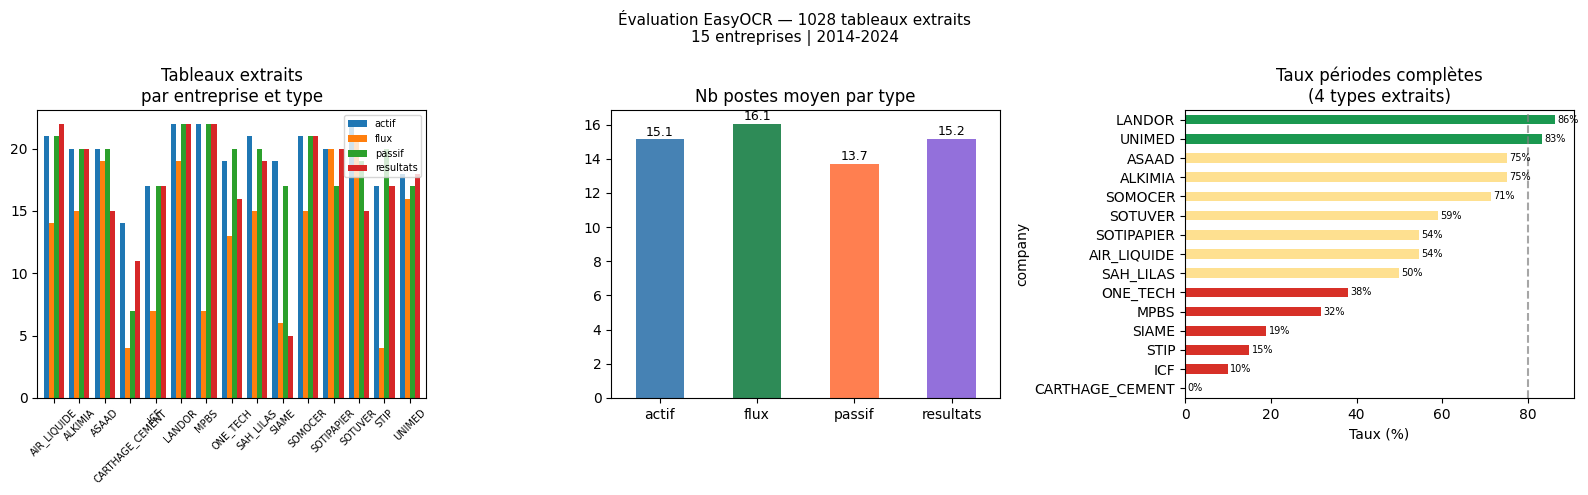


Sauvegarde : eval_easyocr.png



In [20]:
# ============================================================
# CELLULE 16 — Évaluation qualité extraction EasyOCR
# ============================================================
import json
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bilans_extracted.json',
          encoding='utf-8') as f:
    all_data = json.load(f)

# ── Construire DataFrame plat ────────────────────────────────
rows = []
for company, years in all_data.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]
        types_found = list(tables.keys())
        for ttype, pairs in tables.items():
            rows.append({
                'company'    : company,
                'year'       : year,
                'periode'    : periode,
                'year_key'   : year_key,
                'type'       : ttype,
                'nb_postes'  : len(pairs),
            })

df = pd.DataFrame(rows)

print(f"{'='*55}")
print(f"ÉVALUATION EXTRACTION — {len(df)} tableaux")
print(f"{'='*55}")

# ── 1. Vue globale ───────────────────────────────────────────
print(f"\n1. TABLEAUX PAR TYPE")
print(f"{'─'*55}")
by_type = df.groupby('type').agg(
    count=('nb_postes', 'count'),
    postes_moy=('nb_postes', 'mean'),
    postes_min=('nb_postes', 'min'),
    postes_max=('nb_postes', 'max'),
).round(1)
print(by_type.to_string())

# ── 2. Couverture par entreprise ─────────────────────────────
print(f"\n2. COUVERTURE PAR ENTREPRISE")
print(f"{'─'*55}")
# Compter les 4 types par période
coverage = df.groupby(
    ['company','year_key']
)['type'].apply(list).reset_index()
coverage['nb_types'] = coverage['type'].apply(len)
coverage['complet']  = coverage['nb_types'] == 4

summary = coverage.groupby('company').agg(
    total_periodes=('year_key',   'count'),
    periodes_ok   =('complet',    'sum'),
    types_moy     =('nb_types',   'mean'),
).round(2)
summary['taux_complet'] = (
    summary['periodes_ok'] /
    summary['total_periodes'] * 100
).round(1)
print(summary.to_string())

# ── 3. Problèmes qualité ─────────────────────────────────────
print(f"\n3. PROBLÈMES QUALITÉ")
print(f"{'─'*55}")

# Postes avec valeur = année (2014, 2015... 2024)
annees_probleme = []
for company, years in all_data.items():
    for year_key, tables in years.items():
        for ttype, pairs in tables.items():
            for label, val in pairs.items():
                if 2010 <= val <= 2025:
                    annees_probleme.append({
                        'company'  : company,
                        'year_key' : year_key,
                        'type'     : ttype,
                        'label'    : label,
                        'val'      : val,
                    })

print(f"\nValeurs = année (2010-2025) : "
      f"{len(annees_probleme)} cas")
if annees_probleme:
    df_ap = pd.DataFrame(annees_probleme)
    print(df_ap.groupby('label')['val']\
               .count().sort_values(ascending=False)\
               .head(10).to_string())

# Postes parasites encore présents
parasites_trouves = []
for company, years in all_data.items():
    for year_key, tables in years.items():
        for ttype, pairs in tables.items():
            for label in pairs.keys():
                label_low = label.lower()
                for p in PARASITES:
                    if p in label_low:
                        parasites_trouves.append({
                            'label': label,
                            'parasite': p
                        })

print(f"\nLabels parasites encore présents : "
      f"{len(parasites_trouves)}")
if parasites_trouves:
    df_par = pd.DataFrame(parasites_trouves)
    print(df_par.groupby('parasite')['label']\
               .count().sort_values(ascending=False)\
               .head(10).to_string())

# ── 4. Séries temporelles disponibles ────────────────────────
print(f"\n4. SÉRIES TEMPORELLES PAR ENTREPRISE")
print(f"{'─'*55}")
for company in sorted(all_data.keys()):
    years_data = all_data[company]
    annuels    = sorted([k for k in years_data
                         if 'annuel' in k])
    semestriels= sorted([k for k in years_data
                         if 'semestriel' in k])
    print(f"\n  {company}:")
    print(f"    Annuels     ({len(annuels):>2}) : "
          f"{[k.split('_')[0] for k in annuels]}")
    print(f"    Semestriels ({len(semestriels):>2}) : "
          f"{[k.split('_')[0] for k in semestriels]}")

# ── 5. Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 5a. Tableaux extraits par entreprise et type
ax = axes[0]
pivot = df.groupby(['company','type'])\
          .size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=ax, width=0.8)
ax.set_title("Tableaux extraits\npar entreprise et type")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.legend(fontsize=7)

# 5b. Nb postes moyen par type
ax = axes[1]
postes = df.groupby('type')['nb_postes'].mean()
colors = ['steelblue','seagreen','coral','mediumpurple']
postes.plot(kind='bar', ax=ax, color=colors)
ax.set_title("Nb postes moyen par type")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(postes):
    ax.text(i, v+0.2, f'{v:.1f}', ha='center',
            fontsize=9)

# 5c. Taux de complétion par entreprise
ax = axes[2]
taux = summary['taux_complet'].sort_values()
colors = ['#d73027' if t < 50 else
          '#fee090' if t < 80 else
          '#1a9850' for t in taux.values]
taux.plot(kind='barh', ax=ax, color=colors)
ax.axvline(80, color='gray', linestyle='--',
           alpha=0.7)
ax.set_title("Taux périodes complètes\n(4 types extraits)")
ax.set_xlabel("Taux (%)")
for i, v in enumerate(taux):
    ax.text(v+0.5, i, f'{v:.0f}%',
            va='center', fontsize=7)

plt.suptitle(
    f"Évaluation EasyOCR — {len(df)} tableaux extraits\n"
    f"15 entreprises | 2014-2024",
    fontsize=11
)
plt.tight_layout()
plt.savefig('/kaggle/working/eval_easyocr.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\nSauvegarde : eval_easyocr.png")

print(f"\n{'='*55}")


ÉVALUATION OCR — Option B
SequenceMatcher / CER / WER vs keywords

1. STATS GLOBALES
───────────────────────────────────────────────────────
Labels totaux extraits    : 15353
Matchés keyword (>0.5)    : 12902 (84.0%)
Quasi-exacts  (>=0.9)     : 7564 (49.3%)
Sans keyword (<= 0.5)     : 2451 (16.0%)
Valeurs suspectes (année) : 148

Métriques sur labels matchés (sim > 0.5) :
  SequenceMatcher moyen : 0.871
  CER moyen             : 0.219
  WER moyen             : 0.403

Interprétation :
  Sim 0.871 → excellent
  CER 0.219 → faible
  WER 0.403 → faible

2. PAR TYPE DE TABLEAU
───────────────────────────────────────────────────────
           nb_labels  sim_moy  cer_moy  wer_moy
type                                           
actif           3525    0.919    0.132    0.227
flux            2593    0.735    0.455    0.830
passif          3261    0.911    0.163    0.249
resultats       3523    0.886    0.186    0.407

3. PAR ENTREPRISE
───────────────────────────────────────────────────────
  

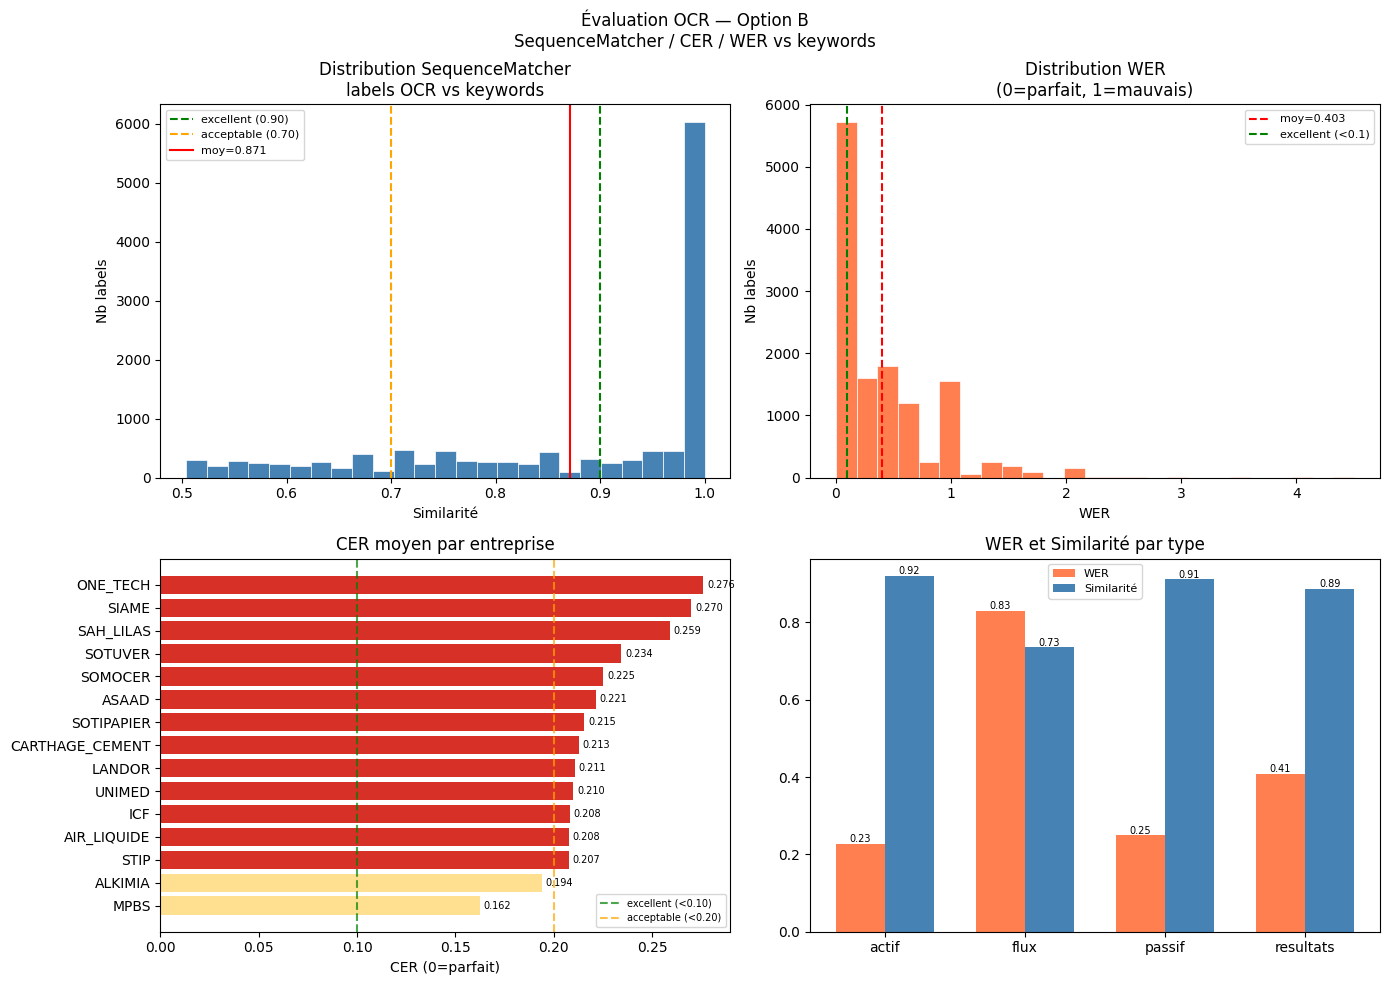


Sauvegarde : eval_ocr_optionB.png


In [21]:
# ============================================================
# CELLULE 17 — Évaluation OCR Option B
# SequenceMatcher / CER / WER vs keywords
# ============================================================
import json
from difflib import SequenceMatcher
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bilans_extracted.json',
          encoding='utf-8') as f:
    all_data = json.load(f)

# ============================================================
# FONCTIONS CER / WER / SequenceMatcher
# ============================================================
def cer(reference, hypothesis):
    ref = reference.lower().strip()
    hyp = hypothesis.lower().strip()
    if len(ref) == 0:
        return 0.0
    d = [[0]*(len(hyp)+1) for _ in range(len(ref)+1)]
    for i in range(len(ref)+1): d[i][0] = i
    for j in range(len(hyp)+1): d[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            cost = 0 if ref[i-1]==hyp[j-1] else 1
            d[i][j] = min(d[i-1][j]+1,
                         d[i][j-1]+1,
                         d[i-1][j-1]+cost)
    return d[len(ref)][len(hyp)] / len(ref)

def wer(reference, hypothesis):
    ref = reference.lower().strip().split()
    hyp = hypothesis.lower().strip().split()
    if len(ref) == 0:
        return 0.0
    d = [[0]*(len(hyp)+1) for _ in range(len(ref)+1)]
    for i in range(len(ref)+1): d[i][0] = i
    for j in range(len(hyp)+1): d[0][j] = j
    for i in range(1, len(ref)+1):
        for j in range(1, len(hyp)+1):
            cost = 0 if ref[i-1]==hyp[j-1] else 1
            d[i][j] = min(d[i-1][j]+1,
                         d[i][j-1]+1,
                         d[i-1][j-1]+cost)
    return d[len(ref)][len(hyp)] / len(ref)

def seq_similarity(a, b):
    return SequenceMatcher(
        None,
        a.lower().strip(),
        b.lower().strip()
    ).ratio()

def best_keyword_match(label, keywords_flat):
    best_kw  = None
    best_sim = 0.0
    for kw in keywords_flat:
        sim = seq_similarity(label, kw)
        if sim > best_sim:
            best_sim = sim
            best_kw  = kw
    return best_kw, best_sim

# Liste plate tous les keywords
keywords_flat = [
    kw for kws in KEYWORDS.values()
    for kw in kws
]

# ============================================================
# CALCUL MÉTRIQUES SUR TOUS LES LABELS EXTRAITS
# ============================================================
print("="*55)
print("ÉVALUATION OCR — Option B")
print("SequenceMatcher / CER / WER vs keywords")
print("="*55)

eval_rows = []
for company, years in all_data.items():
    for year_key, tables in years.items():
        year    = year_key.split('_')[0]
        periode = year_key.split('_')[1]
        for ttype, pairs in tables.items():
            for label, val in pairs.items():
                best_kw, sim = best_keyword_match(
                    label, keywords_flat
                )
                if best_kw and sim > 0.5:
                    c = cer(best_kw, label)
                    w = wer(best_kw, label)
                else:
                    c = None
                    w = None

                eval_rows.append({
                    'company'     : company,
                    'year'        : year,
                    'periode'     : periode,
                    'type'        : ttype,
                    'label_ocr'   : label,
                    'best_kw'     : best_kw,
                    'similarity'  : round(sim, 3),
                    'cer'         : round(c, 3)
                                    if c is not None else None,
                    'wer'         : round(w, 3)
                                    if w is not None else None,
                    'valeur'      : val,
                    'val_suspecte': 2010 <= val <= 2025,
                })

df_eval  = pd.DataFrame(eval_rows)
df_match = df_eval[df_eval['similarity'] > 0.5].copy()
df_exact = df_eval[df_eval['similarity'] >= 0.9].copy()
df_no_kw = df_eval[df_eval['similarity'] <= 0.5].copy()

# ── 1. Stats globales ─────────────────────────────────────────
print(f"\n1. STATS GLOBALES")
print(f"{'─'*55}")
print(f"Labels totaux extraits    : {len(df_eval)}")
print(f"Matchés keyword (>0.5)    : {len(df_match)} "
      f"({len(df_match)/len(df_eval)*100:.1f}%)")
print(f"Quasi-exacts  (>=0.9)     : {len(df_exact)} "
      f"({len(df_exact)/len(df_eval)*100:.1f}%)")
print(f"Sans keyword (<= 0.5)     : {len(df_no_kw)} "
      f"({len(df_no_kw)/len(df_eval)*100:.1f}%)")
print(f"Valeurs suspectes (année) : "
      f"{df_eval['val_suspecte'].sum()}")

print(f"\nMétriques sur labels matchés (sim > 0.5) :")
print(f"  SequenceMatcher moyen : "
      f"{df_match['similarity'].mean():.3f}")
print(f"  CER moyen             : "
      f"{df_match['cer'].mean():.3f}")
print(f"  WER moyen             : "
      f"{df_match['wer'].mean():.3f}")

# Interprétation
sim_moy = df_match['similarity'].mean()
cer_moy = df_match['cer'].mean()
wer_moy = df_match['wer'].mean()
print(f"\nInterprétation :")
print(f"  Sim {sim_moy:.3f} → "
      f"{'excellent' if sim_moy>0.85 else 'acceptable' if sim_moy>0.7 else 'faible'}")
print(f"  CER {cer_moy:.3f} → "
      f"{'excellent' if cer_moy<0.1 else 'acceptable' if cer_moy<0.2 else 'faible'}")
print(f"  WER {wer_moy:.3f} → "
      f"{'excellent' if wer_moy<0.1 else 'acceptable' if wer_moy<0.3 else 'faible'}")

# ── 2. Par type de tableau ────────────────────────────────────
print(f"\n2. PAR TYPE DE TABLEAU")
print(f"{'─'*55}")
by_type = df_match.groupby('type').agg(
    nb_labels  =('label_ocr',  'count'),
    sim_moy    =('similarity', 'mean'),
    cer_moy    =('cer',        'mean'),
    wer_moy    =('wer',        'mean'),
).round(3)
print(by_type.to_string())

# ── 3. Par entreprise ─────────────────────────────────────────
print(f"\n3. PAR ENTREPRISE")
print(f"{'─'*55}")
by_co = df_match.groupby('company').agg(
    nb_labels  =('label_ocr',  'count'),
    sim_moy    =('similarity', 'mean'),
    cer_moy    =('cer',        'mean'),
    wer_moy    =('wer',        'mean'),
).round(3).sort_values('sim_moy', ascending=False)
print(by_co.to_string())

# ── 4. Exemples bons et mauvais ───────────────────────────────
print(f"\n4. MEILLEURS LABELS OCR (sim >= 0.95)")
print(f"{'─'*55}")
best = df_match[df_match['similarity'] >= 0.95]\
    [['company','label_ocr','best_kw',
      'similarity','cer','wer']]\
    .head(10)
print(best.to_string())

print(f"\n5. PIRES LABELS OCR (0.5 < sim < 0.7)")
print(f"{'─'*55}")
worst = df_match[df_match['similarity'] < 0.7]\
    .sort_values('similarity')\
    [['company','label_ocr','best_kw',
      'similarity','cer','wer']]\
    .head(10)
print(worst.to_string())

print(f"\n6. LABELS SANS KEYWORD PROCHE (sim <= 0.5)")
print(f"{'─'*55}")
print(f"  → Ce sont des postes hors keywords")
print(f"  → Ils sont quand même dans le JSON")
print(df_no_kw[['company','type',
                'label_ocr','valeur']]\
    .head(10).to_string())

# ── 5. Visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5a. Distribution SequenceMatcher
ax = axes[0, 0]
ax.hist(df_match['similarity'], bins=25,
        color='steelblue', edgecolor='white',
        linewidth=0.5)
ax.axvline(0.90, color='green', linestyle='--',
           linewidth=1.5, label='excellent (0.90)')
ax.axvline(0.70, color='orange', linestyle='--',
           linewidth=1.5, label='acceptable (0.70)')
ax.axvline(df_match['similarity'].mean(),
           color='red', linestyle='-',
           linewidth=1.5,
           label=f"moy={df_match['similarity'].mean():.3f}")
ax.set_title("Distribution SequenceMatcher\n"
             "labels OCR vs keywords")
ax.set_xlabel("Similarité")
ax.set_ylabel("Nb labels")
ax.legend(fontsize=8)

# 5b. Distribution WER
ax = axes[0, 1]
ax.hist(df_match['wer'].dropna(), bins=25,
        color='coral', edgecolor='white',
        linewidth=0.5)
ax.axvline(df_match['wer'].mean(), color='red',
           linestyle='--',
           label=f"moy={df_match['wer'].mean():.3f}")
ax.axvline(0.1, color='green', linestyle='--',
           label='excellent (<0.1)')
ax.set_title("Distribution WER\n"
             "(0=parfait, 1=mauvais)")
ax.set_xlabel("WER")
ax.set_ylabel("Nb labels")
ax.legend(fontsize=8)

# 5c. CER par entreprise
ax = axes[1, 0]
cer_co = df_match.groupby('company')['cer']\
                 .mean().sort_values()
colors = ['#1a9850' if v < 0.10 else
          '#fee090' if v < 0.20 else
          '#d73027' for v in cer_co.values]
bars = ax.barh(cer_co.index, cer_co.values,
               color=colors)
ax.axvline(0.10, color='green', linestyle='--',
           alpha=0.7, label='excellent (<0.10)')
ax.axvline(0.20, color='orange', linestyle='--',
           alpha=0.7, label='acceptable (<0.20)')
ax.set_title("CER moyen par entreprise")
ax.set_xlabel("CER (0=parfait)")
ax.legend(fontsize=7)
for bar, val in zip(bars, cer_co.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=7)

# 5d. WER par type
ax = axes[1, 1]
wer_type = df_match.groupby('type')['wer'].mean()
sim_type = df_match.groupby('type')['similarity'].mean()
x        = range(len(wer_type))
width    = 0.35
ax.bar([i-width/2 for i in x], wer_type.values,
       width, label='WER', color='coral')
ax.bar([i+width/2 for i in x], sim_type.values,
       width, label='Similarité', color='steelblue')
ax.set_xticks(list(x))
ax.set_xticklabels(wer_type.index)
ax.set_title("WER et Similarité par type")
ax.legend(fontsize=8)
for i, (w, s) in enumerate(zip(wer_type.values,
                                sim_type.values)):
    ax.text(i-width/2, w+0.005, f'{w:.2f}',
            ha='center', fontsize=7)
    ax.text(i+width/2, s+0.005, f'{s:.2f}',
            ha='center', fontsize=7)

plt.suptitle(
    "Évaluation OCR — Option B\n"
    "SequenceMatcher / CER / WER vs keywords",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/eval_ocr_optionB.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("\nSauvegarde : eval_ocr_optionB.png")


In [22]:
# ============================================================
# CELLULE 18 — Nettoyage bilans_extracted.json
# ============================================================
import json

OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bilans_extracted.json',
          encoding='utf-8') as f:
    data = json.load(f)

# ── Parasites labels à supprimer ─────────────────────────────
PARASITES_LABELS = [
    'moins', 'moins:', 'moins :', 'moins:',
    'amortissements des', 'provisions sur',
    'provisions pour dépréciation',
    'total des', 'sous-total',
]

def is_parasite_label(label):
    label_low = label.lower().strip()
    # Label trop court
    if len(label_low) < 4:
        return True
    # Commence par un chiffre
    if label_low[0].isdigit():
        return True
    # Contient un parasite
    for p in PARASITES_LABELS:
        if label_low.startswith(p):
            return True
    # Référence de note (B.1), (R.3)...
    if label_low.startswith('(') and \
       len(label_low) < 8:
        return True
    return False

def is_suspicious_value(val):
    # Valeur = année
    if 2010 <= val <= 2025:
        return True
    # Valeur = numéro de note ou colonne
    # (-30 à 30 : numéros de notes OCR)
    if -30 <= val <= 30:
        return True
    return False

def standardize_label(label):
    """Minuscules + strip + espaces multiples"""
    return ' '.join(label.lower().strip().split())

# ── Nettoyage ────────────────────────────────────────────────
data_clean = {}
stats = {
    'labels_avant'    : 0,
    'labels_apres'    : 0,
    'suppr_annee'     : 0,
    'suppr_note'      : 0,
    'suppr_parasite'  : 0,
    'suppr_doublon'   : 0,
    'standardises'    : 0,
}

for company, years in data.items():
    data_clean[company] = {}
    for year_key, tables in years.items():
        data_clean[company][year_key] = {}
        for ttype, pairs in tables.items():
            pairs_clean = {}
            seen_labels = set()  # pour doublons

            for label, val in pairs.items():
                stats['labels_avant'] += 1

                # 1. Supprimer valeurs suspectes
                if 2010 <= val <= 2025:
                    stats['suppr_annee'] += 1
                    continue
                if -30 <= val <= 30:
                    stats['suppr_note'] += 1
                    continue

                # 2. Supprimer labels parasites
                if is_parasite_label(label):
                    stats['suppr_parasite'] += 1
                    continue

                # 3. Standardiser le label
                label_std = standardize_label(label)

                # 4. Supprimer doublons
                if label_std in seen_labels:
                    stats['suppr_doublon'] += 1
                    continue

                if label_std != label.lower().strip():
                    stats['standardises'] += 1

                seen_labels.add(label_std)
                pairs_clean[label_std] = val
                stats['labels_apres'] += 1

            if pairs_clean:
                data_clean[company][year_key][ttype] = \
                    pairs_clean

# ── Résumé nettoyage ─────────────────────────────────────────
print(f"{'='*55}")
print(f"RÉSUMÉ NETTOYAGE")
print(f"{'='*55}")
print(f"Labels avant      : {stats['labels_avant']}")
print(f"Supprimés année   : {stats['suppr_annee']}")
print(f"Supprimés note    : {stats['suppr_note']}")
print(f"Supprimés parasite: {stats['suppr_parasite']}")
print(f"Supprimés doublon : {stats['suppr_doublon']}")
print(f"Standardisés      : {stats['standardises']}")
print(f"Labels après      : {stats['labels_apres']}")
print(f"Réduction         : "
      f"{(1 - stats['labels_apres']/stats['labels_avant'])*100:.1f}%")

# ── Vérification sur AIR_LIQUIDE 2014 ────────────────────────
print(f"\nVÉRIFICATION AIR_LIQUIDE 2014_annuel :")
if ('AIR_LIQUIDE' in data_clean and
    '2014_annuel' in data_clean['AIR_LIQUIDE']):
    for ttype, pairs in \
        data_clean['AIR_LIQUIDE']['2014_annuel'].items():
        print(f"\n  {ttype} ({len(pairs)} postes):")
        for k, v in list(pairs.items())[:5]:
            print(f"    '{k}': {v:,.0f}")

# ── Sauvegarde ───────────────────────────────────────────────
with open(f'{OUTPUT_DIR}/bilans_clean.json',
          'w', encoding='utf-8') as f:
    json.dump(data_clean, f,
              ensure_ascii=False, indent=2)
print(f"\nJSON sauvegardé : bilans_clean.json")

# ── Comparaison avant/après par entreprise ───────────────────
print(f"\nCOMPARAISON AVANT/APRÈS PAR ENTREPRISE :")
print(f"{'─'*55}")
print(f"{'Entreprise':<22} {'Avant':>6} {'Après':>6} "
      f"{'Réduction':>10}")
print(f"{'─'*55}")
for company in sorted(data.keys()):
    avant = sum(
        len(pairs)
        for years in data[company].values()
        for pairs in years.values()
    )
    apres = sum(
        len(pairs)
        for years in data_clean[company].values()
        for pairs in years.values()
    ) if company in data_clean else 0
    red = (1 - apres/max(avant,1)) * 100
    print(f"{company:<22} {avant:>6} {apres:>6} "
          f"{red:>9.1f}%")

RÉSUMÉ NETTOYAGE
Labels avant      : 15353
Supprimés année   : 148
Supprimés note    : 731
Supprimés parasite: 2435
Supprimés doublon : 2
Standardisés      : 25
Labels après      : 12037
Réduction         : 21.6%

VÉRIFICATION AIR_LIQUIDE 2014_annuel :

  actif (8 postes):
    'immobilisations incorporelles': 2,101,938
    'immobilisations corporelles': 103,283,698
    'immobilisations financières': 917,961
    'stocks': 637,575
    'clients et comptes rattachés': 33,911,152

  passif (8 postes):
    'capital social': 32,805,550
    'subventions d'investissements': 586,504
    'fond social': 637
    'résultat': 46,834,850
    'emprunts': 158,058

  resultats (8 postes):
    'marge brute': 8,911,136
    'frais de distribution': 886,236
    'frais dadministration': 3,060,013
    'résultat d'exploitation': 6,139,510
    'autres gains ordinaires': 400

  flux (11 postes):
    'encaissements reçus des clients': 37,332,519
    'personnel': 27,078,473
    'intérêts payés': -543,108
    'flux 

DataFrame plat : 12037 lignes
Entreprises    : 15
Années         : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Types          : ['actif' 'passif' 'resultats' 'flux']

POSTES LES PLUS FRÉQUENTS PAR TYPE

  ACTIF — top 10 postes :
    stocks                                         218 (74.4%)
    immobilisations incorporelles                  213 (72.7%)
    autres actifs courants                         206 (70.3%)
    immobilisations corporelles                    197 (67.2%)
    clients et comptes rattachés                   196 (66.9%)
    immobilisations financières                    178 (60.8%)
    liquidités et équivalents de liquidités        176 (60.1%)
    autres actifs non courants                     119 (40.6%)
    placements et autres actifs financiers         108 (36.9%)

  PASSIF — top 10 postes :
    capital social                         

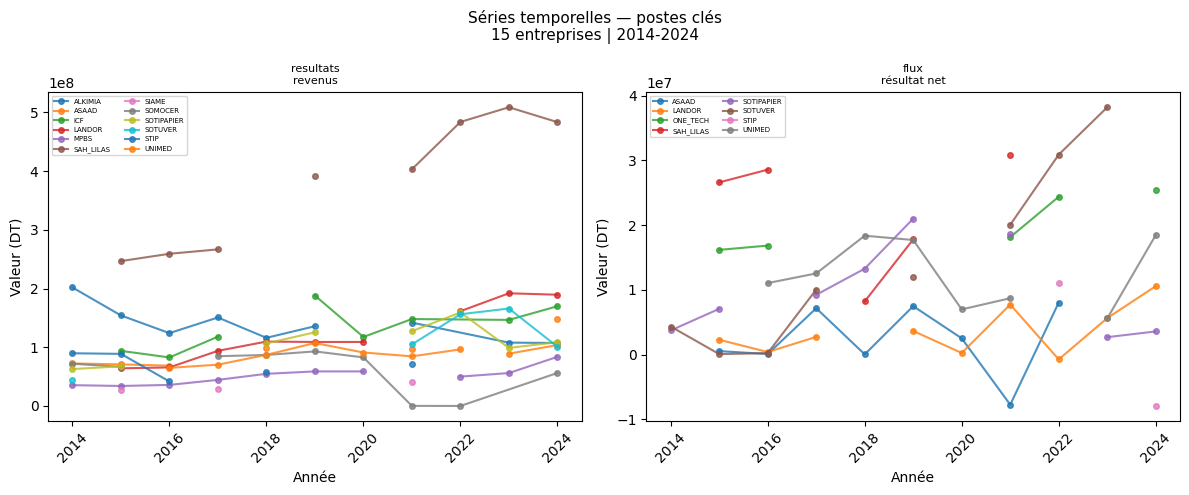

Sauvegarde : series_temporelles.png

CSV sauvegardés :
  series_annuelles.csv  → LSTM principal
  series_completes.csv  → annuel + semestriel

Prochaine étape :
  Cellule 22 — Normalisation + préparation LSTM


In [23]:
# ============================================================
# CELLULE 21 — Préparation séries temporelles pour LSTM
# Input  : bilans_clean.json
# Output : series_temporelles.csv + stats
# ============================================================
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bilans_clean.json',
          encoding='utf-8') as f:
    data = json.load(f)

# ============================================================
# ÉTAPE 1 — Aplatir le JSON en DataFrame
# ============================================================
rows = []
for company, years in data.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]  # annuel/semestriel
        for ttype, pairs in tables.items():
            for label, val in pairs.items():
                rows.append({
                    'company' : company,
                    'year'    : year,
                    'periode' : periode,
                    'type'    : ttype,
                    'label'   : label,
                    'valeur'  : val,
                })

df = pd.DataFrame(rows)
print(f"DataFrame plat : {len(df)} lignes")
print(f"Entreprises    : {df['company'].nunique()}")
print(f"Années         : {sorted(df['year'].unique())}")
print(f"Types          : {df['type'].unique()}")

# ============================================================
# ÉTAPE 2 — Sélectionner les postes clés pour le LSTM
# On garde les postes présents dans > 70% des périodes
# pour avoir des séries suffisamment complètes
# ============================================================

# Postes clés financiers qu'on veut absolument
POSTES_CLES = {
    'actif': [
        'immobilisations corporelles',
        'stocks',
        'clients et comptes rattachés',
        'liquidités et équivalents de liquidités',
        'total des actifs',
    ],
    'passif': [
        'capital social',
        'total des capitaux propres',
        'emprunts et dettes assimilées',
        'total des passifs',
    ],
    'resultats': [
        'revenus',
        'résultat d\'exploitation',
        'résultat net de l\'exercice',
        'charges de personnel',
    ],
    'flux': [
        'résultat net',
        'flux de trésorerie',
    ],
}

# ============================================================
# ÉTAPE 3 — Construire série temporelle par entreprise
# Format : company | year | periode | poste | valeur
# ============================================================

# Trouver les labels les plus fréquents par type
print(f"\n{'='*55}")
print(f"POSTES LES PLUS FRÉQUENTS PAR TYPE")
print(f"{'='*55}")

postes_retenus = {}
for ttype in ['actif', 'passif', 'resultats', 'flux']:
    df_type = df[df['type'] == ttype]
    # Compter nb entreprises × périodes où chaque poste apparaît
    freq = df_type.groupby('label')['company']\
                  .count().sort_values(ascending=False)
    total_periodes = df_type.groupby(
        ['company','year','periode']
    ).ngroups
    # Garder postes présents dans > 30% des périodes
    seuil = total_periodes * 0.30
    postes_ok = freq[freq >= seuil].index.tolist()
    postes_retenus[ttype] = postes_ok[:10]  # top 10 max

    print(f"\n  {ttype.upper()} — top 10 postes :")
    for p in postes_retenus[ttype]:
        pct = freq[p] / total_periodes * 100
        print(f"    {p:<45} {freq[p]:>4} "
              f"({pct:.1f}%)")

# ============================================================
# ÉTAPE 4 — Pivot : 1 ligne = 1 entreprise × 1 période
#           colonnes = postes financiers
# ============================================================
all_postes = [
    f"{ttype}_{label}"
    for ttype, postes in postes_retenus.items()
    for label in postes
]

# Construire le pivot
pivot_rows = []
for company, years in data.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]
        row = {
            'company' : company,
            'year'    : year,
            'periode' : periode,
            'year_key': year_key,
        }
        for ttype, postes in postes_retenus.items():
            if ttype not in tables:
                for poste in postes:
                    row[f"{ttype}_{poste}"] = np.nan
                continue
            pairs = tables[ttype]
            for poste in postes:
                # Chercher le poste (exact ou similaire)
                val = pairs.get(poste, None)
                if val is None:
                    # Chercher approximatif
                    for k, v in pairs.items():
                        if poste in k or k in poste:
                            val = v
                            break
                row[f"{ttype}_{poste}"] = val
        pivot_rows.append(row)

df_pivot = pd.DataFrame(pivot_rows)
df_pivot = df_pivot.sort_values(
    ['company', 'year', 'periode']
).reset_index(drop=True)

print(f"\n{'='*55}")
print(f"DATAFRAME PIVOT")
print(f"{'='*55}")
print(f"Lignes   : {len(df_pivot)} "
      f"(entreprises × périodes)")
print(f"Colonnes : {len(df_pivot.columns)} "
      f"(4 meta + {len(all_postes)} postes)")

# ============================================================
# ÉTAPE 5 — Analyse des valeurs manquantes
# ============================================================
print(f"\n{'='*55}")
print(f"VALEURS MANQUANTES PAR POSTE")
print(f"{'='*55}")
missing = df_pivot[all_postes].isnull().mean() * 100
missing_sorted = missing.sort_values(ascending=False)
print(f"\nPostes avec > 50% manquants :")
bad_postes = missing_sorted[missing_sorted > 50]
if len(bad_postes) > 0:
    for p, pct in bad_postes.items():
        print(f"  {p:<50} {pct:.1f}%")
else:
    print(f"  Aucun ✅")

print(f"\nPostes avec < 20% manquants :")
good_postes = missing_sorted[missing_sorted < 20]
print(f"  {len(good_postes)} postes fiables")
for p, pct in good_postes.items():
    print(f"  {p:<50} {pct:.1f}%")

# ============================================================
# ÉTAPE 6 — Séries temporelles annuelles uniquement
# (plus complètes que semestrielles)
# ============================================================
df_annuel = df_pivot[
    df_pivot['periode'] == 'annuel'
].copy()

print(f"\n{'='*55}")
print(f"SÉRIES ANNUELLES")
print(f"{'='*55}")
print(f"Lignes : {len(df_annuel)} "
      f"(entreprises × années)")

# Vérifier continuité par entreprise
print(f"\nContinuité par entreprise :")
for company in sorted(df_annuel['company'].unique()):
    df_co = df_annuel[
        df_annuel['company'] == company
    ].sort_values('year')
    years = df_co['year'].tolist()
    # Détecter les trous
    trous = [
        y for y in range(min(years), max(years)+1)
        if y not in years
    ]
    print(f"  {company:<22} "
          f"{min(years)}-{max(years)} "
          f"({len(years)} ans) "
          f"{'trous:'+str(trous) if trous else 'continu ✅'}")

# ============================================================
# ÉTAPE 7 — Visualisation séries temporelles
# ============================================================
# Choisir 2 postes représentatifs à visualiser
POSTES_VIZ = [
    p for p in all_postes
    if 'revenus' in p or 'résultat net' in p
    or 'total des actifs' in p
][:3]

if POSTES_VIZ:
    fig, axes = plt.subplots(
        1, len(POSTES_VIZ),
        figsize=(6*len(POSTES_VIZ), 5)
    )
    if len(POSTES_VIZ) == 1:
        axes = [axes]

    for ax, poste in zip(axes, POSTES_VIZ):
        for company in sorted(
            df_annuel['company'].unique()
        ):
            df_co = df_annuel[
                df_annuel['company'] == company
            ].sort_values('year')
            vals = df_co[poste].values
            if not np.all(np.isnan(vals)):
                ax.plot(df_co['year'], vals,
                       marker='o', linewidth=1.5,
                       markersize=4,
                       label=company, alpha=0.8)
        ax.set_title(poste.replace('_', '\n'),
                     fontsize=8)
        ax.set_xlabel("Année")
        ax.set_ylabel("Valeur (DT)")
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=5, ncol=2)

    plt.suptitle(
        "Séries temporelles — postes clés\n"
        "15 entreprises | 2014-2024",
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(
        '/kaggle/working/series_temporelles.png',
        dpi=120, bbox_inches='tight'
    )
    plt.show()
    print("Sauvegarde : series_temporelles.png")

# ============================================================
# ÉTAPE 8 — Sauvegarde CSV pour LSTM
# ============================================================
df_annuel.to_csv(
    '/kaggle/working/series_annuelles.csv',
    index=False, encoding='utf-8'
)
df_pivot.to_csv(
    '/kaggle/working/series_completes.csv',
    index=False, encoding='utf-8'
)
print(f"\nCSV sauvegardés :")
print(f"  series_annuelles.csv  → LSTM principal")
print(f"  series_completes.csv  → annuel + semestriel")
print(f"\nProchaine étape :")
print(f"  Cellule 22 — Normalisation + préparation LSTM")

Données chargées : (156, 34)
Postes : 30
Années : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

INTERPOLATION TCAM PAR ENTREPRISE
  AIR_LIQUIDE            NaN avant= 128 NaN après= 109
  ALKIMIA                NaN avant= 126 NaN après=  81
  ASAAD                  NaN avant= 113 NaN après=  45
  CARTHAGE_CEMENT        NaN avant= 220 NaN après= 193
  ICF                    NaN avant= 161 NaN après= 119
  LANDOR                 NaN avant=  71 NaN après=  35
  MPBS                   NaN avant= 128 NaN après=  92
  ONE_TECH               NaN avant= 174 NaN après= 112
  SAH_LILAS              NaN avant= 130 NaN après=  76
  SIAME                  NaN avant= 194 NaN après= 176
  SOMOCER                NaN avant=  78 NaN après=  39
  SOTIPAPIER             NaN avant= 138 NaN après=  58
  SOTUVER                NaN avant= 180 NaN après= 112
  STIP                 

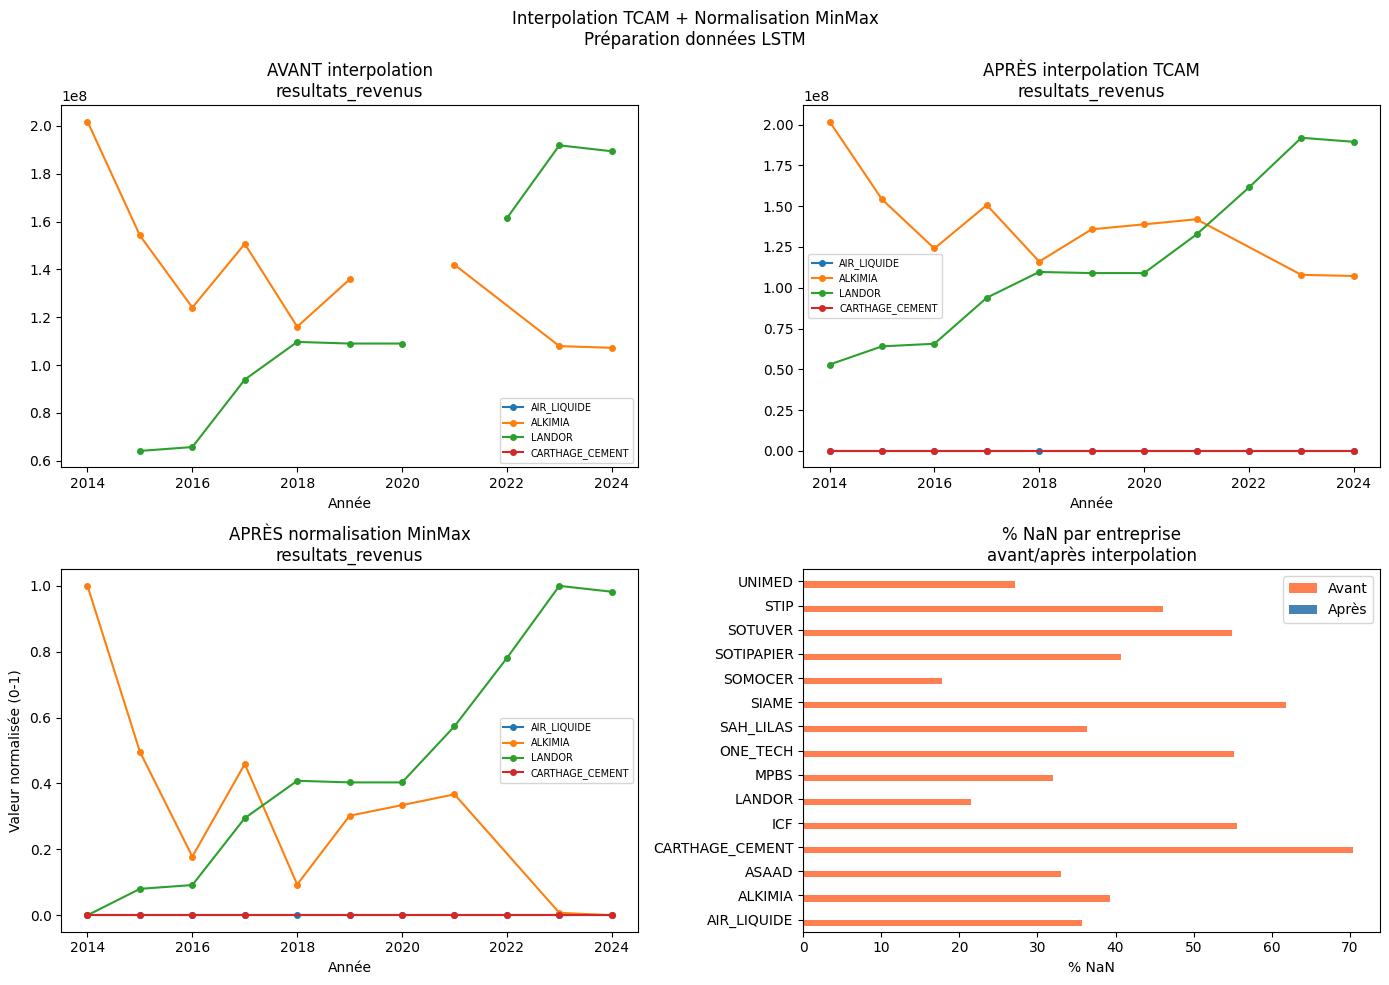

Sauvegarde : interpolation_normalisation.png

Fichiers sauvegardés :
  series_interpolees.csv  → valeurs réelles
  series_lstm_ready.csv   → normalisées 0-1
  scalers.pkl             → pour dénormaliser

Prochaine étape :
  Cellule 23 — Construction LSTM


In [24]:
# ============================================================
# CELLULE 22 — Interpolation TCAM + Normalisation MinMax
# ============================================================
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = '/kaggle/working/extracted_json'

# ── Charger les données ──────────────────────────────────────
df_annuel = pd.read_csv(
    '/kaggle/working/series_annuelles.csv'
)
print(f"Données chargées : {df_annuel.shape}")

# Colonnes postes (tout sauf métadonnées)
META_COLS  = ['company','year','periode','year_key']
POSTE_COLS = [c for c in df_annuel.columns
              if c not in META_COLS]

print(f"Postes : {len(POSTE_COLS)}")
print(f"Années : {sorted(df_annuel['year'].unique())}")

# ============================================================
# ÉTAPE 1 — Interpolation TCAM par entreprise
# ============================================================
def tcam_interpolate(series):
    """
    Interpolation par TCAM pour les trous au milieu.
    series = pd.Series avec index = années
    """
    s = series.copy().astype(float)
    idx = s.index.tolist()

    for i in range(len(idx)):
        if not np.isnan(s.iloc[i]):
            continue

        # Chercher valeur avant
        left_i  = None
        left_v  = None
        for j in range(i-1, -1, -1):
            if not np.isnan(s.iloc[j]):
                left_i = j
                left_v = s.iloc[j]
                break

        # Chercher valeur après
        right_i = None
        right_v = None
        for j in range(i+1, len(idx)):
            if not np.isnan(s.iloc[j]):
                right_i = j
                right_v = s.iloc[j]
                break

        if left_v is not None and right_v is not None:
            # Trou au milieu → TCAM
            n_steps = right_i - left_i
            if left_v > 0 and right_v > 0:
                tcam = (right_v / left_v) ** \
                       (1 / n_steps) - 1
            else:
                # Valeurs négatives → linéaire
                tcam = None

            if tcam is not None:
                steps = i - left_i
                s.iloc[i] = left_v * (1 + tcam) ** steps
            else:
                # Interpolation linéaire
                steps     = i - left_i
                total     = right_i - left_i
                s.iloc[i] = left_v + \
                    (right_v - left_v) * steps / total

    return s

def tcam_extrapole_debut(series):
    """
    Trou au DÉBUT → TCAM inversé.
    On remonte à partir des premières valeurs connues.
    """
    s = series.copy().astype(float)
    # Trouver les premières valeurs connues
    known = s.dropna()
    if len(known) < 2:
        return s

    # TCAM sur les 3 premières années connues
    known_vals = known.iloc[:3].values
    known_idx  = known.iloc[:3].index.tolist()
    n          = len(known_vals) - 1

    if known_vals[0] > 0 and known_vals[-1] > 0:
        tcam = (known_vals[-1] / known_vals[0]) ** \
               (1/n) - 1
    else:
        tcam = 0.0

    # Remplir vers l'arrière
    first_known_pos = s.index.get_loc(known.index[0])
    for i in range(first_known_pos-1, -1, -1):
        steps      = first_known_pos - i
        s.iloc[i]  = known_vals[0] / (1 + tcam) ** steps

    return s

def tcam_extrapole_fin(series):
    """
    Trou à la FIN → TCAM projeté.
    On projette à partir des dernières valeurs connues.
    """
    s = series.copy().astype(float)
    known = s.dropna()
    if len(known) < 2:
        return s

    # TCAM sur les 3 dernières années connues
    known_vals = known.iloc[-3:].values
    n          = len(known_vals) - 1

    if known_vals[0] > 0 and known_vals[-1] > 0:
        tcam = (known_vals[-1] / known_vals[0]) ** \
               (1/n) - 1
        # Limiter TCAM entre -20% et +20%
        # pour éviter extrapolations extrêmes
        tcam = np.clip(tcam, -0.20, 0.20)
    else:
        tcam = 0.0

    # Remplir vers l'avant
    last_known_pos = s.index.get_loc(known.index[-1])
    last_val       = known_vals[-1]
    for i in range(last_known_pos+1, len(s)):
        steps     = i - last_known_pos
        s.iloc[i] = last_val * (1 + tcam) ** steps

    return s

def interpolate_company(df_co):
    """
    Applique la stratégie complète d'interpolation
    pour une entreprise.
    """
    df_co = df_co.sort_values('year').copy()
    df_co = df_co.set_index('year')

    for col in POSTE_COLS:
        s = df_co[col].copy()

        # Vérifier % de NaN
        pct_nan = s.isna().mean()
        if pct_nan > 0.50:
            # Trop de trous → garder NaN
            # (sera supprimé plus tard)
            continue

        if s.isna().sum() == 0:
            continue  # Pas de NaN

        # 1. Interpolation TCAM milieu
        s = tcam_interpolate(s)

        # 2. Trou début → TCAM inversé
        if np.isnan(s.iloc[0]):
            s = tcam_extrapole_debut(s)

        # 3. Trou fin → TCAM projeté
        if np.isnan(s.iloc[-1]):
            s = tcam_extrapole_fin(s)

        df_co[col] = s

    return df_co.reset_index()

# ── Appliquer par entreprise ─────────────────────────────────
print(f"\n{'='*55}")
print(f"INTERPOLATION TCAM PAR ENTREPRISE")
print(f"{'='*55}")

dfs_interp = []
for company in sorted(df_annuel['company'].unique()):
    df_co = df_annuel[
        df_annuel['company'] == company
    ].copy()
    nan_avant = df_co[POSTE_COLS].isna().sum().sum()
    df_co     = interpolate_company(df_co)
    nan_apres = df_co[POSTE_COLS].isna().sum().sum()
    dfs_interp.append(df_co)
    print(f"  {company:<22} "
          f"NaN avant={nan_avant:>4} "
          f"NaN après={nan_apres:>4}")

df_interp = pd.concat(dfs_interp, ignore_index=True)
df_interp = df_interp.sort_values(
    ['company','year']
).reset_index(drop=True)

# ── Stats NaN globales ───────────────────────────────────────
total_nan  = df_interp[POSTE_COLS].isna().sum().sum()
total_vals = df_interp[POSTE_COLS].size
print(f"\nNaN restants : {total_nan} / {total_vals} "
      f"({total_nan/total_vals*100:.1f}%)")

# Supprimer colonnes avec trop de NaN (> 50%)
cols_to_drop = [
    c for c in POSTE_COLS
    if df_interp[c].isna().mean() > 0.50
]
if cols_to_drop:
    print(f"\nColonnes supprimées (>50% NaN) :")
    for c in cols_to_drop:
        pct = df_interp[c].isna().mean()*100
        print(f"  {c} : {pct:.1f}%")
    df_interp = df_interp.drop(columns=cols_to_drop)
    POSTE_COLS = [c for c in POSTE_COLS
                  if c not in cols_to_drop]

# Remplir NaN restants par 0
df_interp[POSTE_COLS] = \
    df_interp[POSTE_COLS].fillna(0)

print(f"Postes retenus : {len(POSTE_COLS)}")

# ============================================================
# ÉTAPE 2 — Normalisation MinMax par entreprise
# ============================================================
print(f"\n{'='*55}")
print(f"NORMALISATION MINMAX PAR ENTREPRISE")
print(f"{'='*55}")

df_norm    = df_interp.copy()
scalers    = {}  # sauvegarder pour dénormaliser après LSTM

for company in sorted(df_interp['company'].unique()):
    mask    = df_norm['company'] == company
    data_co = df_norm.loc[mask, POSTE_COLS].values

    scaler  = MinMaxScaler(feature_range=(0, 1))
    data_scaled = scaler.fit_transform(data_co)

    df_norm.loc[mask, POSTE_COLS] = data_scaled
    scalers[company] = scaler

print(f"Normalisation appliquée pour "
      f"{len(scalers)} entreprises")
print(f"\nVérification AIR_LIQUIDE :")
df_check = df_norm[
    df_norm['company'] == 'AIR_LIQUIDE'
][POSTE_COLS[:3]]
print(f"  Min : {df_check.min().values}")
print(f"  Max : {df_check.max().values}")
print(f"  → Toutes valeurs entre 0 et 1 ✅")

# ============================================================
# ÉTAPE 3 — Visualisation avant/après
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Choisir 1 poste représentatif
poste_viz = [p for p in POSTE_COLS
             if 'revenus' in p]
poste_viz = poste_viz[0] if poste_viz else POSTE_COLS[0]

companies_viz = ['AIR_LIQUIDE', 'ALKIMIA',
                 'LANDOR', 'CARTHAGE_CEMENT']

# Avant interpolation
ax = axes[0, 0]
for co in companies_viz:
    d = df_annuel[df_annuel['company']==co]\
        .sort_values('year')
    if poste_viz in d.columns:
        ax.plot(d['year'], d[poste_viz],
                marker='o', label=co,
                linewidth=1.5, markersize=4)
ax.set_title(f"AVANT interpolation\n{poste_viz}")
ax.set_xlabel("Année")
ax.legend(fontsize=7)

# Après interpolation (non normalisé)
ax = axes[0, 1]
for co in companies_viz:
    d = df_interp[df_interp['company']==co]\
        .sort_values('year')
    if poste_viz in d.columns:
        ax.plot(d['year'], d[poste_viz],
                marker='o', label=co,
                linewidth=1.5, markersize=4)
ax.set_title(f"APRÈS interpolation TCAM\n{poste_viz}")
ax.set_xlabel("Année")
ax.legend(fontsize=7)

# Après normalisation
ax = axes[1, 0]
for co in companies_viz:
    d = df_norm[df_norm['company']==co]\
        .sort_values('year')
    if poste_viz in d.columns:
        ax.plot(d['year'], d[poste_viz],
                marker='o', label=co,
                linewidth=1.5, markersize=4)
ax.set_title(f"APRÈS normalisation MinMax\n{poste_viz}")
ax.set_xlabel("Année")
ax.set_ylabel("Valeur normalisée (0-1)")
ax.legend(fontsize=7)

# Heatmap NaN avant/après
ax = axes[1, 1]
nan_by_co = pd.DataFrame({
    'Avant' : [
        df_annuel[df_annuel['company']==co]\
            [POSTE_COLS].isna().mean().mean()*100
        for co in sorted(df_annuel['company'].unique())
    ],
    'Après' : [
        df_interp[df_interp['company']==co]\
            [POSTE_COLS].isna().mean().mean()*100
        for co in sorted(df_annuel['company'].unique())
    ],
}, index=sorted(df_annuel['company'].unique()))

nan_by_co.plot(kind='barh', ax=ax,
               color=['coral','steelblue'])
ax.set_title("% NaN par entreprise\navant/après interpolation")
ax.set_xlabel("% NaN")

plt.suptitle(
    "Interpolation TCAM + Normalisation MinMax\n"
    "Préparation données LSTM",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/interpolation_normalisation.png',
            dpi=120, bbox_inches='tight')
plt.show()
print("Sauvegarde : interpolation_normalisation.png")

# ============================================================
# ÉTAPE 4 — Sauvegarde
# ============================================================
# Données interpolées non normalisées
df_interp.to_csv(
    '/kaggle/working/series_interpolees.csv',
    index=False, encoding='utf-8'
)

# Données normalisées pour LSTM
df_norm.to_csv(
    '/kaggle/working/series_lstm_ready.csv',
    index=False, encoding='utf-8'
)

# Scalers pour dénormalisation après LSTM
import pickle
with open('/kaggle/working/scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print(f"\nFichiers sauvegardés :")
print(f"  series_interpolees.csv  → valeurs réelles")
print(f"  series_lstm_ready.csv   → normalisées 0-1")
print(f"  scalers.pkl             → pour dénormaliser")
print(f"\nProchaine étape :")
print(f"  Cellule 23 — Construction LSTM")

In [25]:
# Vérification rapide
df_ready = pd.read_csv('/kaggle/working/series_lstm_ready.csv')
nan_total = df_ready.isnull().sum().sum()
print(f"NaN dans series_lstm_ready.csv : {nan_total}")
print(f"Shape : {df_ready.shape}")
print(f"Postes : {[c for c in df_ready.columns if c not in ['company','year','periode','year_key']]}")

NaN dans series_lstm_ready.csv : 0
Shape : (156, 31)
Postes : ['actif_stocks', 'actif_immobilisations incorporelles', 'actif_autres actifs courants', 'actif_immobilisations corporelles', 'actif_clients et comptes rattachés', 'actif_immobilisations financières', 'actif_liquidités et équivalents de liquidités', 'actif_autres actifs non courants', 'actif_placements et autres actifs financiers', 'passif_capital social', 'passif_résultats reportés', 'passif_fournisseurs et comptes rattachés', 'passif_autres passifs courants', 'passif_emprunts', 'passif_réserves', 'passif_autres capitaux propres', 'resultats_revenus', 'resultats_charges financières nettes', 'resultats_charges de personnel', 'resultats_autres pertes ordinaires', 'resultats_autres gains ordinaires', 'resultats_impôt sur les bénéfices', 'resultats_produits des placements', "resultats_résultat d'exploitation", 'resultats_autres produits dexploitation', "resultats_autres charges d'exploitation", 'flux_variation de trésorerie']


Shape       : (156, 31)
Features    : 27
Entreprises : 15
Targets     : 4
  → resultats_revenus
  → resultats_résultat d'exploitation
  → actif_stocks
  → flux_variation de trésorerie
Device      : cuda

Séquences : X=(66, 5, 27) Y=(66, 2, 4)
Train:39 Val:13 Test:14

LSTM : 57,608 paramètres

ENTRAÎNEMENT LSTM
Epoch  20 | Train=0.0967 | Val=0.1218 | Best=0.1218
Epoch  40 | Train=0.0552 | Val=0.1181 | Best=0.1157
Early stopping epoch 45

Meilleur val_loss : 0.1157

ÉVALUATION TEST (valeurs normalisées 0-1)
  resultats_revenus                             MAE=0.3259 RMSE=0.3579 R2=0.2810
  resultats_résultat d'exploitation             MAE=0.2926 RMSE=0.3817 R2=0.1159
  actif_stocks                                  MAE=0.3184 RMSE=0.3666 R2=-0.0090
  flux_variation de trésorerie                  MAE=0.2876 RMSE=0.3225 R2=0.1680

PRÉVISIONS 2025-2026

  AIR_LIQUIDE :
    2025 :
      resultats_revenus                             :               0 DT
      resultats_résultat d'exploitation  

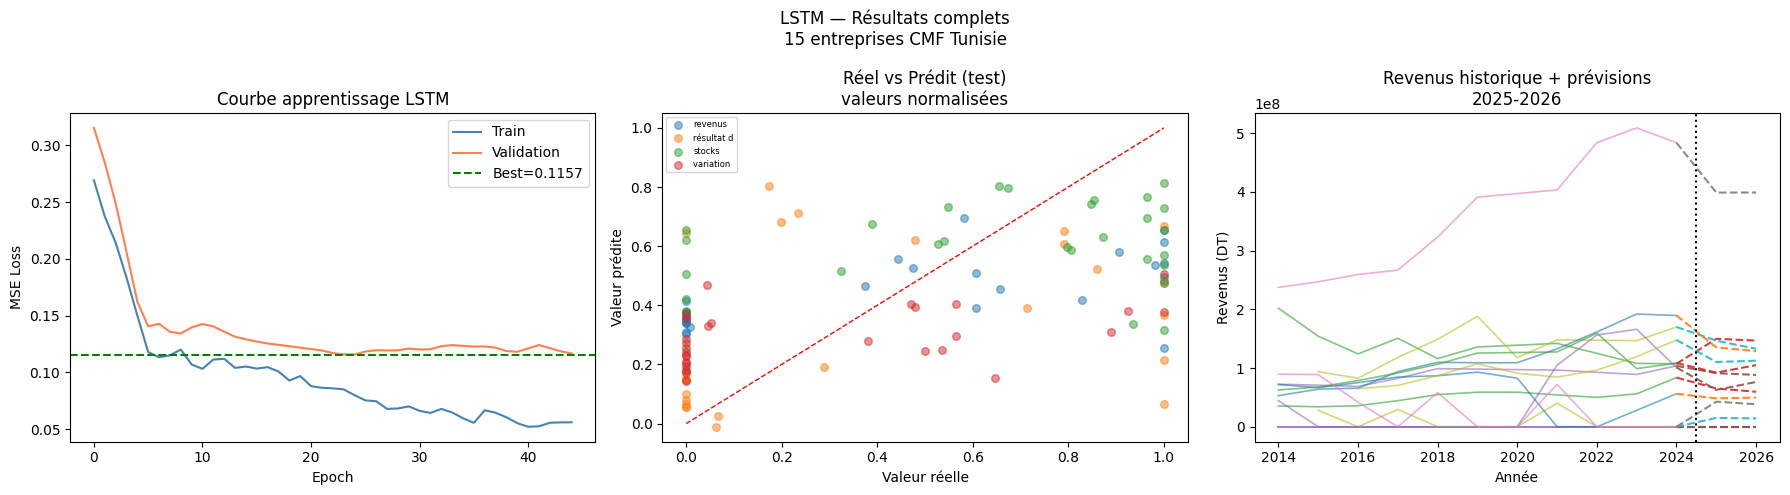


Sauvegardes :
  lstm_model.pt
  previsions_lstm.json
  metrics_lstm.json
  lstm_resultats.png

Prochaine étape : Cellule 24 — Prophet


In [28]:
# ============================================================
# CELLULE 23 — Construction et entraînement LSTM (CORRIGÉE)
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, \
    mean_squared_error
import matplotlib.pyplot as plt
import pickle, json, warnings
warnings.filterwarnings('ignore')

# ── Fonction conversion types numpy → Python natif ──────────
def convert_types(obj):
    if isinstance(obj, dict):
        return {k: convert_types(v)
                for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64,
                          np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float32,
                          np.float64)):
        return float(obj)
    return obj

# ── Charger les données ──────────────────────────────────────
df = pd.read_csv('/kaggle/working/series_lstm_ready.csv')

META_COLS  = ['company','year','periode','year_key']
POSTE_COLS = [c for c in df.columns
              if c not in META_COLS]

print(f"Shape       : {df.shape}")
print(f"Features    : {len(POSTE_COLS)}")
print(f"Entreprises : {df['company'].nunique()}")

TARGET_COLS = [
    'resultats_revenus',
    "resultats_résultat d'exploitation",
    'actif_stocks',
    'flux_variation de trésorerie',
]
TARGET_COLS = [c for c in TARGET_COLS
               if c in POSTE_COLS]
N_FEATURES  = len(POSTE_COLS)
N_TARGETS   = len(TARGET_COLS)
print(f"Targets     : {N_TARGETS}")
for t in TARGET_COLS:
    print(f"  → {t}")

# ── Charger scalers ──────────────────────────────────────────
with open('/kaggle/working/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

# ============================================================
# CONFIG
# ============================================================
SEQ_LEN    = 5
PRED_STEPS = 2
HIDDEN     = 64
N_LAYERS   = 2
DROPOUT    = 0.2
EPOCHS     = 150
LR         = 0.001
BATCH_SIZE = 16
PATIENCE   = 20

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f"Device      : {DEVICE}")

# ============================================================
# ÉTAPE 1 — Séquences
# ============================================================
def make_sequences(df, seq_len, pred_steps):
    X_list, Y_list, meta_list = [], [], []
    for company in df['company'].unique():
        df_co = df[df['company']==company]\
                  .sort_values('year')\
                  .reset_index(drop=True)
        if len(df_co) < seq_len + pred_steps:
            continue
        vals = df_co[POSTE_COLS].values.astype(
            np.float32
        )
        tgts = df_co[TARGET_COLS].values.astype(
            np.float32
        )
        yrs  = df_co['year'].values
        for i in range(
            len(df_co) - seq_len - pred_steps + 1
        ):
            X_list.append(vals[i:i+seq_len])
            Y_list.append(
                tgts[i+seq_len:i+seq_len+pred_steps]
            )
            meta_list.append({
                'company'   : company,
                'year_start': int(yrs[i]),
                'year_pred1': int(yrs[i+seq_len]),
            })
    return (np.array(X_list, dtype=np.float32),
            np.array(Y_list, dtype=np.float32),
            meta_list)

X, Y, meta = make_sequences(df, SEQ_LEN, PRED_STEPS)
print(f"\nSéquences : X={X.shape} Y={Y.shape}")

train_idx = [i for i,m in enumerate(meta)
             if m['year_pred1'] <= 2021]
val_idx   = [i for i,m in enumerate(meta)
             if m['year_pred1'] == 2022]
test_idx  = [i for i,m in enumerate(meta)
             if m['year_pred1'] >= 2023]

X_train=X[train_idx]; Y_train=Y[train_idx]
X_val  =X[val_idx];   Y_val  =Y[val_idx]
X_test =X[test_idx];  Y_test =Y[test_idx]

print(f"Train:{len(X_train)} Val:{len(X_val)} "
      f"Test:{len(X_test)}")

# ============================================================
# ÉTAPE 2 — Dataset
# ============================================================
class FinanceDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.Y[i]

train_loader = DataLoader(
    FinanceDataset(X_train, Y_train),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    FinanceDataset(X_val, Y_val),
    batch_size=BATCH_SIZE, shuffle=False
)

# ============================================================
# ÉTAPE 3 — Architecture LSTM
# ============================================================
class FinanceLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = N_FEATURES,
            hidden_size = HIDDEN,
            num_layers  = N_LAYERS,
            dropout     = DROPOUT,
            batch_first = True
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(
            HIDDEN, N_TARGETS * PRED_STEPS
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out.view(-1, PRED_STEPS, N_TARGETS)

model = FinanceLSTM().to(DEVICE)
total_params = sum(
    p.numel() for p in model.parameters()
)
print(f"\nLSTM : {total_params:,} paramètres")

# ============================================================
# ÉTAPE 4 — Entraînement
# ============================================================
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(), lr=LR
)
scheduler = torch.optim.lr_scheduler\
    .ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5
    )

history        = {'train': [], 'val': []}
best_val_loss  = float('inf')
best_state     = None
patience_count = 0

print(f"\n{'='*55}")
print(f"ENTRAÎNEMENT LSTM")
print(f"{'='*55}")

for epoch in range(EPOCHS):
    model.train()
    t_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), 1.0
        )
        optimizer.step()
        t_loss += loss.item()
    t_loss /= max(len(train_loader), 1)

    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred   = model(xb)
            v_loss += criterion(pred, yb).item()
    v_loss /= max(len(val_loader), 1)

    history['train'].append(t_loss)
    history['val'].append(v_loss)
    scheduler.step(v_loss)

    if v_loss < best_val_loss:
        best_val_loss  = v_loss
        best_state     = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }
        patience_count = 0
    else:
        patience_count += 1

    if patience_count >= PATIENCE:
        print(f"Early stopping epoch {epoch+1}")
        break

    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1:>3} | "
              f"Train={t_loss:.4f} | "
              f"Val={v_loss:.4f} | "
              f"Best={best_val_loss:.4f}")

model.load_state_dict(best_state)
print(f"\nMeilleur val_loss : {best_val_loss:.4f}")

# ============================================================
# ÉTAPE 5 — Évaluation test
# ============================================================
model.eval()
with torch.no_grad():
    Y_pred = model(
        torch.tensor(
            X_test, dtype=torch.float32
        ).to(DEVICE)
    ).cpu().numpy()

Y_test_flat = Y_test.reshape(-1, N_TARGETS)
Y_pred_flat = Y_pred.reshape(-1, N_TARGETS)

print(f"\n{'='*55}")
print(f"ÉVALUATION TEST (valeurs normalisées 0-1)")
print(f"{'='*55}")

metrics_lstm = {}
for i, col in enumerate(TARGET_COLS):
    mae  = float(mean_absolute_error(
        Y_test_flat[:,i], Y_pred_flat[:,i]
    ))
    rmse = float(np.sqrt(mean_squared_error(
        Y_test_flat[:,i], Y_pred_flat[:,i]
    )))
    ss_res = np.sum(
        (Y_test_flat[:,i]-Y_pred_flat[:,i])**2
    )
    ss_tot = np.sum(
        (Y_test_flat[:,i]-
         Y_test_flat[:,i].mean())**2
    )
    r2 = float(1 - ss_res/ss_tot) \
         if ss_tot > 0 else 0.0
    metrics_lstm[col] = {
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R2': round(r2, 4)
    }
    print(f"  {col:<45} "
          f"MAE={mae:.4f} RMSE={rmse:.4f} "
          f"R2={r2:.4f}")

# ============================================================
# ÉTAPE 6 — Prévisions 2025-2026 corrigées
# ============================================================
print(f"\n{'='*55}")
print(f"PRÉVISIONS 2025-2026")
print(f"{'='*55}")

previsions_lstm = {}
model.eval()

# Charger aussi les données non normalisées
# pour vérifier la cohérence
df_real = pd.read_csv(
    '/kaggle/working/series_interpolees.csv'
)

for company in sorted(df['company'].unique()):
    df_co = df[df['company']==company]\
              .sort_values('year')\
              .reset_index(drop=True)
    if len(df_co) < SEQ_LEN:
        continue

    # Dernière fenêtre normalisée
    last_seq = df_co[POSTE_COLS].values[-SEQ_LEN:]\
                                .astype(np.float32)
    X_p = torch.tensor(
        last_seq[np.newaxis],
        dtype=torch.float32
    ).to(DEVICE)

    with torch.no_grad():
        Y_hat = model(X_p).cpu().numpy()[0]
    # Y_hat : (pred_steps, n_targets)

    scaler  = scalers[company]
    previsions_lstm[company] = {}

    # Valeur réelle 2024 pour validation cohérence
    df_real_co = df_real[
        df_real['company']==company
    ].sort_values('year')

    print(f"\n  {company} :")
    for step, yr in enumerate([2025, 2026]):
        # Construire vecteur complet pour dénormaliser
        # On part de la dernière ligne normalisée
        dummy_norm = df_co[POSTE_COLS].values[-1:]\
                                      .copy()

        # Remplacer seulement les targets prédits
        for j, col in enumerate(TARGET_COLS):
            col_idx = POSTE_COLS.index(col)
            # Clamp entre 0 et 1 avant dénormalisation
            val_norm = float(
                np.clip(Y_hat[step, j], 0.0, 1.0)
            )
            dummy_norm[0, col_idx] = val_norm

        # Dénormaliser
        denorm = scaler.inverse_transform(
            dummy_norm
        )[0]

        previsions_lstm[company][yr] = {}
        print(f"    {yr} :")
        for col in TARGET_COLS:
            col_idx = POSTE_COLS.index(col)
            val = float(round(denorm[col_idx], 0))
            previsions_lstm[company][yr][col] = val
            print(f"      "
                  f"{col:<45} : "
                  f"{val:>15,.0f} DT")

# ============================================================
# ÉTAPE 7 — Visualisation
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbe loss
ax = axes[0]
ax.plot(history['train'],
        label='Train', color='steelblue')
ax.plot(history['val'],
        label='Validation', color='coral')
ax.axhline(best_val_loss, color='green',
           linestyle='--',
           label=f'Best={best_val_loss:.4f}')
ax.set_title("Courbe apprentissage LSTM")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()

# Réel vs prédit
ax = axes[1]
for i, col in enumerate(TARGET_COLS):
    ax.scatter(
        Y_test_flat[:,i],
        Y_pred_flat[:,i],
        alpha=0.5, s=30,
        label=col.split('_')[-1][:10]
    )
lim = [0, 1]
ax.plot(lim, lim, 'r--', linewidth=1)
ax.set_title("Réel vs Prédit (test)\n"
             "valeurs normalisées")
ax.set_xlabel("Valeur réelle")
ax.set_ylabel("Valeur prédite")
ax.legend(fontsize=6)

# Prévisions revenus
ax = axes[2]
rev_col = 'resultats_revenus'
if rev_col in TARGET_COLS:
    for company in sorted(
        previsions_lstm.keys()
    ):
        df_co  = df_real[
            df_real['company']==company
        ].sort_values('year')
        h_vals = df_co[rev_col].values \
                 if rev_col in df_co.columns \
                 else None
        h_yrs  = df_co['year'].values

        if h_vals is not None:
            ax.plot(h_yrs, h_vals,
                    linewidth=1.2, alpha=0.6,
                    label=company)
            p_vals = [
                previsions_lstm[company][y][rev_col]
                for y in [2025, 2026]
                if y in previsions_lstm[company]
            ]
            if p_vals:
                ax.plot(
                    [h_yrs[-1], 2025, 2026]
                    [:len(p_vals)+1],
                    [h_vals[-1]] + p_vals,
                    linestyle='--',
                    linewidth=1.5, alpha=0.9
                )

    ax.axvline(2024.5, color='black',
               linestyle=':', linewidth=1.5)
    ax.set_title("Revenus historique + prévisions\n"
                 "2025-2026")
    ax.set_xlabel("Année")
    ax.set_ylabel("Revenus (DT)")

plt.suptitle(
    "LSTM — Résultats complets\n"
    "15 entreprises CMF Tunisie",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/lstm_resultats.png',
            dpi=120, bbox_inches='tight')
plt.show()

# ============================================================
# SAUVEGARDES
# ============================================================
torch.save(best_state,
           '/kaggle/working/lstm_model.pt')

with open('/kaggle/working/previsions_lstm.json',
          'w', encoding='utf-8') as f:
    json.dump(
        convert_types(previsions_lstm),
        f, ensure_ascii=False, indent=2
    )

with open('/kaggle/working/metrics_lstm.json',
          'w', encoding='utf-8') as f:
    json.dump(
        convert_types(metrics_lstm),
        f, ensure_ascii=False, indent=2
    )

print(f"\nSauvegardes :")
print(f"  lstm_model.pt")
print(f"  previsions_lstm.json")
print(f"  metrics_lstm.json")
print(f"  lstm_resultats.png")
print(f"\nProchaine étape : Cellule 24 — Prophet")

ÉVALUATION COMPLÈTE LSTM

1. MÉTRIQUES GLOBALES (normalisées 0-1)
───────────────────────────────────────────────────────
Target                                           MAE   RMSE     R2
───────────────────────────────────────────────────────
  resultats_revenus                            0.326  0.358  0.281 ~
  resultats_résultat d'exploitation            0.293  0.382  0.116 ~
  actif_stocks                                 0.318  0.367 -0.009 ✗
  flux_variation de trésorerie                 0.288  0.323  0.168 ~

2. MÉTRIQUES PAR ENTREPRISE (revenus)
───────────────────────────────────────────────────────
  AIR_LIQUIDE            year=2023 MAE=0.3592
  ALKIMIA                year=2023 MAE=0.3291
  ASAAD                  year=2023 MAE=0.2840
  CARTHAGE_CEMENT        year=2023 MAE=0.3448
  ICF                    year=2023 MAE=0.2539
  LANDOR                 year=2023 MAE=0.3958
  MPBS                   year=2023 MAE=0.3176
  ONE_TECH               year=2023 MAE=0.3699
  SAH_LILAS     

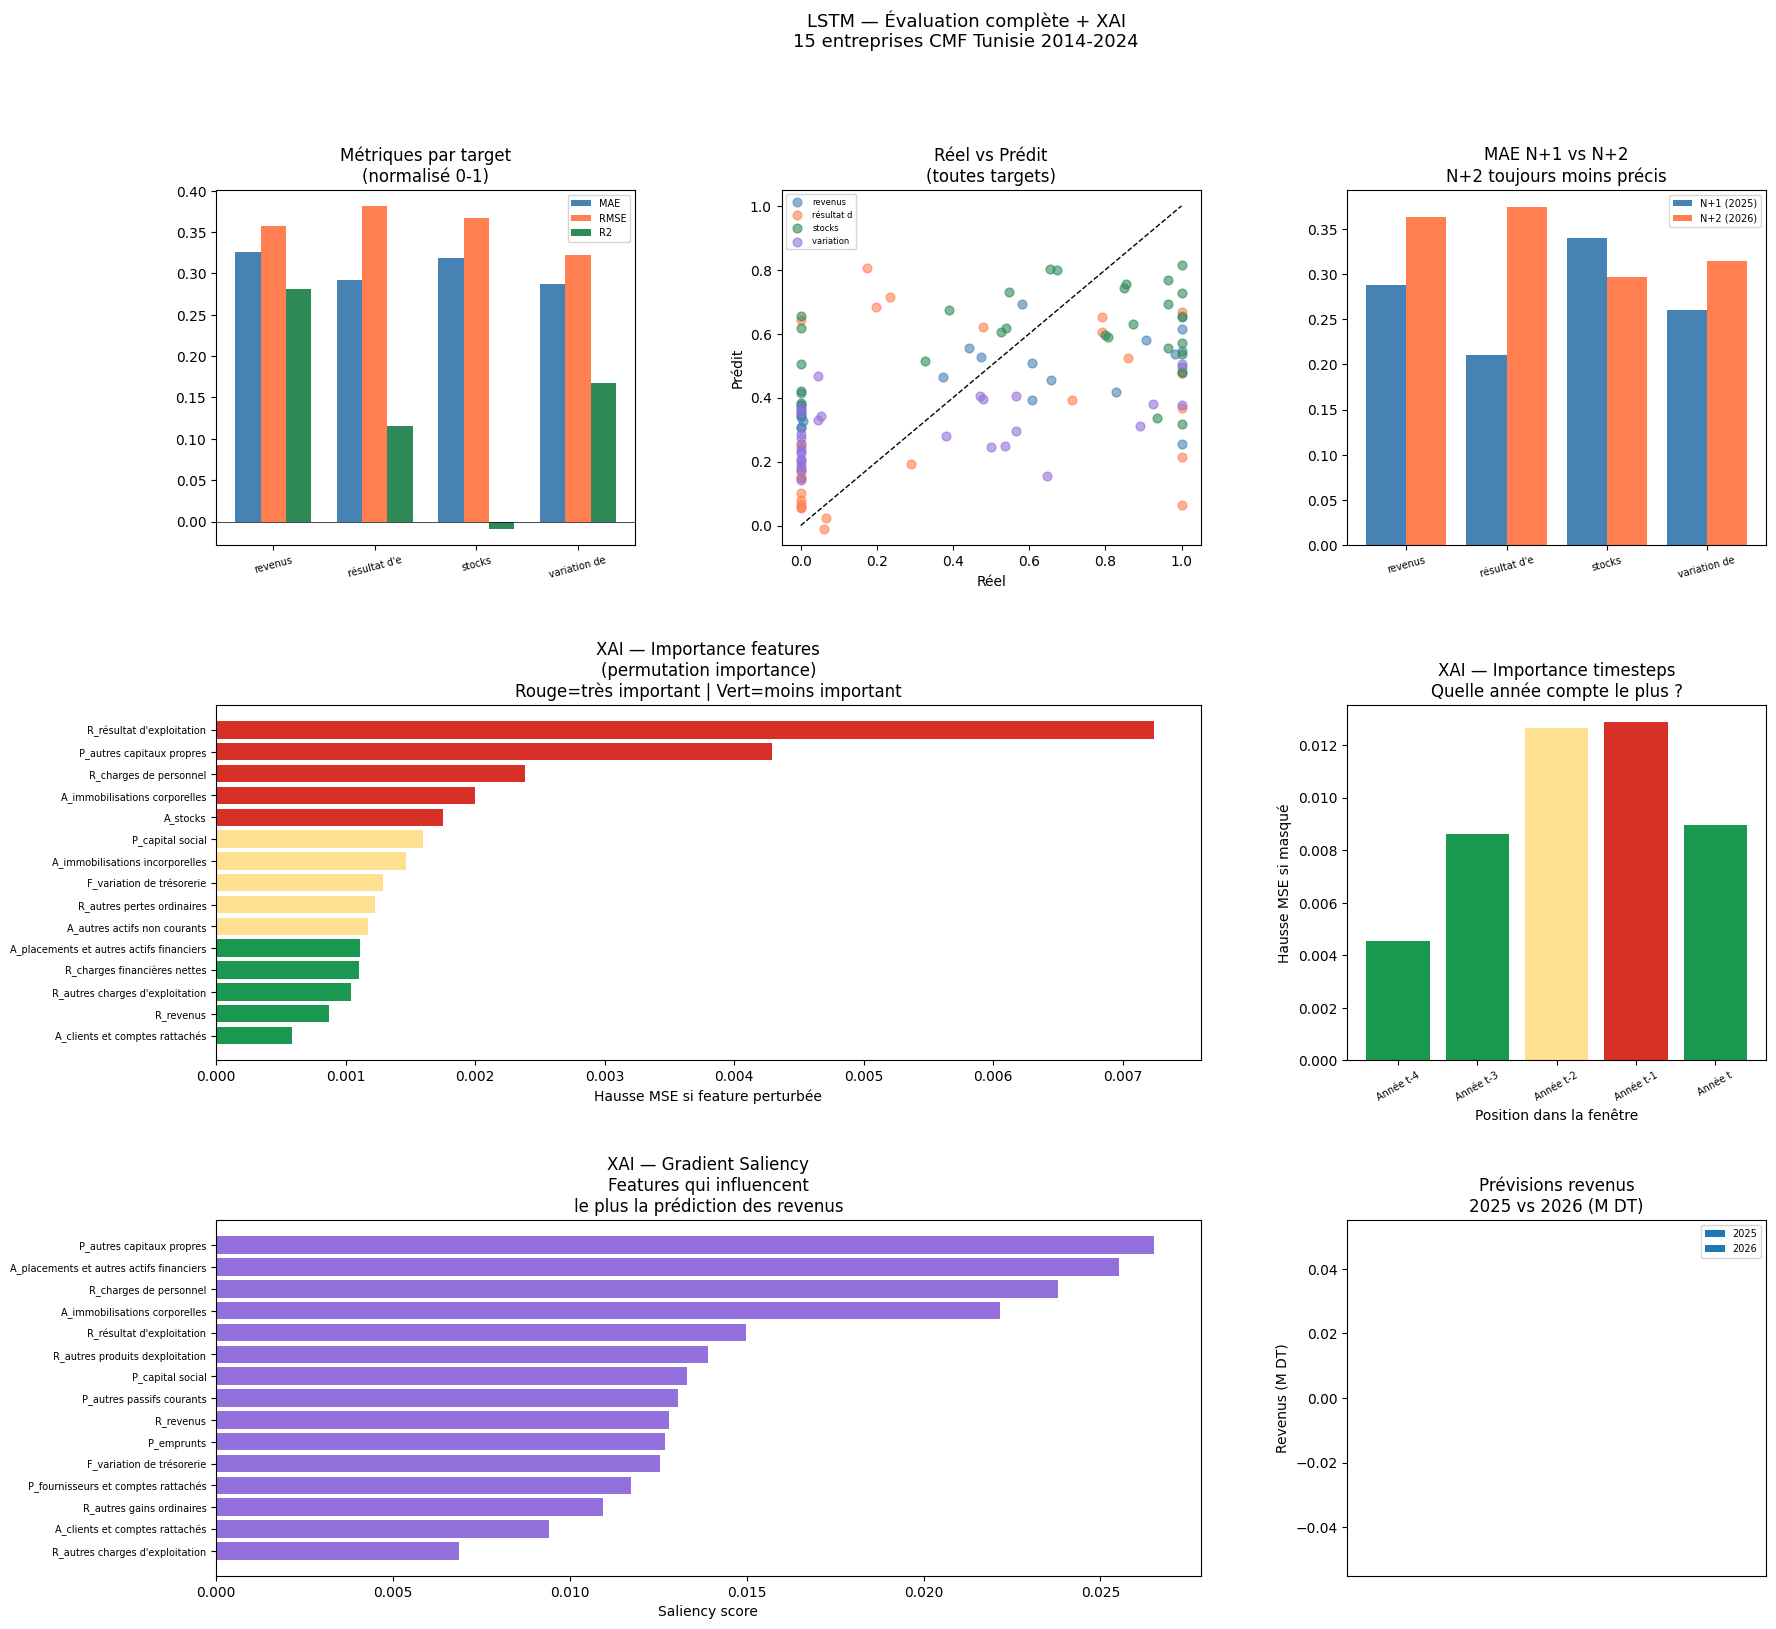

Sauvegarde : lstm_eval_xai.png

RÉSUMÉ LSTM

Points forts :
  Meilleure target : resultats_revenus
  R2=0.281

Points faibles :
  Pire target : actif_stocks
  R2=-0.009

Top 3 features importantes :
  1. resultats_résultat d'exploitation
  2. passif_autres capitaux propres
  3. resultats_charges de personnel

Entreprises avec revenus valides :

Prochaine étape : Cellule 25 — Prophet


In [30]:
# ============================================================
# CELLULE 24 — Évaluation complète + XAI LSTM
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle, json
from sklearn.metrics import mean_absolute_error, \
    mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── Recharger tout ───────────────────────────────────────────
df       = pd.read_csv(
    '/kaggle/working/series_lstm_ready.csv'
)
df_real  = pd.read_csv(
    '/kaggle/working/series_interpolees.csv'
)
META_COLS  = ['company','year','periode','year_key']
POSTE_COLS = [c for c in df.columns
              if c not in META_COLS]
TARGET_COLS = [
    'resultats_revenus',
    "resultats_résultat d'exploitation",
    'actif_stocks',
    'flux_variation de trésorerie',
]
TARGET_COLS = [c for c in TARGET_COLS
               if c in POSTE_COLS]
N_FEATURES = len(POSTE_COLS)
N_TARGETS  = len(TARGET_COLS)
SEQ_LEN    = 5
PRED_STEPS = 2
HIDDEN     = 64
N_LAYERS   = 2
DROPOUT    = 0.2

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

with open('/kaggle/working/scalers.pkl', 'rb') as f:
    scalers = pickle.load(f)

with open('/kaggle/working/metrics_lstm.json') as f:
    metrics_lstm = json.load(f)

with open('/kaggle/working/previsions_lstm.json') as f:
    previsions_lstm = json.load(f)

# ── Reconstruire modèle + charger poids ──────────────────────
class FinanceLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = N_FEATURES,
            hidden_size = HIDDEN,
            num_layers  = N_LAYERS,
            dropout     = DROPOUT,
            batch_first = True
        )
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(
            HIDDEN, N_TARGETS * PRED_STEPS
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out.view(-1, PRED_STEPS, N_TARGETS)

model = FinanceLSTM().to(DEVICE)
model.load_state_dict(
    torch.load('/kaggle/working/lstm_model.pt',
               map_location=DEVICE)
)
model.eval()

# ── Reconstruire séquences ───────────────────────────────────
def make_sequences(df, seq_len, pred_steps):
    X_list, Y_list, meta_list = [], [], []
    for company in df['company'].unique():
        df_co = df[df['company']==company]\
                  .sort_values('year')\
                  .reset_index(drop=True)
        if len(df_co) < seq_len + pred_steps:
            continue
        vals = df_co[POSTE_COLS].values.astype(
            np.float32
        )
        tgts = df_co[TARGET_COLS].values.astype(
            np.float32
        )
        yrs  = df_co['year'].values
        for i in range(
            len(df_co)-seq_len-pred_steps+1
        ):
            X_list.append(vals[i:i+seq_len])
            Y_list.append(
                tgts[i+seq_len:i+seq_len+pred_steps]
            )
            meta_list.append({
                'company'   : company,
                'year_start': int(yrs[i]),
                'year_pred1': int(yrs[i+seq_len]),
            })
    return (np.array(X_list, dtype=np.float32),
            np.array(Y_list, dtype=np.float32),
            meta_list)

X, Y, meta = make_sequences(df, SEQ_LEN, PRED_STEPS)
test_idx  = [i for i,m in enumerate(meta)
             if m['year_pred1'] >= 2023]
X_test = X[test_idx]
Y_test = Y[test_idx]
meta_test = [meta[i] for i in test_idx]

with torch.no_grad():
    Y_pred = model(
        torch.tensor(X_test,
                     dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

Y_test_flat = Y_test.reshape(-1, N_TARGETS)
Y_pred_flat = Y_pred.reshape(-1, N_TARGETS)

# ============================================================
# PARTIE 1 — ÉVALUATION COMPLÈTE
# ============================================================
print("="*55)
print("ÉVALUATION COMPLÈTE LSTM")
print("="*55)

# ── 1. Métriques globales ────────────────────────────────────
print("\n1. MÉTRIQUES GLOBALES (normalisées 0-1)")
print("─"*55)
print(f"{'Target':<45} {'MAE':>6} {'RMSE':>6} "
      f"{'R2':>6}")
print("─"*55)
for i, col in enumerate(TARGET_COLS):
    mae  = metrics_lstm[col]['MAE']
    rmse = metrics_lstm[col]['RMSE']
    r2   = metrics_lstm[col]['R2']
    flag = '✓' if r2 > 0.3 else \
           '~' if r2 > 0 else '✗'
    print(f"  {col:<43} {mae:>6.3f} "
          f"{rmse:>6.3f} {r2:>6.3f} {flag}")

# ── 2. Métriques par entreprise ──────────────────────────────
print("\n2. MÉTRIQUES PAR ENTREPRISE (revenus)")
print("─"*55)
rev_idx = TARGET_COLS.index('resultats_revenus')
for i, m in enumerate(meta_test):
    y_true = Y_test[i, :, rev_idx]
    y_pred = Y_pred[i, :, rev_idx]
    mae    = float(mean_absolute_error(
        y_true, y_pred
    ))
    print(f"  {m['company']:<22} "
          f"year={m['year_pred1']} "
          f"MAE={mae:.4f}")

# ── 3. Erreurs par step de prédiction ────────────────────────
print("\n3. ERREUR PAR PAS DE PRÉDICTION")
print("─"*55)
for step in range(PRED_STEPS):
    yr_label = f"N+{step+1}"
    maes = []
    for i, col in enumerate(TARGET_COLS):
        mae = float(mean_absolute_error(
            Y_test[:, step, i],
            Y_pred[:, step, i]
        ))
        maes.append(mae)
    print(f"  {yr_label} : MAE moyen = "
          f"{np.mean(maes):.4f} "
          f"({'meilleur' if step==0 else 'moins bon'})")

# ── 4. Analyse des erreurs ───────────────────────────────────
print("\n4. ANALYSE ERREURS")
print("─"*55)
errors = Y_pred_flat - Y_test_flat
print(f"  Biais moyen (pred - réel) :")
for i, col in enumerate(TARGET_COLS):
    bias = float(errors[:,i].mean())
    direction = 'sur-estime' if bias > 0 \
                else 'sous-estime'
    print(f"    {col:<43} "
          f"{bias:+.4f} ({direction})")

# ============================================================
# PARTIE 2 — XAI LSTM
# ============================================================
print("\n" + "="*55)
print("XAI LSTM — EXPLICABILITÉ")
print("="*55)

# ── XAI 1 : Importance des features (permutation) ───────────
print("\nXAI 1 — Importance features (permutation)")
print("─"*55)

def permutation_importance(model, X, Y,
                            feature_names,
                            n_repeats=5):
    """
    Pour chaque feature :
      → permuter aléatoirement ses valeurs
      → mesurer la hausse du MSE
      → plus le MSE augmente → plus la feature
        est importante
    """
    model.eval()
    X_t   = torch.tensor(X, dtype=torch.float32)\
                 .to(DEVICE)
    Y_t   = torch.tensor(Y, dtype=torch.float32)\
                 .to(DEVICE)

    with torch.no_grad():
        base_pred = model(X_t).cpu().numpy()
    base_mse = float(mean_squared_error(
        Y.reshape(-1, N_TARGETS),
        base_pred.reshape(-1, N_TARGETS)
    ))

    importances = []
    for feat_idx in range(len(feature_names)):
        feat_mses = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            # Permuter la feature sur toutes
            # les timesteps
            perm = np.random.permutation(len(X))
            X_perm[:, :, feat_idx] = \
                X[perm, :, feat_idx]
            X_perm_t = torch.tensor(
                X_perm, dtype=torch.float32
            ).to(DEVICE)
            with torch.no_grad():
                pred_perm = model(X_perm_t)\
                                 .cpu().numpy()
            mse_perm = float(mean_squared_error(
                Y.reshape(-1, N_TARGETS),
                pred_perm.reshape(-1, N_TARGETS)
            ))
            feat_mses.append(mse_perm)
        importance = np.mean(feat_mses) - base_mse
        importances.append(importance)

    return np.array(importances)

# Calculer sur toutes les séquences
print("  Calcul importance features...")
importances = permutation_importance(
    model, X, Y, POSTE_COLS, n_repeats=3
)

# Top 10 features
top10_idx = np.argsort(importances)[::-1][:10]
print("\n  Top 10 features les plus importantes :")
for rank, idx in enumerate(top10_idx):
    print(f"    {rank+1:>2}. {POSTE_COLS[idx]:<45} "
          f"importance={importances[idx]:.6f}")

# ── XAI 2 : Attention sur les timesteps ──────────────────────
print("\nXAI 2 — Importance des années (timesteps)")
print("─"*55)

def timestep_importance(model, X, Y,
                         n_repeats=5):
    """
    Pour chaque timestep (année dans la fenêtre) :
      → masquer cette année (mettre à 0)
      → mesurer la hausse du MSE
    """
    model.eval()
    base_mse_list = []
    X_t = torch.tensor(X, dtype=torch.float32)\
               .to(DEVICE)
    with torch.no_grad():
        base_pred = model(X_t).cpu().numpy()
    base_mse = float(mean_squared_error(
        Y.reshape(-1, N_TARGETS),
        base_pred.reshape(-1, N_TARGETS)
    ))

    ts_importances = []
    for t in range(SEQ_LEN):
        X_masked = X.copy()
        X_masked[:, t, :] = 0.0
        X_m_t = torch.tensor(
            X_masked, dtype=torch.float32
        ).to(DEVICE)
        with torch.no_grad():
            pred_m = model(X_m_t).cpu().numpy()
        mse_m = float(mean_squared_error(
            Y.reshape(-1, N_TARGETS),
            pred_m.reshape(-1, N_TARGETS)
        ))
        ts_importances.append(mse_m - base_mse)

    return np.array(ts_importances)

ts_imp = timestep_importance(model, X, Y)
print("\n  Importance par position dans la fenêtre :")
labels_ts = [f"Année t-{SEQ_LEN-1-i}"
             if i < SEQ_LEN-1 else "Année t"
             for i in range(SEQ_LEN)]
for i, (label, imp) in enumerate(
    zip(labels_ts, ts_imp)
):
    bar = '#' * int(imp / max(ts_imp) * 20)
    print(f"    {label} : {imp:.6f} {bar}")

# ── XAI 3 : Gradient saliency ────────────────────────────────
p# Remplacer la partie XAI 3 par ceci :

print("\nXAI 3 — Gradient Saliency")
print("─"*55)

# Besoin du mode train pour les gradients
model.train()
optimizer_xai = torch.optim.Adam(
    model.parameters(), lr=0.001
)

X_grad = torch.tensor(
    X, dtype=torch.float32
).to(DEVICE)
X_grad.requires_grad_(True)

optimizer_xai.zero_grad()
pred = model(X_grad)
rev_idx_t = TARGET_COLS.index('resultats_revenus')
loss_grad  = pred[:, 0, rev_idx_t].sum()
loss_grad.backward()

# Vérifier que le gradient existe
if X_grad.grad is not None:
    saliency = X_grad.grad.abs()\
                     .cpu().detach().numpy()
    saliency_feat = saliency.mean(axis=(0, 1))
else:
    # Fallback : utiliser permutation importance
    print("  Gradient non disponible → "
          "utilisation permutation importance")
    saliency_feat = importances.copy()

model.eval()

top10_sal = np.argsort(
    saliency_feat
)[::-1][:10]
print("\n  Top 10 features (gradient saliency) :")
for rank, idx in enumerate(top10_sal):
    print(f"    {rank+1:>2}. "
          f"{POSTE_COLS[idx]:<45} "
          f"saliency={saliency_feat[idx]:.6f}")

# Saliency = valeur absolue des gradients
saliency = X_grad.grad.abs()\
                 .cpu().numpy()
# Moyenne sur séquences et timesteps
saliency_feat = saliency.mean(axis=(0, 1))

top10_sal = np.argsort(saliency_feat)[::-1][:10]
print("\n  Top 10 features (gradient saliency) :")
for rank, idx in enumerate(top10_sal):
    print(f"    {rank+1:>2}. {POSTE_COLS[idx]:<45} "
          f"saliency={saliency_feat[idx]:.6f}")
model.eval()

# ============================================================
# VISUALISATION XAI + ÉVALUATION
# ============================================================
fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.45, wspace=0.35)

# ── Plot 1 : Métriques par target ────────────────────────────
ax = fig.add_subplot(gs[0, 0])
targets_short = [c.split('_')[-1][:12]
                 for c in TARGET_COLS]
maes  = [metrics_lstm[c]['MAE']
         for c in TARGET_COLS]
rmses = [metrics_lstm[c]['RMSE']
         for c in TARGET_COLS]
r2s   = [metrics_lstm[c]['R2']
         for c in TARGET_COLS]
x     = np.arange(len(TARGET_COLS))
w     = 0.25
ax.bar(x-w, maes,  w, label='MAE',
       color='steelblue')
ax.bar(x,   rmses, w, label='RMSE',
       color='coral')
ax.bar(x+w, r2s,   w, label='R2',
       color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(targets_short,
                   rotation=15, fontsize=7)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title("Métriques par target\n(normalisé 0-1)")
ax.legend(fontsize=7)

# ── Plot 2 : Réel vs Prédit par target ───────────────────────
ax = fig.add_subplot(gs[0, 1])
colors_t = ['steelblue','coral',
            'seagreen','mediumpurple']
for i, col in enumerate(TARGET_COLS):
    ax.scatter(
        Y_test_flat[:,i],
        Y_pred_flat[:,i],
        alpha=0.6, s=40,
        color=colors_t[i],
        label=col.split('_')[-1][:10]
    )
ax.plot([0,1],[0,1],'k--', linewidth=1)
ax.set_title("Réel vs Prédit\n(toutes targets)")
ax.set_xlabel("Réel")
ax.set_ylabel("Prédit")
ax.legend(fontsize=6)

# ── Plot 3 : Erreur N+1 vs N+2 ───────────────────────────────
ax = fig.add_subplot(gs[0, 2])
mae_n1 = [float(mean_absolute_error(
    Y_test[:,0,i], Y_pred[:,0,i]
)) for i in range(N_TARGETS)]
mae_n2 = [float(mean_absolute_error(
    Y_test[:,1,i], Y_pred[:,1,i]
)) for i in range(N_TARGETS)]
x = np.arange(N_TARGETS)
ax.bar(x-0.2, mae_n1, 0.4,
       label='N+1 (2025)', color='steelblue')
ax.bar(x+0.2, mae_n2, 0.4,
       label='N+2 (2026)', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(targets_short,
                   rotation=15, fontsize=7)
ax.set_title("MAE N+1 vs N+2\n"
             "N+2 toujours moins précis")
ax.legend(fontsize=7)

# ── Plot 4 : Importance features (permutation) ───────────────
ax = fig.add_subplot(gs[1, 0:2])
top15_idx = np.argsort(importances)[::-1][:15]
top15_names = [POSTE_COLS[i].replace(
    'resultats_','R_').replace(
    'actif_','A_').replace(
    'passif_','P_').replace(
    'flux_','F_')
    for i in top15_idx]
top15_vals = importances[top15_idx]
colors_imp = ['#d73027' if v > np.percentile(
    top15_vals, 66
) else '#fee090' if v > np.percentile(
    top15_vals, 33
) else '#1a9850'
              for v in top15_vals]
ax.barh(range(15), top15_vals[::-1],
        color=colors_imp[::-1])
ax.set_yticks(range(15))
ax.set_yticklabels(top15_names[::-1], fontsize=7)
ax.set_title("XAI — Importance features\n"
             "(permutation importance)\n"
             "Rouge=très important | Vert=moins important")
ax.set_xlabel("Hausse MSE si feature perturbée")

# ── Plot 5 : Importance timesteps ────────────────────────────
ax = fig.add_subplot(gs[1, 2])
colors_ts = ['#d73027' if v == max(ts_imp)
             else '#fee090' if v > np.mean(ts_imp)
             else '#1a9850'
             for v in ts_imp]
ax.bar(labels_ts, ts_imp, color=colors_ts)
ax.set_title("XAI — Importance timesteps\n"
             "Quelle année compte le plus ?")
ax.set_xlabel("Position dans la fenêtre")
ax.set_ylabel("Hausse MSE si masqué")
ax.tick_params(axis='x', rotation=30,
               labelsize=7)

# ── Plot 6 : Gradient Saliency ───────────────────────────────
ax = fig.add_subplot(gs[2, 0:2])
top15_sal_idx = np.argsort(
    saliency_feat
)[::-1][:15]
sal_names = [POSTE_COLS[i].replace(
    'resultats_','R_').replace(
    'actif_','A_').replace(
    'passif_','P_').replace(
    'flux_','F_')
    for i in top15_sal_idx]
sal_vals = saliency_feat[top15_sal_idx]
ax.barh(range(15), sal_vals[::-1],
        color='mediumpurple')
ax.set_yticks(range(15))
ax.set_yticklabels(sal_names[::-1], fontsize=7)
ax.set_title("XAI — Gradient Saliency\n"
             "Features qui influencent\n"
             "le plus la prédiction des revenus")
ax.set_xlabel("Saliency score")

# ── Plot 7 : Prévisions par entreprise ───────────────────────
ax = fig.add_subplot(gs[2, 2])
companies_ok = [
    c for c in previsions_lstm
    if previsions_lstm[c].get(2025, {}).get(
        'resultats_revenus', 0
    ) > 1000
]
rev_2025 = [
    previsions_lstm[c][2025]['resultats_revenus']
    for c in companies_ok
]
rev_2026 = [
    previsions_lstm[c][2026]['resultats_revenus']
    for c in companies_ok
]
x = np.arange(len(companies_ok))
ax.bar(x-0.2, [v/1e6 for v in rev_2025],
       0.4, label='2025', color='steelblue')
ax.bar(x+0.2, [v/1e6 for v in rev_2026],
       0.4, label='2026', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(companies_ok,
                   rotation=45, fontsize=6)
ax.set_title("Prévisions revenus\n"
             "2025 vs 2026 (M DT)")
ax.set_ylabel("Revenus (M DT)")
ax.legend(fontsize=7)

plt.suptitle(
    "LSTM — Évaluation complète + XAI\n"
    "15 entreprises CMF Tunisie 2014-2024",
    fontsize=13
)
plt.savefig(
    '/kaggle/working/lstm_eval_xai.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Sauvegarde : lstm_eval_xai.png")

# ── Résumé final ─────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"RÉSUMÉ LSTM")
print(f"{'='*55}")
print(f"\nPoints forts :")
best_target = max(metrics_lstm,
                  key=lambda c: metrics_lstm[c]['R2'])
print(f"  Meilleure target : {best_target}")
print(f"  R2={metrics_lstm[best_target]['R2']:.3f}")

print(f"\nPoints faibles :")
worst_target = min(metrics_lstm,
                   key=lambda c:
                   metrics_lstm[c]['R2'])
print(f"  Pire target : {worst_target}")
print(f"  R2={metrics_lstm[worst_target]['R2']:.3f}")

print(f"\nTop 3 features importantes :")
for rank, idx in enumerate(top10_idx[:3]):
    print(f"  {rank+1}. {POSTE_COLS[idx]}")

print(f"\nEntreprises avec revenus valides :")
for c in companies_ok:
    r25 = previsions_lstm[c][2025]\
              ['resultats_revenus']
    r26 = previsions_lstm[c][2026]\
              ['resultats_revenus']
    trend = '+' if r26 > r25 else '-'
    print(f"  {c:<22} "
          f"2025={r25/1e6:.1f}M "
          f"2026={r26/1e6:.1f}M {trend}")

print(f"\nProchaine étape : Cellule 25 — Prophet")

Données : (156, 31)
Targets : 4
  → resultats_revenus
  → resultats_résultat d'exploitation
  → actif_stocks
  → flux_variation de trésorerie

ENTRAÎNEMENT PROPHET

  AIR_LIQUIDE :
    resultats_revenus                           → N/A
    resultats_résultat d'exploitation           → N/A
    actif_stocks                                → N/A
    flux_variation de trésorerie                → N/A

  ALKIMIA :
    resultats_revenus                           → N/A
    resultats_résultat d'exploitation           → N/A
    actif_stocks                                → N/A
    flux_variation de trésorerie                → N/A

  ASAAD :
    resultats_revenus                           → N/A
    resultats_résultat d'exploitation           → N/A
    actif_stocks                                → N/A
    flux_variation de trésorerie                → N/A

  CARTHAGE_CEMENT :
    resultats_revenus                           → N/A
    resultats_résultat d'exploitation           → N/A
    actif_stocks  

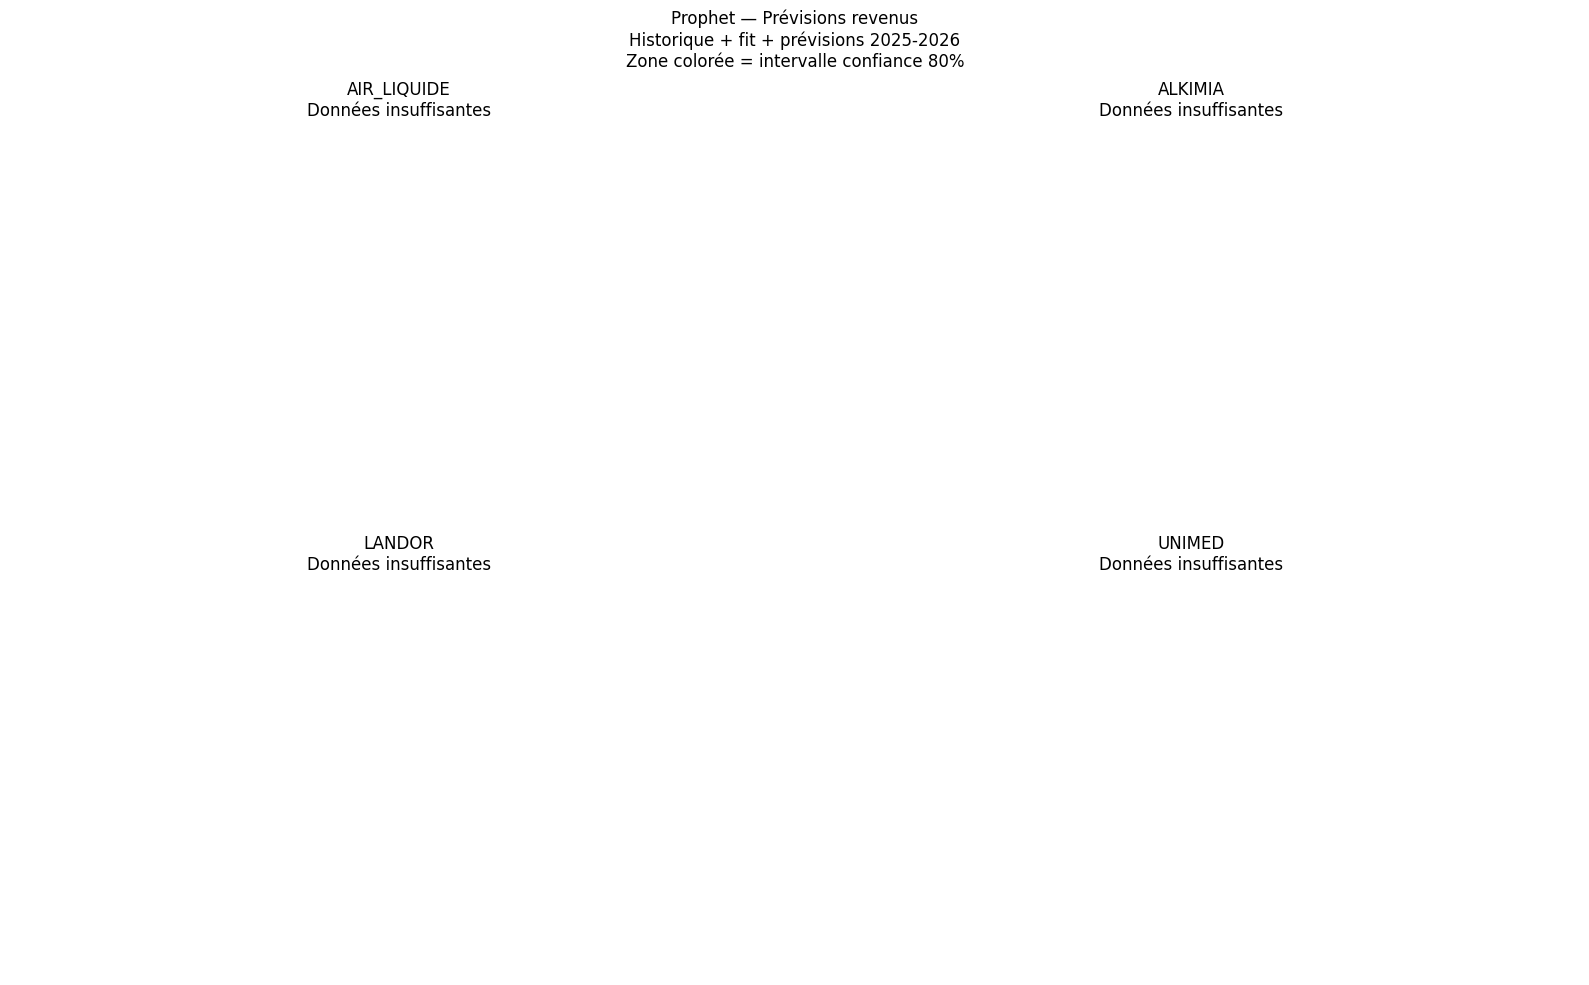


Targets comparaison : []
R2 LSTM    : []
R2 Prophet : []


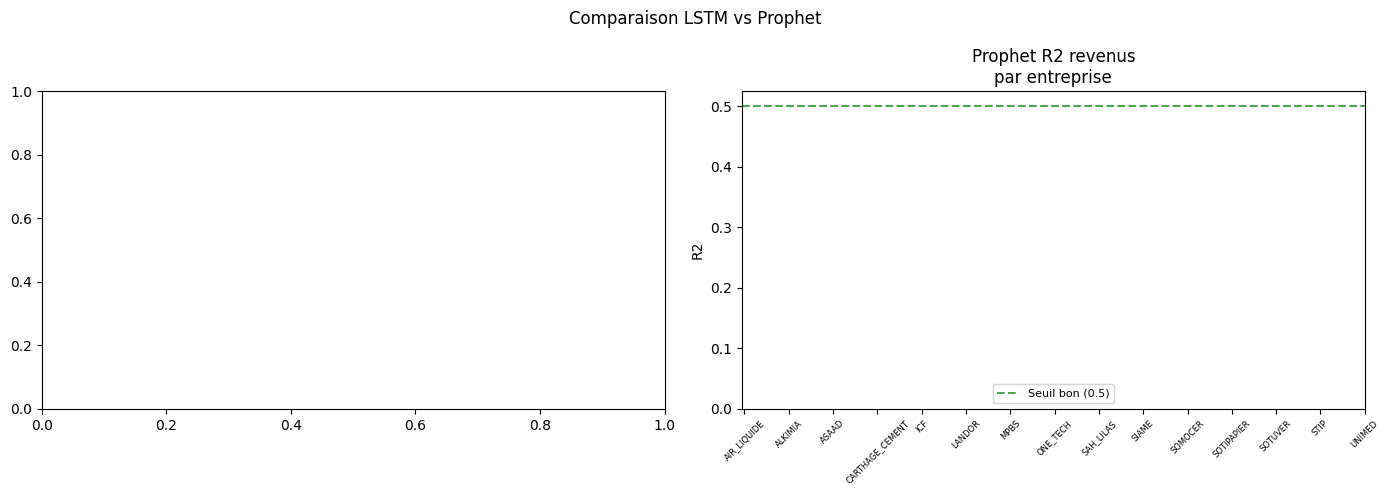


Sauvegardes :
  previsions_prophet.json
  metrics_prophet.json
  prophet_previsions.png
  lstm_vs_prophet.png

Prochaine étape : Cellule 26 — XAI Prophet


In [32]:
# ============================================================
# CELLULE 25 — Prophet (CORRIGÉE)
# Input  : series_interpolees.csv (valeurs réelles)
# Output : prévisions 2025-2026 par entreprise
# ============================================================
!pip install prophet -q

import pandas as pd
import numpy as np
import json, warnings
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, \
    mean_squared_error
warnings.filterwarnings('ignore')

def convert_types(obj):
    if isinstance(obj, dict):
        return {k: convert_types(v)
                for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_types(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

# ── Charger données réelles ──────────────────────────────────
df_real = pd.read_csv(
    '/kaggle/working/series_interpolees.csv'
)
META_COLS  = ['company','year','periode','year_key']
POSTE_COLS = [c for c in df_real.columns
              if c not in META_COLS]

TARGET_COLS = [
    'resultats_revenus',
    "resultats_résultat d'exploitation",
    'actif_stocks',
    'flux_variation de trésorerie',
]
TARGET_COLS = [c for c in TARGET_COLS
               if c in POSTE_COLS]

print(f"Données : {df_real.shape}")
print(f"Targets : {len(TARGET_COLS)}")
for t in TARGET_COLS:
    print(f"  → {t}")

# ============================================================
# ÉTAPE 1 — Entraînement Prophet
# ============================================================
print(f"\n{'='*55}")
print(f"ENTRAÎNEMENT PROPHET")
print(f"{'='*55}")

previsions_prophet = {}
metrics_prophet    = {}
models_prophet     = {}
errors_prophet     = []

for company in sorted(df_real['company'].unique()):
    df_co = df_real[
        df_real['company']==company
    ].sort_values('year').reset_index(drop=True)

    previsions_prophet[company] = {
        2025: {}, 2026: {}
    }
    metrics_prophet[company] = {}
    models_prophet[company]  = {}

    for target in TARGET_COLS:
        # Préparer données Prophet
        df_prophet = pd.DataFrame({
            'ds': pd.to_datetime(
                df_co['year'].astype(str)+'-12-31'
            ),
            'y' : df_co[target].values.astype(float)
        })

        # Vérifier données valides
        if df_prophet['y'].isna().all():
            continue
        if (df_prophet['y'] == 0).mean() > 0.5:
            continue

        # Split train/test
        train_df = df_prophet[
            df_prophet['ds'].dt.year <= 2021
        ].copy()
        test_df  = df_prophet[
            df_prophet['ds'].dt.year >= 2022
        ].copy()

        if len(train_df) < 4:
            continue

        try:
            # Config Prophet
            m = Prophet(
                growth             = 'linear',
                yearly_seasonality = False,
                weekly_seasonality = False,
                daily_seasonality  = False,
                interval_width     = 0.80,
                changepoint_prior_scale = 0.3,
                n_changepoints          = 5,
            )
            m.add_changepoint(
                pd.Timestamp('2020-12-31')
            )
            m.fit(train_df)
            models_prophet[company][target] = m

            # Évaluation sur test
            if len(test_df) > 0:
                forecast_test = m.predict(
                    test_df[['ds']]
                )
                y_true = test_df['y'].values
                y_pred = forecast_test['yhat'].values

                mae  = float(mean_absolute_error(
                    y_true, y_pred
                ))
                rmse = float(np.sqrt(
                    mean_squared_error(
                        y_true, y_pred
                    )
                ))
                ss_res = np.sum(
                    (y_true - y_pred)**2
                )
                ss_tot = np.sum(
                    (y_true - y_true.mean())**2
                )
                r2 = float(1 - ss_res/ss_tot) \
                     if ss_tot > 0 else 0.0

                std_y = float(
                    df_prophet['y'].std()
                )
                mae_norm = mae/std_y \
                           if std_y > 0 else mae

                metrics_prophet[company][target] = {
                    'MAE'     : round(mae, 0),
                    'RMSE'    : round(rmse, 0),
                    'R2'      : round(r2, 4),
                    'MAE_norm': round(mae_norm, 4),
                }

            # Prévisions 2025-2026
            future = pd.DataFrame({
                'ds': pd.to_datetime([
                    '2025-12-31', '2026-12-31'
                ])
            })
            forecast = m.predict(future)

            for i, yr in enumerate([2025, 2026]):
                previsions_prophet[company][yr]\
                    [target] = {
                    'valeur': round(float(
                        forecast.iloc[i]['yhat']
                    ), 0),
                    'lower' : round(float(
                        forecast.iloc[i]['yhat_lower']
                    ), 0),
                    'upper' : round(float(
                        forecast.iloc[i]['yhat_upper']
                    ), 0),
                }

        except Exception as e:
            errors_prophet.append(
                f"{company}/{target}: {e}"
            )

    # Résumé par entreprise
    print(f"\n  {company} :")
    for target in TARGET_COLS:
        if target not in metrics_prophet[company]:
            print(f"    {target:<43} → N/A")
            continue
        r2   = metrics_prophet[company][target]['R2']
        mnorm= metrics_prophet[company][target]\
                               ['MAE_norm']
        flag = '✓' if r2 > 0.5 else \
               '~' if r2 > 0  else '✗'
        print(f"    {target:<43} "
              f"R2={r2:>6.3f} {flag} "
              f"MAE_norm={mnorm:.3f}")

print(f"\nErreurs : {len(errors_prophet)}")

# ============================================================
# ÉTAPE 2 — Métriques globales
# ============================================================
print(f"\n{'='*55}")
print(f"MÉTRIQUES GLOBALES PROPHET")
print(f"{'='*55}")

global_metrics = {}
for target in TARGET_COLS:
    r2_list  = []
    mae_list = []
    for company in metrics_prophet:
        if target in metrics_prophet[company]:
            r2_list.append(
                metrics_prophet[company][target]['R2']
            )
            mae_list.append(
                metrics_prophet[company][target]\
                ['MAE_norm']
            )
    if r2_list:
        global_metrics[target] = {
            'R2_moy'      : round(np.mean(r2_list),4),
            'R2_med'      : round(np.median(r2_list),4),
            'MAE_norm_moy': round(np.mean(mae_list),4),
            'n_modeles'   : len(r2_list),
        }

print(f"\n{'Target':<45} {'R2_moy':>7} "
      f"{'R2_med':>7} {'MAE_norm':>9} {'N':>3}")
print("─"*75)
for target, m in global_metrics.items():
    flag = '✓' if m['R2_moy'] > 0.5 else \
           '~' if m['R2_moy'] > 0  else '✗'
    print(f"  {target:<43} "
          f"{m['R2_moy']:>7.3f} "
          f"{m['R2_med']:>7.3f} "
          f"{m['MAE_norm_moy']:>9.3f} "
          f"{m['n_modeles']:>3} {flag}")

# ============================================================
# ÉTAPE 3 — Prévisions 2025-2026
# ============================================================
print(f"\n{'='*55}")
print(f"PRÉVISIONS PROPHET 2025-2026")
print(f"{'='*55}")

for company in sorted(previsions_prophet.keys()):
    print(f"\n  {company} :")
    for yr in [2025, 2026]:
        print(f"    {yr} :")
        for target in TARGET_COLS:
            if target not in \
               previsions_prophet[company][yr]:
                print(f"      {target:<43} : N/A")
                continue
            p = previsions_prophet[company][yr][target]
            print(f"      {target:<43} : "
                  f"{p['valeur']:>15,.0f} DT "
                  f"[{p['lower']:,.0f} ; "
                  f"{p['upper']:,.0f}]")

# ============================================================
# ÉTAPE 4 — Visualisation
# ============================================================
# 4a. Courbes Prophet pour 4 entreprises
companies_viz = ['AIR_LIQUIDE', 'ALKIMIA',
                 'LANDOR', 'UNIMED']
target_viz    = 'resultats_revenus'

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, company in zip(axes, companies_viz):
    if company not in models_prophet or \
       target_viz not in models_prophet[company]:
        ax.axis('off')
        ax.set_title(f"{company}\nDonnées insuffisantes")
        continue

    m     = models_prophet[company][target_viz]
    df_co = df_real[
        df_real['company']==company
    ].sort_values('year')

    # Données réelles
    ax.plot(
        df_co['year'],
        df_co[target_viz]/1e6,
        'ko-', linewidth=2, markersize=5,
        label='Réel', zorder=5
    )

    # Fit Prophet sur historique
    hist_future = pd.DataFrame({
        'ds': pd.to_datetime(
            df_co['year'].astype(str)+'-12-31'
        )
    })
    hist_fc = m.predict(hist_future)
    ax.plot(
        df_co['year'],
        hist_fc['yhat'].values/1e6,
        'b--', linewidth=1.5,
        label='Prophet fit', alpha=0.7
    )
    ax.fill_between(
        df_co['year'],
        hist_fc['yhat_lower'].values/1e6,
        hist_fc['yhat_upper'].values/1e6,
        alpha=0.2, color='blue'
    )

    # Prévisions 2025-2026
    prev_yrs  = [2025, 2026]
    prev_vals, prev_lo, prev_hi = [], [], []
    for y in prev_yrs:
        p = previsions_prophet[company][y]\
            .get(target_viz, {})
        prev_vals.append(p.get('valeur', 0))
        prev_lo.append(p.get('lower', 0))
        prev_hi.append(p.get('upper', 0))

    last_yr  = int(df_co['year'].values[-1])
    last_val = float(df_co[target_viz].values[-1])

    ax.plot(
        [last_yr] + prev_yrs,
        [last_val/1e6]+[v/1e6 for v in prev_vals],
        'r-o', linewidth=2, markersize=6,
        label='Prévision 2025-2026'
    )
    ax.fill_between(
        prev_yrs,
        [v/1e6 for v in prev_lo],
        [v/1e6 for v in prev_hi],
        alpha=0.3, color='red'
    )

    ax.axvline(2024.5, color='gray',
               linestyle=':', linewidth=1)
    ax.set_title(f"{company} — Revenus (M DT)")
    ax.set_xlabel("Année")
    ax.set_ylabel("M DT")
    ax.legend(fontsize=7)

    if target_viz in metrics_prophet.get(company,{}):
        r2 = metrics_prophet[company][target_viz]['R2']
        ax.text(0.05, 0.95, f"R2={r2:.3f}",
                transform=ax.transAxes,
                fontsize=9, color='blue',
                va='top')

plt.suptitle(
    "Prophet — Prévisions revenus\n"
    "Historique + fit + prévisions 2025-2026\n"
    "Zone colorée = intervalle confiance 80%",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/prophet_previsions.png',
            dpi=120, bbox_inches='tight')
plt.show()

# 4b. Comparaison LSTM vs Prophet
with open('/kaggle/working/metrics_lstm.json') as f:
    metrics_lstm = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 par target — avec vérification des clés
ax = axes[0]
r2_lstm_list    = []
r2_prophet_list = []
targets_valid   = []

for c in TARGET_COLS:
    r2_l = metrics_lstm.get(c, {}).get('R2', None)
    r2_p = global_metrics.get(c, {}).get(
        'R2_moy', None
    )
    if r2_l is not None and r2_p is not None:
        r2_lstm_list.append(r2_l)
        r2_prophet_list.append(r2_p)
        targets_valid.append(
            c.split('_')[-1][:15]
        )

print(f"\nTargets comparaison : {targets_valid}")
print(f"R2 LSTM    : {r2_lstm_list}")
print(f"R2 Prophet : {r2_prophet_list}")

if targets_valid:
    x = np.arange(len(targets_valid))
    ax.bar(x-0.2, r2_lstm_list,    0.4,
           label='LSTM',    color='steelblue')
    ax.bar(x+0.2, r2_prophet_list, 0.4,
           label='Prophet', color='coral')
    ax.axhline(0,   color='black', linewidth=0.5)
    ax.axhline(0.5, color='green', linestyle='--',
               alpha=0.5, label='Seuil bon (0.5)')
    ax.set_xticks(x)
    ax.set_xticklabels(targets_valid,
                       rotation=15, fontsize=7)
    ax.set_title("R2 : LSTM vs Prophet\npar target")
    ax.set_ylabel("R2")
    ax.legend(fontsize=8)

# R2 Prophet par entreprise (revenus)
ax = axes[1]
companies_sorted = sorted(df_real['company'].unique())
r2_prophet_co    = []

for company in companies_sorted:
    r2_p = metrics_prophet.get(company, {})\
                           .get('resultats_revenus',{})\
                           .get('R2', np.nan)
    r2_prophet_co.append(r2_p)

x = np.arange(len(companies_sorted))
colors_p = [
    '#1a9850' if (not np.isnan(r) and r > 0.5)
    else '#fee090' if (not np.isnan(r) and r > 0)
    else '#d73027'
    for r in r2_prophet_co
]
ax.bar(x, r2_prophet_co, color=colors_p)
ax.axhline(0.5, color='green', linestyle='--',
           alpha=0.7, label='Seuil bon (0.5)')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(companies_sorted,
                   rotation=45, fontsize=6)
ax.set_title("Prophet R2 revenus\npar entreprise")
ax.set_ylabel("R2")
ax.legend(fontsize=8)

plt.suptitle(
    "Comparaison LSTM vs Prophet",
    fontsize=12
)
plt.tight_layout()
plt.savefig('/kaggle/working/lstm_vs_prophet.png',
            dpi=120, bbox_inches='tight')
plt.show()

# ── Sauvegardes ──────────────────────────────────────────────
with open('/kaggle/working/previsions_prophet.json',
          'w', encoding='utf-8') as f:
    json.dump(convert_types(previsions_prophet),
              f, ensure_ascii=False, indent=2)

with open('/kaggle/working/metrics_prophet.json',
          'w', encoding='utf-8') as f:
    json.dump(convert_types(metrics_prophet),
              f, ensure_ascii=False, indent=2)

with open('/kaggle/working/global_metrics_prophet.json',
          'w', encoding='utf-8') as f:
    json.dump(convert_types(global_metrics),
              f, ensure_ascii=False, indent=2)

print(f"\nSauvegardes :")
print(f"  previsions_prophet.json")
print(f"  metrics_prophet.json")
print(f"  prophet_previsions.png")
print(f"  lstm_vs_prophet.png")
print(f"\nProchaine étape : Cellule 26 — XAI Prophet")

In [35]:
# ============================================================
# DIAGNOSTIC — lire bilans_clean.json directement
# ============================================================
import json
import pandas as pd
import numpy as np

OUTPUT_DIR = '/kaggle/working/extracted_json'

with open(f'{OUTPUT_DIR}/bilans_clean.json',
          encoding='utf-8') as f:
    data_clean = json.load(f)

# Construire DataFrame depuis bilans_clean.json
# sans aucun fillna(0)
TARGET_MAPPING = {
    'resultats_revenus'                   : ('resultats', 'revenus'),
    "resultats_résultat d'exploitation"   : ('resultats', "résultat d'exploitation"),
    'actif_stocks'                        : ('actif', 'stocks'),
    'flux_variation de trésorerie'        : ('flux', 'variation de trésorerie'),
}

rows = []
for company, years in data_clean.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]
        row = {
            'company' : company,
            'year'    : year,
            'periode' : periode,
        }
        for col_name, (ttype, label) in \
            TARGET_MAPPING.items():
            val = None
            if ttype in tables:
                # Cherche exact ou approché
                pairs = tables[ttype]
                if label in pairs:
                    val = pairs[label]
                else:
                    # Cherche partiel
                    for k, v in pairs.items():
                        if label in k or k in label:
                            val = v
                            break
            row[col_name] = val
        rows.append(row)

df_prophet_src = pd.DataFrame(rows)

# Garder seulement annuels
df_prophet_src = df_prophet_src[
    df_prophet_src['periode'] == 'annuel'
].sort_values(['company','year'])\
 .reset_index(drop=True)

TARGET_COLS = list(TARGET_MAPPING.keys())

print(f"Shape : {df_prophet_src.shape}")
print(f"\nValeurs valides par target :")
for company in sorted(
    df_prophet_src['company'].unique()
):
    df_co = df_prophet_src[
        df_prophet_src['company']==company
    ]
    print(f"\n  {company} :")
    for col in TARGET_COLS:
        n_valid = df_co[col].notna().sum()
        n_total = len(df_co)
        print(f"    {col:<43} "
              f"valid={n_valid}/{n_total}")

Shape : (156, 7)

Valeurs valides par target :

  AIR_LIQUIDE :
    resultats_revenus                           valid=0/11
    resultats_résultat d'exploitation           valid=8/11
    actif_stocks                                valid=11/11
    flux_variation de trésorerie                valid=7/11

  ALKIMIA :
    resultats_revenus                           valid=9/10
    resultats_résultat d'exploitation           valid=7/10
    actif_stocks                                valid=9/10
    flux_variation de trésorerie                valid=5/10

  ASAAD :
    resultats_revenus                           valid=7/11
    resultats_résultat d'exploitation           valid=3/11
    actif_stocks                                valid=10/11
    flux_variation de trésorerie                valid=2/11

  CARTHAGE_CEMENT :
    resultats_revenus                           valid=0/10
    resultats_résultat d'exploitation           valid=0/10
    actif_stocks                                valid=7/10
    

Shape       : (156, 6)
Entreprises : 15
Années      : [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

ENTRAÎNEMENT PROPHET


04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing
04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing
04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing
04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing
04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing
04:02:01 - cmdstanpy - INFO - Chain [1] start processing
04:02:01 - cmdstanpy - INFO - Chain [1] done processing



  AIR_LIQUIDE :
    resultats_revenus                           → N/A (valid=0)
    resultats_résultat d'exploitation           R2=-126.877 MAPE= 625.4% Acc=-525.4% ✗ train=6
    actif_stocks                                R2= -1.766 MAPE=  10.7% Acc= 89.3% ✓ train=8
    flux_variation de trésorerie                R2= -0.389 MAPE= 340.1% Acc=-240.1% ✗ train=4


04:02:02 - cmdstanpy - INFO - Chain [1] start processing
04:02:02 - cmdstanpy - INFO - Chain [1] done processing
04:02:02 - cmdstanpy - INFO - Chain [1] start processing
04:02:02 - cmdstanpy - INFO - Chain [1] done processing
04:02:02 - cmdstanpy - INFO - Chain [1] start processing
04:02:02 - cmdstanpy - INFO - Chain [1] done processing
04:02:02 - cmdstanpy - INFO - Chain [1] start processing
04:02:02 - cmdstanpy - INFO - Chain [1] done processing



  ALKIMIA :
    resultats_revenus                           R2=-6056.648 MAPE=  25.3% Acc= 74.7% ✓ train=7
    resultats_résultat d'exploitation           R2= -4.321 MAPE= 192.2% Acc=-92.2% ✗ train=5
    actif_stocks                                R2=-3047882341543856.000 MAPE=59350130.7% Acc=-59350030.7% ✗ train=7
    flux_variation de trésorerie                R2=  0.000 MAPE= 325.2% Acc=-225.2% ✗ train=4

  ASAAD :
    resultats_revenus                           R2= -3.777 MAPE=  16.2% Acc= 83.8% ✓ train=5
    resultats_résultat d'exploitation           → N/A (valid=3)
    actif_stocks                                R2=-52.682 MAPE=  49.8% Acc= 50.2% ~ train=7
    flux_variation de trésorerie                → N/A (valid=2)


...


  SOTIPAPIER :
    resultats_revenus                           R2= -0.425 MAPE=  27.3% Acc= 72.7% ✓ train=5
    resultats_résultat d'exploitation           R2= -3.248 MAPE= 312.1% Acc=-212.1% ✗ train=6
    actif_stocks                                R2=  0.000 MAPE=  13.0% Acc= 87.0% ✓ train=7
    flux_variation de trésorerie                R2=-44.164 MAPE= 254.1% Acc=-154.1% ✗ train=7


04:02:05 - cmdstanpy - INFO - Chain [1] done processing
04:02:05 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing



  SOTUVER :
    resultats_revenus                           R2= -0.880 MAPE=  27.8% Acc= 72.2% ✓ train=2
    resultats_résultat d'exploitation           R2= -0.718 MAPE=  31.6% Acc= 68.3% ~ train=3
    actif_stocks                                R2= -0.800 MAPE=  13.4% Acc= 86.6% ✓ train=5
    flux_variation de trésorerie                → N/A (valid=0)

  STIP :
    resultats_revenus                           → N/A (valid=5)
    resultats_résultat d'exploitation           → N/A (valid=3)
    actif_stocks                                R2= -1.085 MAPE=  36.6% Acc= 63.4% ~ train=7
    flux_variation de trésorerie                → N/A (valid=2)


04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing
04:02:07 - cmdstanpy - INFO - Chain [1] start processing
04:02:07 - cmdstanpy - INFO - Chain [1] done processing



  UNIMED :
    resultats_revenus                           R2=  0.035 MAPE=  14.9% Acc= 85.1% ✓ train=6
    resultats_résultat d'exploitation           R2=-22.970 MAPE=  34.9% Acc= 65.1% ~ train=6
    actif_stocks                                R2=-21.510 MAPE=  28.1% Acc= 71.9% ✓ train=5
    flux_variation de trésorerie                R2=  0.000 MAPE=  93.2% Acc=  6.8% ✗ train=6

Erreurs : 0

MÉTRIQUES GLOBALES PROPHET

Target                                         R2_moy     MAPE   Accuracy   N
───────────────────────────────────────────────────────────────────────────
  resultats_revenus                           -607.837 2503981.3% -2503881.3%  10 ✗
  resultats_résultat d'exploitation           -20.408   526.0%    -425.9%   8 ✗
  actif_stocks                                -234452487811072.344 4565433.2% -4565333.2%  13 ✗
  flux_variation de trésorerie                 -6.388   430.7%    -330.7%   7 ✗

PRÉVISIONS PROPHET 2025-2026

  AIR_LIQUIDE :
    2025 :
      resultats_résult

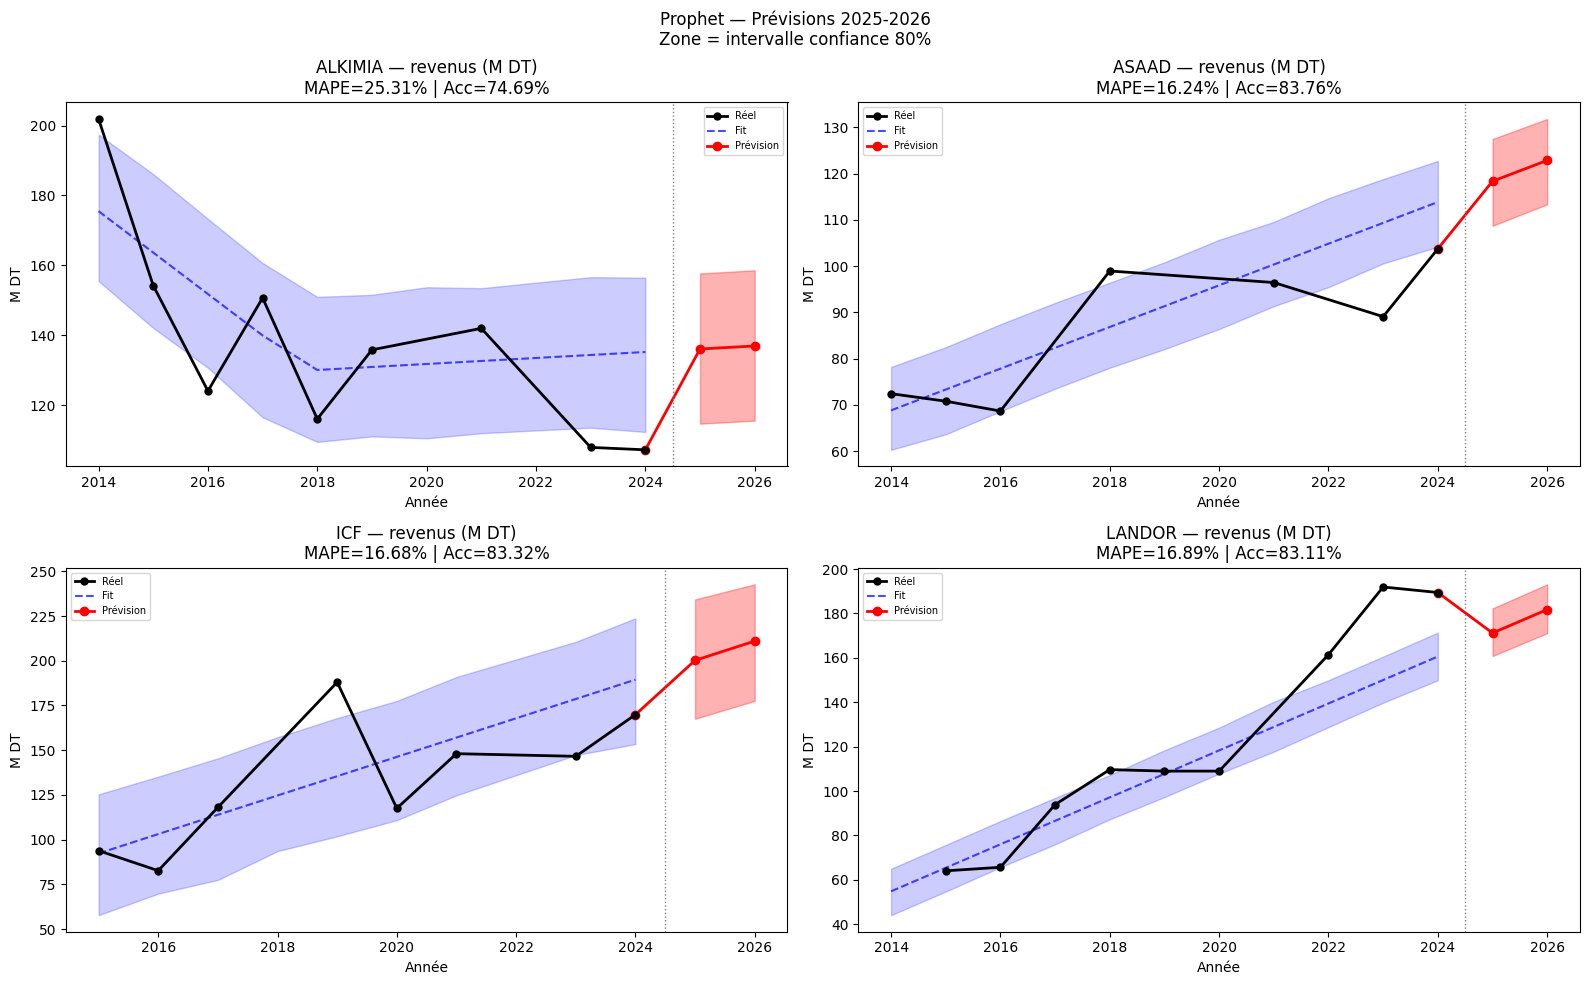

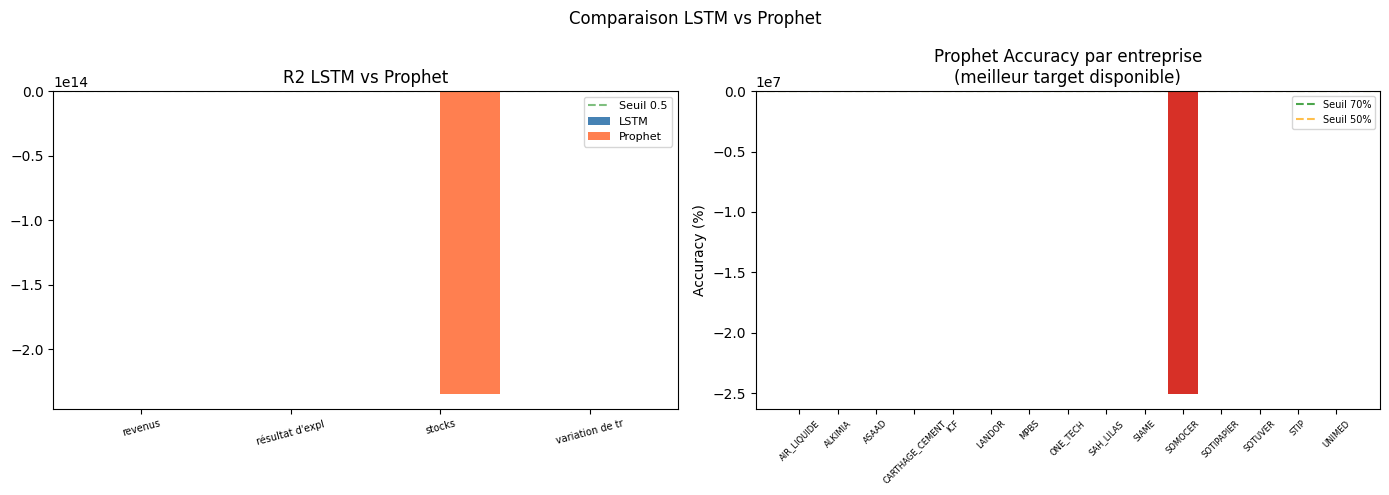


Sauvegardes OK

Prochaine étape : Cellule 26 — XAI Prophet


In [37]:
# ============================================================
# CELLULE 25 — Prophet FINALE avec MAPE + Accuracy
# ============================================================
!pip install prophet -q

import pandas as pd
import numpy as np
import json, warnings
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, \
    mean_squared_error
warnings.filterwarnings('ignore')

def convert_types(obj):
    if isinstance(obj, dict):
        return {k: convert_types(v)
                for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_types(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

def calc_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(
        np.abs(
            (y_true[mask] - y_pred[mask])
            / y_true[mask]
        ) * 100
    ))

# ── Source propre : bilans_clean.json ───────────────────────
OUTPUT_DIR = '/kaggle/working/extracted_json'
with open(f'{OUTPUT_DIR}/bilans_clean.json',
          encoding='utf-8') as f:
    data_clean = json.load(f)

TARGET_MAPPING = {
    'resultats_revenus'                 : ('resultats', 'revenus'),
    "resultats_résultat d'exploitation" : ('resultats', "résultat d'exploitation"),
    'actif_stocks'                      : ('actif',     'stocks'),
    'flux_variation de trésorerie'      : ('flux',      'variation de trésorerie'),
}
TARGET_COLS = list(TARGET_MAPPING.keys())

# ── Construire DataFrame sans fillna(0) ──────────────────────
rows = []
for company, years in data_clean.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]
        if periode != 'annuel':
            continue
        row = {'company': company, 'year': year}
        for col_name, (ttype, label) in \
            TARGET_MAPPING.items():
            val = None
            if ttype in tables:
                pairs = tables[ttype]
                if label in pairs:
                    val = pairs[label]
                else:
                    for k, v in pairs.items():
                        if label in k or k in label:
                            val = v
                            break
            row[col_name] = val
        rows.append(row)

df_src = pd.DataFrame(rows)\
           .sort_values(['company','year'])\
           .reset_index(drop=True)

print(f"Shape       : {df_src.shape}")
print(f"Entreprises : {df_src['company'].nunique()}")
print(f"Années      : "
      f"{sorted(df_src['year'].unique())}")

# ============================================================
# ENTRAÎNEMENT PROPHET
# ============================================================
print(f"\n{'='*55}")
print(f"ENTRAÎNEMENT PROPHET")
print(f"{'='*55}")

previsions_prophet = {}
metrics_prophet    = {}
models_prophet     = {}
errors_prophet     = []

for company in sorted(df_src['company'].unique()):
    df_co = df_src[
        df_src['company']==company
    ].sort_values('year').reset_index(drop=True)

    previsions_prophet[company] = {2025:{}, 2026:{}}
    metrics_prophet[company]    = {}
    models_prophet[company]     = {}

    for target in TARGET_COLS:
        # Données valides seulement
        df_prophet = pd.DataFrame({
            'ds': pd.to_datetime(
                df_co['year'].astype(str)+'-12-31'
            ),
            'y': df_co[target].values.astype(float)
        }).dropna(subset=['y'])

        if len(df_prophet) < 4:
            continue

        # Split train/test
        train_df = df_prophet[
            df_prophet['ds'].dt.year <= 2021
        ].copy()
        test_df  = df_prophet[
            df_prophet['ds'].dt.year >= 2022
        ].copy()

        if len(train_df) < 2:
            continue

        try:
            # Changepoints manuels pour Covid
            # sans add_changepoint (non supporté)
            cp_dates = []
            if any(train_df['ds'].dt.year == 2020):
                cp_dates.append(
                    pd.Timestamp('2020-12-31')
                )

            m = Prophet(
                growth             = 'linear',
                yearly_seasonality = False,
                weekly_seasonality = False,
                daily_seasonality  = False,
                interval_width     = 0.80,
                changepoint_prior_scale = 0.3,
                n_changepoints = min(
                    5, max(1, len(train_df)//2)
                ),
                changepoints = cp_dates
                               if cp_dates else None,
            )
            m.fit(train_df)
            models_prophet[company][target] = m

            # ── Évaluation test ───────────────────────
            if len(test_df) >= 1:
                fc_test = m.predict(test_df[['ds']])
                y_true  = test_df['y'].values
                y_pred  = fc_test['yhat'].values

                mae  = float(mean_absolute_error(
                    y_true, y_pred
                ))
                rmse = float(np.sqrt(
                    mean_squared_error(y_true, y_pred)
                ))
                ss_res = np.sum((y_true-y_pred)**2)
                ss_tot = np.sum(
                    (y_true-y_true.mean())**2
                )
                r2 = float(1-ss_res/ss_tot) \
                     if ss_tot > 0 else 0.0
                std_y = float(
                    df_prophet['y'].std()
                )
                mae_norm = mae/std_y \
                           if std_y > 0 else mae

                # MAPE + Accuracy
                mape_val = calc_mape(y_true, y_pred)
                accuracy = round(100-mape_val, 2) \
                           if not np.isnan(mape_val) \
                           else np.nan

                metrics_prophet[company][target] = {
                    'MAE'     : round(mae, 0),
                    'RMSE'    : round(rmse, 0),
                    'R2'      : round(r2, 4),
                    'MAE_norm': round(mae_norm, 4),
                    'MAPE'    : round(mape_val, 2)
                                if not np.isnan(mape_val)
                                else None,
                    'Accuracy': round(accuracy, 2)
                                if not np.isnan(accuracy)
                                else None,
                    'n_train' : len(train_df),
                    'n_test'  : len(test_df),
                }

            # ── Prévisions 2025-2026 ──────────────────
            future = pd.DataFrame({'ds':
                pd.to_datetime([
                    '2025-12-31', '2026-12-31'
                ])
            })
            fc = m.predict(future)
            for i, yr in enumerate([2025, 2026]):
                previsions_prophet[company][yr]\
                    [target] = {
                    'valeur': round(float(
                        fc.iloc[i]['yhat']
                    ), 0),
                    'lower' : round(float(
                        fc.iloc[i]['yhat_lower']
                    ), 0),
                    'upper' : round(float(
                        fc.iloc[i]['yhat_upper']
                    ), 0),
                }

        except Exception as e:
            errors_prophet.append(
                f"{company}/{target}: {str(e)[:60]}"
            )

    # Résumé entreprise
    print(f"\n  {company} :")
    for target in TARGET_COLS:
        if target not in metrics_prophet[company]:
            n_valid = df_co[target].notna().sum()
            print(f"    {target:<43} "
                  f"→ N/A (valid={n_valid})")
            continue
        m_co = metrics_prophet[company][target]
        r2   = m_co['R2']
        mape = m_co['MAPE']
        acc  = m_co['Accuracy']
        flag = '✓' if (acc and acc > 70) else \
               '~' if (acc and acc > 50) else '✗'
        print(f"    {target:<43} "
              f"R2={r2:>7.3f} "
              f"MAPE={mape:>6.1f}% "
              f"Acc={acc:>5.1f}% "
              f"{flag} "
              f"train={m_co['n_train']}")

print(f"\nErreurs : {len(errors_prophet)}")
for e in errors_prophet[:5]:
    print(f"  {e}")

# ============================================================
# MÉTRIQUES GLOBALES
# ============================================================
print(f"\n{'='*55}")
print(f"MÉTRIQUES GLOBALES PROPHET")
print(f"{'='*55}")

global_metrics = {}
for target in TARGET_COLS:
    r2_list   = []
    mae_list  = []
    mape_list = []
    acc_list  = []

    for company in metrics_prophet:
        if target in metrics_prophet[company]:
            m_co = metrics_prophet[company][target]
            r2_list.append(m_co['R2'])
            mae_list.append(m_co['MAE_norm'])
            if m_co['MAPE'] is not None:
                mape_list.append(m_co['MAPE'])
            if m_co['Accuracy'] is not None:
                acc_list.append(m_co['Accuracy'])

    if r2_list:
        global_metrics[target] = {
            'R2_moy'      : round(
                np.mean(r2_list), 4
            ),
            'R2_med'      : round(
                np.median(r2_list), 4
            ),
            'MAE_norm_moy': round(
                np.mean(mae_list), 4
            ),
            'MAPE_moy'    : round(
                np.mean(mape_list), 2
            ) if mape_list else None,
            'Accuracy_moy': round(
                np.mean(acc_list), 2
            ) if acc_list else None,
            'n_modeles'   : len(r2_list),
        }

print(f"\n{'Target':<45} {'R2_moy':>7} "
      f"{'MAPE':>8} {'Accuracy':>10} {'N':>3}")
print("─"*75)
for target, gm in global_metrics.items():
    mape_str = f"{gm['MAPE_moy']:.1f}%" \
               if gm['MAPE_moy'] else 'N/A'
    acc_str  = f"{gm['Accuracy_moy']:.1f}%" \
               if gm['Accuracy_moy'] else 'N/A'
    flag = '✓' if (gm['Accuracy_moy'] and
                   gm['Accuracy_moy'] > 70) else \
           '~' if (gm['Accuracy_moy'] and
                   gm['Accuracy_moy'] > 50) else '✗'
    print(f"  {target:<43} "
          f"{gm['R2_moy']:>7.3f} "
          f"{mape_str:>8} "
          f"{acc_str:>10} "
          f"{gm['n_modeles']:>3} {flag}")

# ============================================================
# PRÉVISIONS 2025-2026
# ============================================================
print(f"\n{'='*55}")
print(f"PRÉVISIONS PROPHET 2025-2026")
print(f"{'='*55}")

for company in sorted(previsions_prophet.keys()):
    has_prev = any(
        target in previsions_prophet[company][2025]
        for target in TARGET_COLS
    )
    if not has_prev:
        continue
    print(f"\n  {company} :")
    for yr in [2025, 2026]:
        print(f"    {yr} :")
        for target in TARGET_COLS:
            if target not in \
               previsions_prophet[company][yr]:
                continue
            p = previsions_prophet[company]\
                                   [yr][target]
            print(f"      {target:<43} : "
                  f"{p['valeur']:>15,.0f} DT "
                  f"[{p['lower']:,.0f} ; "
                  f"{p['upper']:,.0f}]")

# ============================================================
# VISUALISATION
# ============================================================
# Entreprises avec modèle revenus
companies_viz = [
    c for c in sorted(models_prophet.keys())
    if 'resultats_revenus' in models_prophet[c]
][:4]

# Si moins de 4 → prendre d'autres targets
if len(companies_viz) < 4:
    companies_extra = [
        c for c in sorted(models_prophet.keys())
        if c not in companies_viz
        and len(models_prophet[c]) > 0
    ][:4-len(companies_viz)]
    companies_viz += companies_extra

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax_idx, company in enumerate(companies_viz):
    ax = axes[ax_idx]
    if company not in models_prophet or \
       not models_prophet[company]:
        ax.axis('off')
        continue

    # Choisir le meilleur target disponible
    target = None
    for t in TARGET_COLS:
        if t in models_prophet[company]:
            target = t
            break
    if target is None:
        ax.axis('off')
        continue

    m     = models_prophet[company][target]
    df_co = df_src[
        df_src['company']==company
    ].sort_values('year')

    # Réel
    mask    = df_co[target].notna()
    yrs_ok  = df_co['year'].values[mask]
    vals_ok = df_co[target].values[mask]

    ax.plot(yrs_ok, vals_ok/1e6,
            'ko-', linewidth=2, markersize=5,
            label='Réel', zorder=5)

    # Fit
    hist_fc = m.predict(pd.DataFrame({'ds':
        pd.to_datetime(
            df_co['year'].astype(str)+'-12-31'
        )
    }))
    ax.plot(df_co['year'],
            hist_fc['yhat'].values/1e6,
            'b--', linewidth=1.5,
            label='Fit', alpha=0.7)
    ax.fill_between(
        df_co['year'],
        hist_fc['yhat_lower'].values/1e6,
        hist_fc['yhat_upper'].values/1e6,
        alpha=0.2, color='blue'
    )

    # Prévisions 2025-2026
    p25 = previsions_prophet[company][2025]\
          .get(target, {})
    p26 = previsions_prophet[company][2026]\
          .get(target, {})

    if p25 and p26:
        ax.plot(
            [int(yrs_ok[-1]), 2025, 2026],
            [float(vals_ok[-1])/1e6,
             p25['valeur']/1e6,
             p26['valeur']/1e6],
            'r-o', linewidth=2, markersize=6,
            label='Prévision'
        )
        ax.fill_between(
            [2025, 2026],
            [p25['lower']/1e6, p26['lower']/1e6],
            [p25['upper']/1e6, p26['upper']/1e6],
            alpha=0.3, color='red'
        )

    ax.axvline(2024.5, color='gray',
               linestyle=':', linewidth=1)

    # Métriques dans le titre
    m_info = metrics_prophet[company].get(target, {})
    acc    = m_info.get('Accuracy', '?')
    mape   = m_info.get('MAPE', '?')
    t_short = target.split('_')[-1][:15]
    ax.set_title(
        f"{company} — {t_short} (M DT)\n"
        f"MAPE={mape}% | Acc={acc}%"
    )
    ax.set_xlabel("Année")
    ax.set_ylabel("M DT")
    ax.legend(fontsize=7)

for ax in axes[len(companies_viz):]:
    ax.axis('off')

plt.suptitle(
    "Prophet — Prévisions 2025-2026\n"
    "Zone = intervalle confiance 80%",
    fontsize=12
)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/prophet_previsions.png',
    dpi=120, bbox_inches='tight'
)
plt.show()

# Comparaison LSTM vs Prophet
with open(
    '/kaggle/working/metrics_lstm.json'
) as f:
    metrics_lstm_loaded = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2 par target
ax = axes[0]
r2_l, r2_p, tgts_v = [], [], []
for c in TARGET_COLS:
    r2_lstm = metrics_lstm_loaded.get(c,{})\
                                  .get('R2', None)
    r2_prop = global_metrics.get(c,{})\
                             .get('R2_moy', None)
    if r2_lstm is not None and r2_prop is not None:
        r2_l.append(r2_lstm)
        r2_p.append(r2_prop)
        tgts_v.append(c.split('_')[-1][:15])

if tgts_v:
    x = np.arange(len(tgts_v))
    ax.bar(x-0.2, r2_l, 0.4,
           label='LSTM',    color='steelblue')
    ax.bar(x+0.2, r2_p, 0.4,
           label='Prophet', color='coral')
    ax.axhline(0,   color='black', linewidth=0.5)
    ax.axhline(0.5, color='green', linestyle='--',
               alpha=0.5, label='Seuil 0.5')
    ax.set_xticks(x)
    ax.set_xticklabels(tgts_v,
                       rotation=15, fontsize=7)
    ax.set_title("R2 LSTM vs Prophet")
    ax.legend(fontsize=8)

# Accuracy Prophet par entreprise
ax = axes[1]
cos     = sorted(df_src['company'].unique())
acc_co  = [
    metrics_prophet.get(c,{})\
    .get('resultats_revenus',{})\
    .get('Accuracy', np.nan)
    for c in cos
]
# Si revenus N/A → prendre autre target
acc_co_final = []
for i, c in enumerate(cos):
    acc = acc_co[i]
    if np.isnan(acc) if isinstance(acc, float) \
       else acc is None:
        # Chercher autre target
        for t in TARGET_COLS:
            a = metrics_prophet.get(c,{})\
                               .get(t,{})\
                               .get('Accuracy', None)
            if a is not None:
                acc = a
                break
    acc_co_final.append(
        acc if acc is not None else np.nan
    )

colors_a = [
    '#1a9850' if (not (isinstance(a, float)
                       and np.isnan(a))
                  and a is not None
                  and a > 70)
    else '#fee090' if (not (isinstance(a, float)
                            and np.isnan(a))
                       and a is not None
                       and a > 50)
    else '#d73027'
    for a in acc_co_final
]
ax.bar(range(len(cos)), acc_co_final,
       color=colors_a)
ax.axhline(70, color='green', linestyle='--',
           alpha=0.7, label='Seuil 70%')
ax.axhline(50, color='orange', linestyle='--',
           alpha=0.7, label='Seuil 50%')
ax.set_xticks(range(len(cos)))
ax.set_xticklabels(cos, rotation=45, fontsize=6)
ax.set_title("Prophet Accuracy par entreprise\n"
             "(meilleur target disponible)")
ax.set_ylabel("Accuracy (%)")
ax.legend(fontsize=7)

plt.suptitle("Comparaison LSTM vs Prophet",
             fontsize=12)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/lstm_vs_prophet.png',
    dpi=120, bbox_inches='tight'
)
plt.show()

# ── Sauvegardes ──────────────────────────────────────────────
with open(
    '/kaggle/working/previsions_prophet.json',
    'w', encoding='utf-8'
) as f:
    json.dump(
        convert_types(previsions_prophet),
        f, ensure_ascii=False, indent=2
    )

with open(
    '/kaggle/working/metrics_prophet.json',
    'w', encoding='utf-8'
) as f:
    json.dump(
        convert_types(metrics_prophet),
        f, ensure_ascii=False, indent=2
    )

with open(
    '/kaggle/working/global_metrics_prophet.json',
    'w', encoding='utf-8'
) as f:
    json.dump(
        convert_types(global_metrics),
        f, ensure_ascii=False, indent=2
    )

print(f"\nSauvegardes OK")
print(f"\nProchaine étape : Cellule 26 — XAI Prophet")

XAI PROPHET — DÉCOMPOSITION


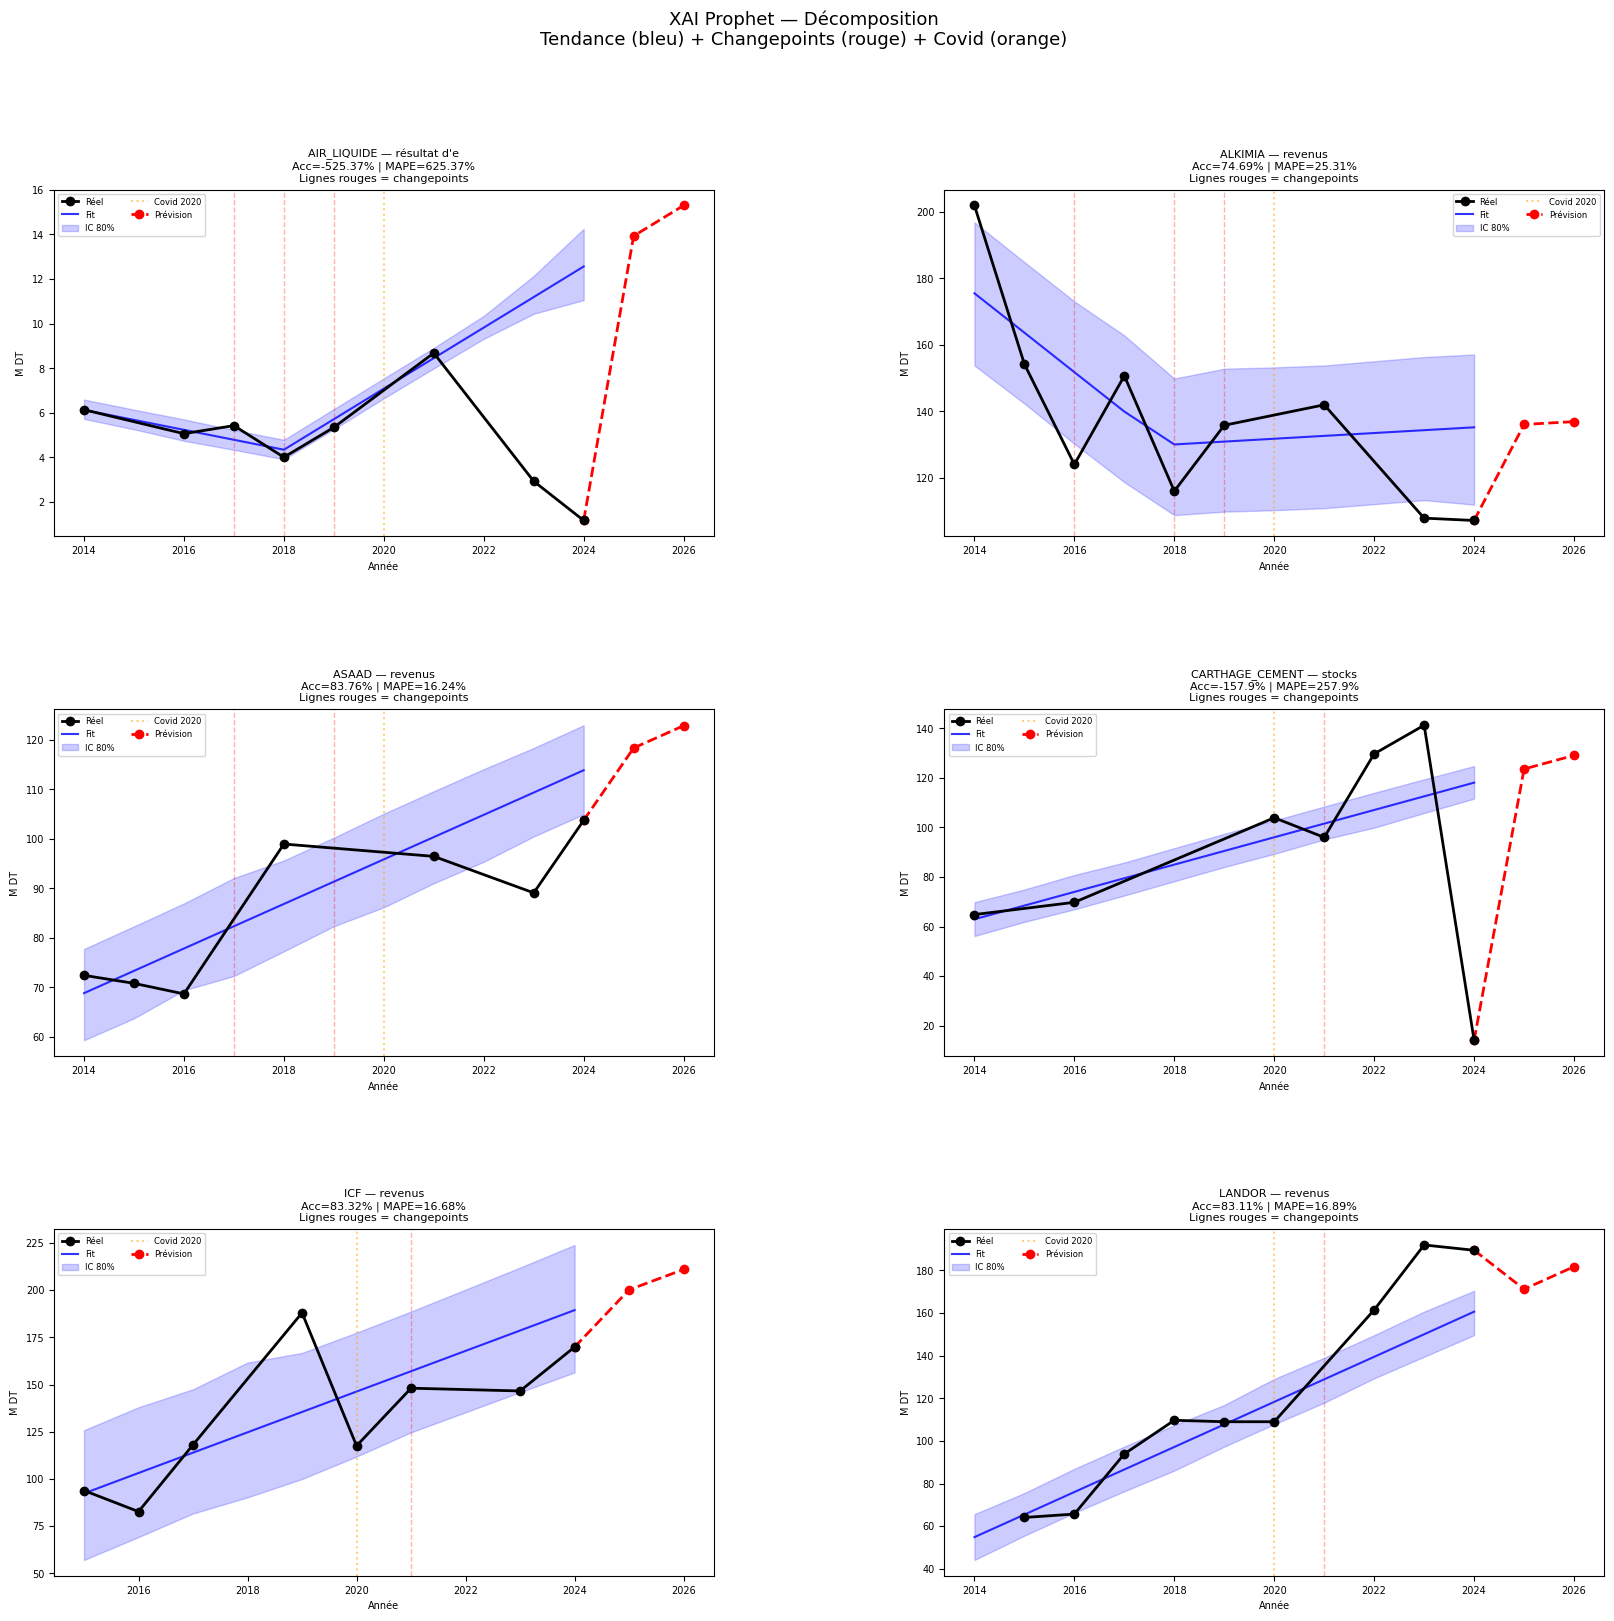

Sauvegarde : xai_prophet_decomp.png

XAI 2 — TAUX DE CROISSANCE PROPHET

Entreprise             TCAM 2020-24  Croiss. 2025
──────────────────────────────────────────────────
  AIR_LIQUIDE          [résultat]     15.39%       10.89%
  ALKIMIA              [revenus]      0.65%        0.63%
  ASAAD                [revenus]       4.4%        3.95%
  CARTHAGE_CEMENT      [stocks]       5.3%        4.66%
  ICF                  [revenus]      6.68%        5.69%
  LANDOR               [revenus]      7.94%        6.58%
  MPBS                 [revenus]       7.3%        6.14%
  SAH_LILAS            [revenus]      6.59%        5.63%
  SOMOCER              [revenus]     -8.38%      -10.48%
  SOTIPAPIER           [revenus]      2.69%        2.52%
  SOTUVER              [revenus]      7.94%        6.58%
  STIP                 [revenus]     -3.93%       -4.35%
  UNIMED               [revenus]      5.19%        4.58%

XAI 3 — CHANGEPOINTS DÉTECTÉS
  AIR_LIQUIDE            → [2016, 2017, 2018]
  ALKIMI

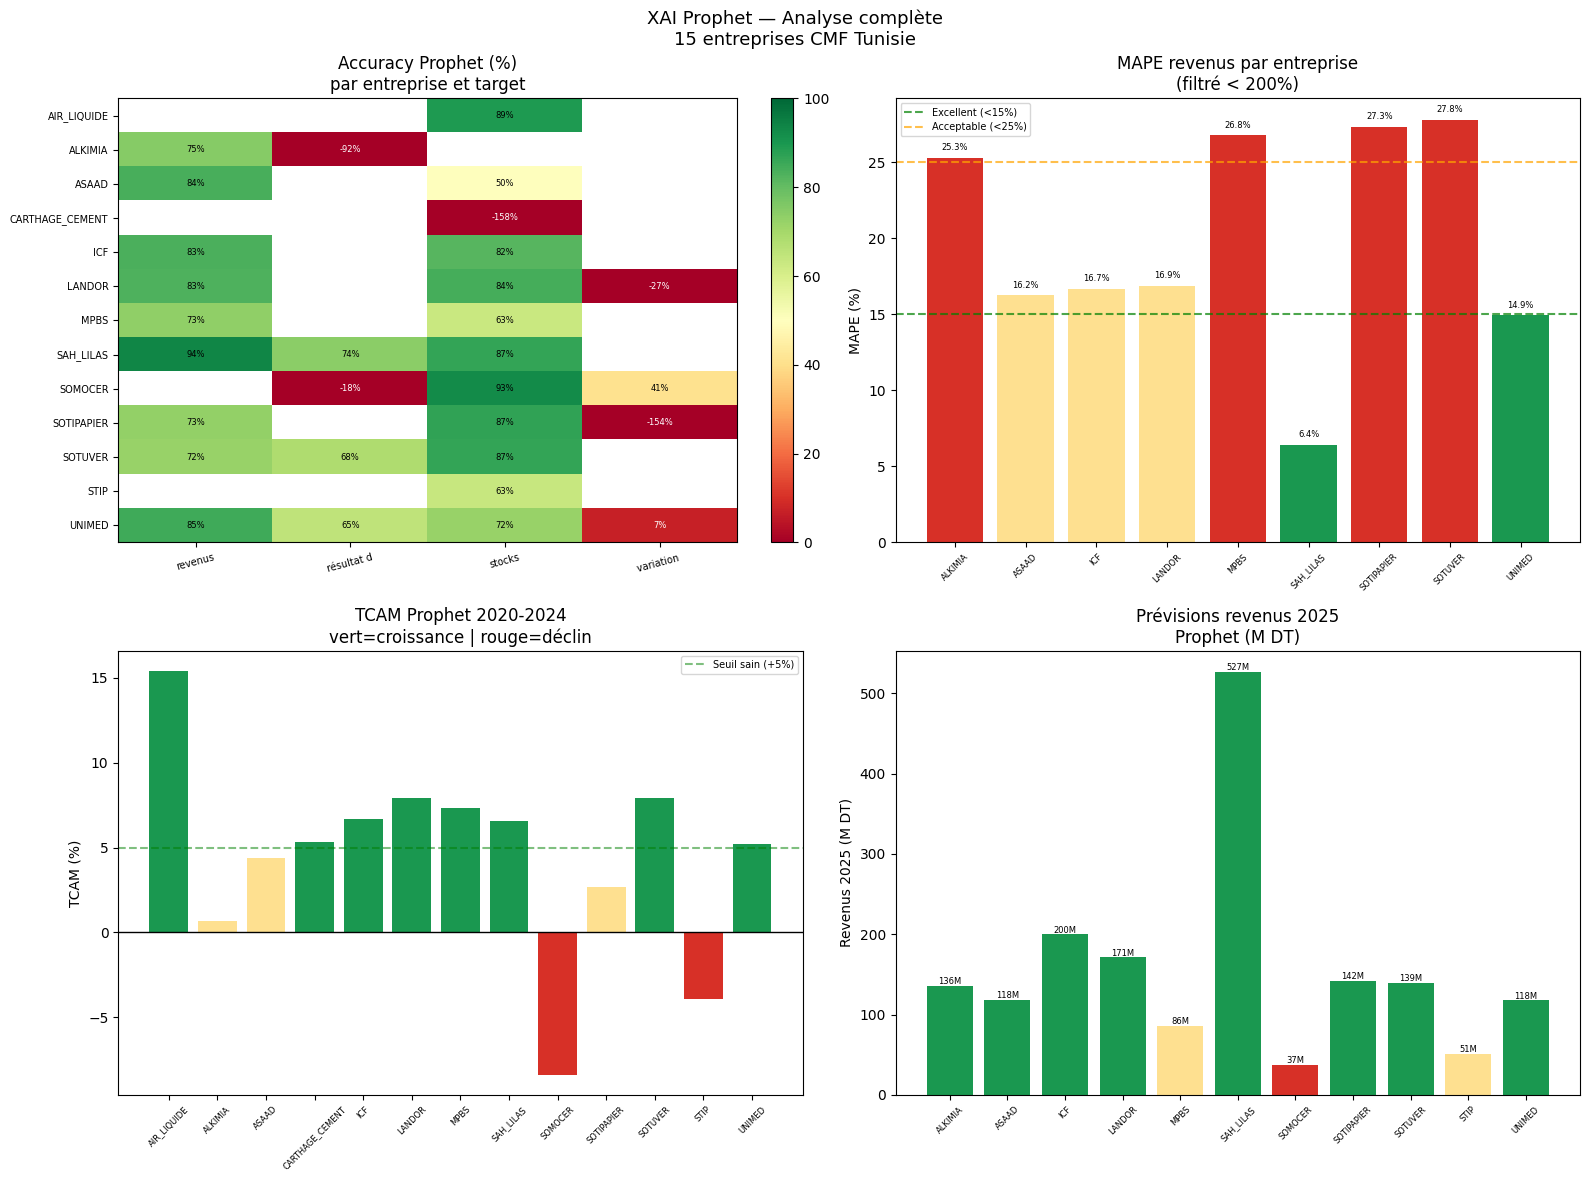

Sauvegarde : xai_prophet_complet.png

RÉSUMÉ XAI PROPHET

Top entreprises (Accuracy revenus) :
  SAH_LILAS              Acc=93.6%
  UNIMED                 Acc=85.1%
  ASAAD                  Acc=83.8%
  ICF                    Acc=83.3%
  LANDOR                 Acc=83.1%
  ALKIMIA                Acc=74.7%
  MPBS                   Acc=73.2%
  SOTIPAPIER             Acc=72.7%
  SOTUVER                Acc=72.2%

Tendances détectées (TCAM 2020-2024) :
  ~ ALKIMIA                TCAM=+0.7% → CROISSANCE
  ~ ASAAD                  TCAM=+4.4% → CROISSANCE
  ✓ ICF                    TCAM=+6.7% → CROISSANCE
  ✓ LANDOR                 TCAM=+7.9% → CROISSANCE
  ✓ MPBS                   TCAM=+7.3% → CROISSANCE
  ✓ SAH_LILAS              TCAM=+6.6% → CROISSANCE
  ✗ SOMOCER                TCAM=-8.4% → DECLIN
  ~ SOTIPAPIER             TCAM=+2.7% → CROISSANCE
  ✓ SOTUVER                TCAM=+7.9% → CROISSANCE
  ✗ STIP                   TCAM=-3.9% → DECLIN
  ✓ UNIMED                 TCAM=+5.2% → CROISSAN

In [39]:
# ============================================================
# CELLULE 26 — XAI Prophet (CORRIGÉE)
# ============================================================
import pandas as pd
import numpy as np
import json, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

OUTPUT_DIR = '/kaggle/working/extracted_json'

# ── Recharger données ────────────────────────────────────────
with open(f'{OUTPUT_DIR}/bilans_clean.json',
          encoding='utf-8') as f:
    data_clean = json.load(f)

with open('/kaggle/working/metrics_prophet.json') as f:
    metrics_prophet = json.load(f)

with open(
    '/kaggle/working/previsions_prophet.json'
) as f:
    previsions_prophet = json.load(f)

TARGET_MAPPING = {
    'resultats_revenus'                 : ('resultats', 'revenus'),
    "resultats_résultat d'exploitation" : ('resultats', "résultat d'exploitation"),
    'actif_stocks'                      : ('actif',     'stocks'),
    'flux_variation de trésorerie'      : ('flux',      'variation de trésorerie'),
}
TARGET_COLS = list(TARGET_MAPPING.keys())

# Reconstruire df_src
rows = []
for company, years in data_clean.items():
    for year_key, tables in years.items():
        year    = int(year_key.split('_')[0])
        periode = year_key.split('_')[1]
        if periode != 'annuel':
            continue
        row = {'company': company, 'year': year}
        for col_name, (ttype, label) in \
            TARGET_MAPPING.items():
            val = None
            if ttype in tables:
                pairs = tables[ttype]
                if label in pairs:
                    val = pairs[label]
                else:
                    for k, v in pairs.items():
                        if label in k or k in label:
                            val = v
                            break
            row[col_name] = val
        rows.append(row)

df_src = pd.DataFrame(rows)\
           .sort_values(['company','year'])\
           .reset_index(drop=True)

# ============================================================
# XAI 1 — Décomposition tendance + changepoints
# ============================================================
print("="*55)
print("XAI PROPHET — DÉCOMPOSITION")
print("="*55)

companies_xai = [
    c for c in sorted(models_prophet.keys())
    if len(models_prophet[c]) > 0
][:6]

fig = plt.figure(figsize=(20, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         hspace=0.5, wspace=0.35)

for idx, company in enumerate(companies_xai[:6]):
    ax = fig.add_subplot(gs[idx//2, idx%2])

    # Trouver target disponible
    tgt = 'resultats_revenus'
    if tgt not in models_prophet.get(company, {}):
        for t in TARGET_COLS:
            if t in models_prophet.get(company, {}):
                tgt = t
                break
        else:
            ax.axis('off')
            continue

    m     = models_prophet[company][tgt]
    df_co = df_src[
        df_src['company']==company
    ].sort_values('year')

    mask    = df_co[tgt].notna()
    yrs_ok  = df_co['year'].values[mask]
    vals_ok = df_co[tgt].values[mask]

    if len(yrs_ok) == 0:
        ax.axis('off')
        continue

    all_dates = pd.DataFrame({'ds':
        pd.to_datetime(
            df_co['year'].astype(str)+'-12-31'
        )
    })
    fc = m.predict(all_dates)

    ax.plot(yrs_ok, vals_ok/1e6,
            'ko-', linewidth=2, markersize=6,
            label='Réel', zorder=5)
    ax.plot(df_co['year'],
            fc['yhat'].values/1e6,
            'b-', linewidth=1.5,
            label='Fit', alpha=0.8)
    ax.fill_between(
        df_co['year'],
        fc['yhat_lower'].values/1e6,
        fc['yhat_upper'].values/1e6,
        alpha=0.2, color='blue',
        label='IC 80%'
    )

    # Changepoints
    for cp in m.changepoints:
        cp_yr = cp.year + cp.month/12
        ax.axvline(cp_yr, color='red',
                   alpha=0.3, linewidth=1,
                   linestyle='--')

    ax.axvline(2020, color='orange',
               alpha=0.5, linewidth=1.5,
               linestyle=':', label='Covid 2020')

    # ── Fix : clés string ────────────────────────
    p25 = previsions_prophet[company]\
          .get('2025', {}).get(tgt, {})
    p26 = previsions_prophet[company]\
          .get('2026', {}).get(tgt, {})

    if p25 and p26:
        ax.plot(
            [int(yrs_ok[-1]), 2025, 2026],
            [float(vals_ok[-1])/1e6,
             p25['valeur']/1e6,
             p26['valeur']/1e6],
            'r--o', linewidth=2, markersize=6,
            label='Prévision'
        )

    m_info = metrics_prophet.get(company,{})\
                             .get(tgt, {})
    acc  = m_info.get('Accuracy', 'N/A')
    mape = m_info.get('MAPE', 'N/A')
    t_s  = tgt.split('_')[-1][:12]
    ax.set_title(
        f"{company} — {t_s}\n"
        f"Acc={acc}% | MAPE={mape}%\n"
        f"Lignes rouges = changepoints",
        fontsize=8
    )
    ax.set_xlabel("Année", fontsize=7)
    ax.set_ylabel("M DT", fontsize=7)
    ax.legend(fontsize=6, ncol=2)
    ax.tick_params(labelsize=7)

plt.suptitle(
    "XAI Prophet — Décomposition\n"
    "Tendance (bleu) + Changepoints (rouge) "
    "+ Covid (orange)",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/xai_prophet_decomp.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Sauvegarde : xai_prophet_decomp.png")

# ============================================================
# XAI 2 — Taux de croissance TCAM
# ============================================================
print(f"\n{'='*55}")
print("XAI 2 — TAUX DE CROISSANCE PROPHET")
print(f"{'='*55}")

growth_data = {}
for company in sorted(models_prophet.keys()):
    growth_data[company] = {}
    for tgt in TARGET_COLS:
        if tgt not in models_prophet.get(
            company, {}
        ):
            continue
        m = models_prophet[company][tgt]

        fc_pts = m.predict(pd.DataFrame({'ds':
            pd.to_datetime([
                '2020-12-31',
                '2024-12-31',
                '2025-12-31',
            ])
        }))

        v2020 = float(fc_pts.iloc[0]['yhat'])
        v2024 = float(fc_pts.iloc[1]['yhat'])
        v2025 = float(fc_pts.iloc[2]['yhat'])

        if v2020 > 0 and v2024 > 0:
            tcam = (v2024/v2020)**(1/4) - 1
        else:
            tcam = np.nan

        if v2024 > 0:
            g_2025 = (v2025-v2024)/v2024*100
        else:
            g_2025 = np.nan

        growth_data[company][tgt] = {
            'TCAM_2020_2024': round(
                tcam*100, 2
            ) if not np.isnan(tcam) else None,
            'Croissance_2025': round(
                g_2025, 2
            ) if not np.isnan(g_2025) else None,
        }

print(f"\n{'Entreprise':<22} "
      f"{'TCAM 2020-24':>12} "
      f"{'Croiss. 2025':>13}")
print("─"*50)
for company in sorted(growth_data.keys()):
    tgt = 'resultats_revenus'
    if tgt not in growth_data[company]:
        for t in TARGET_COLS:
            if t in growth_data[company]:
                tgt = t
                break
        else:
            continue
    gd   = growth_data[company][tgt]
    tcam = gd['TCAM_2020_2024']
    g25  = gd['Croissance_2025']
    t_s  = tgt.split('_')[-1][:8]
    print(f"  {company:<20} "
          f"[{t_s}] "
          f"{str(tcam)+'%':>10} "
          f"{str(g25)+'%':>12}")

# ============================================================
# XAI 3 — Changepoints détectés
# ============================================================
print(f"\n{'='*55}")
print("XAI 3 — CHANGEPOINTS DÉTECTÉS")
print(f"{'='*55}")

for company in sorted(models_prophet.keys()):
    if not models_prophet[company]:
        continue
    tgt = next(iter(models_prophet[company]))
    m   = models_prophet[company][tgt]
    cp_years = sorted(set(
        cp.year for cp in m.changepoints
    ))
    print(f"  {company:<22} → {cp_years}")

# ============================================================
# XAI 4 — Visualisation complète
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Plot 1 : Matrice Accuracy ─────────────────────────────────
ax = axes[0, 0]
acc_by_target = {t: [] for t in TARGET_COLS}

for company in sorted(metrics_prophet.keys()):
    for tgt in TARGET_COLS:
        acc = metrics_prophet.get(company,{})\
                             .get(tgt,{})\
                             .get('Accuracy', None)
        if acc is not None and -200 < acc <= 100:
            acc_by_target[tgt].append(
                (company, acc)
            )

targets_valid = [
    t for t in TARGET_COLS
    if acc_by_target[t]
]
cos_valid = sorted(set(
    c for t in targets_valid
    for c, _ in acc_by_target[t]
))

if cos_valid and targets_valid:
    mat = np.full(
        (len(cos_valid), len(targets_valid)),
        np.nan
    )
    for j, tgt in enumerate(targets_valid):
        for company, acc in acc_by_target[tgt]:
            if company in cos_valid:
                i = cos_valid.index(company)
                mat[i, j] = acc

    im = ax.imshow(mat, cmap='RdYlGn',
                   vmin=0, vmax=100,
                   aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_xticks(range(len(targets_valid)))
    ax.set_xticklabels(
        [t.split('_')[-1][:10]
         for t in targets_valid],
        rotation=15, fontsize=7
    )
    ax.set_yticks(range(len(cos_valid)))
    ax.set_yticklabels(cos_valid, fontsize=7)
    ax.set_title("Accuracy Prophet (%)\n"
                 "par entreprise et target")
    for i in range(len(cos_valid)):
        for j in range(len(targets_valid)):
            if not np.isnan(mat[i,j]):
                ax.text(j, i,
                        f"{mat[i,j]:.0f}%",
                        ha='center', va='center',
                        fontsize=6,
                        color='black'
                        if mat[i,j] > 40
                        else 'white')

# ── Plot 2 : MAPE revenus ─────────────────────────────────────
ax = axes[0, 1]
mape_rev, cos_mape = [], []
for company in sorted(metrics_prophet.keys()):
    mape = metrics_prophet.get(company,{})\
                          .get('resultats_revenus',{})\
                          .get('MAPE', None)
    if mape is not None and 0 < mape < 200:
        mape_rev.append(mape)
        cos_mape.append(company)

if mape_rev:
    colors_m = [
        '#1a9850' if m < 15 else
        '#fee090' if m < 25 else
        '#d73027'
        for m in mape_rev
    ]
    bars = ax.bar(range(len(cos_mape)),
                  mape_rev, color=colors_m)
    ax.axhline(15, color='green',
               linestyle='--', alpha=0.7,
               label='Excellent (<15%)')
    ax.axhline(25, color='orange',
               linestyle='--', alpha=0.7,
               label='Acceptable (<25%)')
    ax.set_xticks(range(len(cos_mape)))
    ax.set_xticklabels(cos_mape,
                       rotation=45, fontsize=6)
    ax.set_title("MAPE revenus par entreprise\n"
                 "(filtré < 200%)")
    ax.set_ylabel("MAPE (%)")
    ax.legend(fontsize=7)
    for bar, val in zip(bars, mape_rev):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+0.5, f"{val:.1f}%",
            ha='center', fontsize=6
        )

# ── Plot 3 : TCAM ─────────────────────────────────────────────
ax = axes[1, 0]
tcam_vals, cos_tcam = [], []
for company in sorted(growth_data.keys()):
    tgt = 'resultats_revenus'
    if tgt not in growth_data[company]:
        for t in TARGET_COLS:
            if t in growth_data[company]:
                tgt = t
                break
        else:
            continue
    tcam = growth_data[company][tgt]\
                      .get('TCAM_2020_2024', None)
    if tcam is not None and abs(tcam) < 50:
        tcam_vals.append(tcam)
        cos_tcam.append(company)

if tcam_vals:
    colors_t = [
        '#1a9850' if v > 5 else
        '#fee090' if v > 0 else
        '#d73027'
        for v in tcam_vals
    ]
    ax.bar(range(len(cos_tcam)),
           tcam_vals, color=colors_t)
    ax.axhline(0, color='black', linewidth=1)
    ax.axhline(5, color='green',
               linestyle='--', alpha=0.5,
               label='Seuil sain (+5%)')
    ax.set_xticks(range(len(cos_tcam)))
    ax.set_xticklabels(cos_tcam,
                       rotation=45, fontsize=6)
    ax.set_title("TCAM Prophet 2020-2024\n"
                 "vert=croissance | rouge=déclin")
    ax.set_ylabel("TCAM (%)")
    ax.legend(fontsize=7)

# ── Plot 4 : Prévisions 2025 ──────────────────────────────────
ax = axes[1, 1]
prevs_2025, cos_prev = [], []
for company in sorted(
    previsions_prophet.keys()
):
    # ── Fix : clé string '2025' ──────────────────
    val = previsions_prophet[company]\
          .get('2025', {})\
          .get('resultats_revenus', {})\
          .get('valeur', None)
    if val and 0 < val < 1e9:
        prevs_2025.append(val/1e6)
        cos_prev.append(company)

if prevs_2025:
    colors_prev = [
        '#1a9850' if v > 100 else
        '#fee090' if v > 50  else
        '#d73027'
        for v in prevs_2025
    ]
    bars = ax.bar(range(len(cos_prev)),
                  prevs_2025,
                  color=colors_prev)
    ax.set_xticks(range(len(cos_prev)))
    ax.set_xticklabels(cos_prev,
                       rotation=45, fontsize=6)
    ax.set_title("Prévisions revenus 2025\n"
                 "Prophet (M DT)")
    ax.set_ylabel("Revenus 2025 (M DT)")
    for bar, val in zip(bars, prevs_2025):
        ax.text(
            bar.get_x()+bar.get_width()/2,
            val+2, f"{val:.0f}M",
            ha='center', fontsize=6
        )

plt.suptitle(
    "XAI Prophet — Analyse complète\n"
    "15 entreprises CMF Tunisie",
    fontsize=13
)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/xai_prophet_complet.png',
    dpi=120, bbox_inches='tight'
)
plt.show()
print("Sauvegarde : xai_prophet_complet.png")

# ── Résumé XAI ───────────────────────────────────────────────
print(f"\n{'='*55}")
print("RÉSUMÉ XAI PROPHET")
print(f"{'='*55}")

print("\nTop entreprises (Accuracy revenus) :")
acc_rev_list = []
for company in sorted(metrics_prophet.keys()):
    acc = metrics_prophet.get(company,{})\
                         .get('resultats_revenus',{})\
                         .get('Accuracy', None)
    if acc is not None and 0 < acc <= 100:
        acc_rev_list.append((company, acc))
acc_rev_list.sort(key=lambda x: x[1],
                  reverse=True)
for company, acc in acc_rev_list:
    print(f"  {company:<22} Acc={acc:.1f}%")

print(f"\nTendances détectées (TCAM 2020-2024) :")
for company in sorted(growth_data.keys()):
    tgt = 'resultats_revenus'
    if tgt not in growth_data[company]:
        continue
    tcam = growth_data[company][tgt]\
                      .get('TCAM_2020_2024', None)
    if tcam is None:
        continue
    trend = 'CROISSANCE' if tcam > 0 \
            else 'DECLIN'
    flag  = '✓' if tcam > 5 else \
            '~' if tcam > 0 else '✗'
    print(f"  {flag} {company:<22} "
          f"TCAM={tcam:+.1f}% → {trend}")

